# Article IIOT

## Ex?cution corrig?e

Les chemins Kaggle ont ?t? remplac?s par les chemins locaux du projet. Les biblioth?ques `statsmodels` et `xgboost` sont install?es.

Ex?cuter dans cet ordre : cellules de chargement, EDA, VIF, puis pr?paration des donn?es. Pour l'entra?nement, privil?gier `label2` (8 classes), retenue dans le rapport final. Les cellules de benchmark utilisant `label_full` (937 classes) sont exp?rimentales et tr?s co?teuses ; ne pas les lancer toutes en m?me temps.



In [9]:
import os
import glob
import pandas as pd
from pathlib import Path
from google.colab import drive

# 0. Montage du Google Drive
drive.mount('/content/drive')

# 1. Définition des dossiers du projet
PROJET_DIR = Path("/content/drive/MyDrive/projet-remote")
DONNEES_DIR = PROJET_DIR / "Datasense-IIoT-2025" / "data" / "all_attack_benign_samples"

dossier_donnees_attack = DONNEES_DIR / "attack_data"
dossier_donnees_benign = DONNEES_DIR / "benign_data"

print("Vérification des chemins :")
print("  • Dossier Attaques existe :", dossier_donnees_attack.exists())
print("  • Dossier Bénins existe   :", dossier_donnees_benign.exists())

# 2. Récupération et tri des fichiers CSV
fichiers_attaques = sorted(glob.glob(str(dossier_donnees_attack / "attack*.csv")))
fichiers_benins = sorted(glob.glob(str(dossier_donnees_benign / "benign*.csv")))

print(f"\n✅ Fichiers trouvés : {len(fichiers_attaques)} d'attaque et {len(fichiers_benins)} bénins.")

Mounted at /content/drive
Vérification des chemins :
  • Dossier Attaques existe : True
  • Dossier Bénins existe   : True

✅ Fichiers trouvés : 7 d'attaque et 10 bénins.


In [10]:
# Initialisation portable : Windows et Google Colab.
from pathlib import Path

try:
    from google.colab import drive
    ENVIRONNEMENT = "colab"
except ImportError:
    ENVIRONNEMENT = "windows"

if ENVIRONNEMENT == "colab":
    # Utilisation de force_remount pour éviter l'erreur de propagation des identifiants
    try:
        drive.mount("/content/drive", force_remount=True)
    except Exception as e:
        print("⚠️ Erreur lors du montage du Drive :", e)
        print("💡 Astuce : Montez le Drive manuellement via l'icône de dossier à gauche.")

    PROJET_DIR = Path("/content/drive/MyDrive/projet-remote")
else:
    PROJET_DIR = Path.cwd().resolve()

DONNEES_DIR = PROJET_DIR / "Datasense-IIoT-2025"
CSV_DIR = DONNEES_DIR / "data" / "all_attack_benign_samples"
dossier_donnees_attack = CSV_DIR / "attack_data"
dossier_donnees_benign = CSV_DIR / "benign_data"
ARTIFACTS_DIR = PROJET_DIR / "artifacts" / "bilstm"

# Nouveau dossier pour sauvegarder vos résultats finaux
RESULTATS_DIR = PROJET_DIR / "resulta_final"
RESULTATS_DIR.mkdir(parents=True, exist_ok=True)

print("\nEnvironnement :", ENVIRONNEMENT)
print("Projet :", PROJET_DIR)
print("Données :", CSV_DIR)
print("Artifacts :", ARTIFACTS_DIR)
print("Résultats finaux :", RESULTATS_DIR)

Mounted at /content/drive

Environnement : colab
Projet : /content/drive/MyDrive/projet-remote
Données : /content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples
Artifacts : /content/drive/MyDrive/projet-remote/artifacts/bilstm
Résultats finaux : /content/drive/MyDrive/projet-remote/resulta_final


In [ ]:
print("Dossier résultats trouvé :", RESULTATS_DIR.exists())
print("Éléments sauvegardés :")
for element in RESULTATS_DIR.iterdir():
    print("-", element.name)

Dossier résultats trouvé : True
Éléments sauvegardés :


In [ ]:
# Vérifier le contenu du dossier du projet
for element in PROJET_DIR.iterdir():
    print(element.name)

memoire_finale_iot.ipynb
README.md
.gitignore
Datasense-IIoT-2025
.ipynb_checkpoints
.git
.vs
artifacts
memoire_iot.ipynb
resulta_final


In [ ]:
# Parcourt récursivement tous les sous-dossiers et fichiers situés dans DONNEES_DIR
for element in DONNEES_DIR.rglob('*'):
    # Vérifie si l'élément courant est un dossier (et non un fichier)
    if element.is_dir():
        # Affiche le chemin d'accès complet de chaque dossier trouvé
        print(element)

/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/docs
/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data
/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples
/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/benign_data
/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/attack_data
/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/benign_data/checksums
/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/attack_data/checksums


In [ ]:
# Chemins vers les dossiers de données
dossier_donnees_attack = (
    DONNEES_DIR / "data" / "all_attack_benign_samples" / "attack_data"
)
dossier_donnees_benign = (
    DONNEES_DIR / "data" / "all_attack_benign_samples" / "benign_data"
)

# Vérification de la présence des dossiers
print("Attaques :", dossier_donnees_attack.exists())
print("Bénins :", dossier_donnees_benign.exists())

Attaques : True
Bénins : True


In [ ]:
# ============================================
# 1. DéFINITION DES DOSSIERS CSV  chemins locaux portables
# ============================================
from pathlib import Path
import os, glob, pandas as pd

base_path = PROJET_DIR / 'Datasense-IIoT-2025'
dossier_donnees_attack = base_path / 'data' / 'all_attack_benign_samples' / 'attack_data'
dossier_donnees_benign = base_path / 'data' / 'all_attack_benign_samples' / 'benign_data'

if not dossier_donnees_attack.is_dir() or not dossier_donnees_benign.is_dir():
    raise FileNotFoundError(f'Données IIoT introuvables sous : {base_path.resolve()}')

print(f'Attaques : {dossier_donnees_attack.resolve()}')
print(f'benigns : {dossier_donnees_benign.resolve()}')

Attaques : /content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/attack_data
benigns : /content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/benign_data


## Etape 1: Data preprocessing

## Charger les librairies

In [11]:
# Charger les librairies
import os
import glob
import pandas as pd
import numpy as np
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

In [12]:
import tensorflow as tf

# Vérification de la disponibilité du GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU activé et détecté : {gpus[0].name}")
else:
    print("Aucun GPU détecté.")

GPU activé et détecté : /physical_device:GPU:0


## Charger la base de donnée

In [13]:
# ============================================
# 2. RÉCUPÉRATION DES FICHIERS CSV
# ============================================

# Récupérer les fichiers attack
fichiers_attaques = sorted(glob.glob(str(dossier_donnees_attack / 'attack*.csv')))
fichiers_benins = sorted(glob.glob(str(dossier_donnees_benign / 'benign*.csv')))

print(f"✅ Fichiers attaques trouvés : {len(fichiers_attaques)}")
print(f"✅ Fichiers benins trouvés : {len(fichiers_benins)}")

# Afficher les premiers fichiers
if fichiers_attaques:
    print("\n📋 Fichiers attaques :")
    for f in fichiers_attaques[:10]:
        print(f"  - {os.path.basename(f)}")
if fichiers_benins:
    print("\n📋 Fichiers benins :")
    for f in fichiers_benins[:10]:
        print(f"  - {os.path.basename(f)}")

✅ Fichiers attaques trouvés : 7
✅ Fichiers benins trouvés : 10

📋 Fichiers attaques :
  - attack_samples_10sec.csv
  - attack_samples_3sec.csv
  - attack_samples_4sec.csv
  - attack_samples_5sec.csv
  - attack_samples_6sec.csv
  - attack_samples_7sec.csv
  - attack_samples_9sec.csv

📋 Fichiers benins :
  - benign_samples_10sec.csv
  - benign_samples_1sec.csv
  - benign_samples_2sec.csv
  - benign_samples_3sec.csv
  - benign_samples_4sec.csv
  - benign_samples_5sec.csv
  - benign_samples_6sec.csv
  - benign_samples_7sec.csv
  - benign_samples_8sec.csv
  - benign_samples_9sec.csv


In [ ]:
# Vérification du chemin d'accès au dossier des attaques
print(dossier_donnees_attack)

/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/attack_data


In [ ]:
# Le chemin local est défini dans la cellule 2.
print(dossier_donnees_benign)


/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/benign_data


In [ ]:
# Lister tous les chemins complets des fichiers CSV d'attaque trouvés
fichiers_attaques = sorted(glob.glob(str(dossier_donnees_attack / 'attack*.csv')))
fichiers_attaques

['/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/attack_data/attack_samples_10sec.csv',
 '/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/attack_data/attack_samples_1sec.csv',
 '/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/attack_data/attack_samples_2sec.csv',
 '/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/attack_data/attack_samples_3sec.csv',
 '/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/attack_data/attack_samples_4sec.csv',
 '/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/attack_data/attack_samples_5sec.csv',
 '/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/attack_data/attack_samples_6sec.csv',
 '/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/attack_data/a

In [ ]:
# Si les fichiers ont une autre nomenclature, on prend tous les CSV du dossier
#tous_fichiers = sorted(glob.glob(os.path.join(dossier_donnees, "*.csv")))

In [ ]:
# Lister tous les chemins complets des fichiers CSV bénins trouvés
fichiers_benins = sorted(glob.glob(str(dossier_donnees_benign / 'benign*.csv')))
fichiers_benins

['/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/benign_data/benign_samples_10sec.csv',
 '/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/benign_data/benign_samples_1sec.csv',
 '/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/benign_data/benign_samples_2sec.csv',
 '/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/benign_data/benign_samples_3sec.csv',
 '/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/benign_data/benign_samples_4sec.csv',
 '/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/benign_data/benign_samples_5sec.csv',
 '/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/benign_data/benign_samples_6sec.csv',
 '/content/drive/MyDrive/projet-remote/Datasense-IIoT-2025/data/all_attack_benign_samples/benign_data/b

In [ ]:
if len(fichiers_attaques) > 0 and len(fichiers_benins) > 0:
    liste_fichiers = fichiers_attaques + fichiers_benins
else:
    liste_fichiers = tous_fichiers

print(f"[INFO] {len(liste_fichiers)} fichiers CSV détectés au total.\n")

[INFO] 20 fichiers CSV détectés au total.



In [14]:
# ============================================
# 3. CHARGEMENT ET FUSION DES FICHIERS CSV
# ============================================

df_list = []
print("\n=== CHARGEMENT DES FICHIERS ===")

# Charger les fichiers attaques
for f in fichiers_attaques:
    df_temp = pd.read_csv(f)
    df_list.append(df_temp)
    print(f"  ✅ {os.path.basename(f)} : {df_temp.shape[0]:,} lignes, {df_temp.shape[1]} colonnes")

# Charger les fichiers benins
for f in fichiers_benins:
    df_temp = pd.read_csv(f)
    df_list.append(df_temp)
    print(f"  ✅ {os.path.basename(f)} : {df_temp.shape[0]:,} lignes, {df_temp.shape[1]} colonnes")

# Fusionner tous les DataFrames
if df_list:
    df_complet = pd.concat(df_list, ignore_index=True)
    print(f"\n{'='*50}")
    print(f"✅ DATASET COMPLET")
    print(f"{'='*50}")
    print(f"  • Lignes : {df_complet.shape[0]:,}")
    print(f"  • Colonnes : {df_complet.shape[1]}")
    print(f"\n📋 Colonnes : {df_complet.columns.tolist()[:10]}...")
    print(f"\n📊 Distribution de 'label2' :")
    print(df_complet['label2'].value_counts())
else:
    print("❌ Aucun fichier CSV chargé !")


=== CHARGEMENT DES FICHIERS ===
  ✅ attack_samples_10sec.csv : 16,350 lignes, 94 colonnes
  ✅ attack_samples_3sec.csv : 29,627 lignes, 94 colonnes
  ✅ attack_samples_4sec.csv : 22,165 lignes, 94 colonnes
  ✅ attack_samples_5sec.csv : 17,695 lignes, 94 colonnes
  ✅ attack_samples_6sec.csv : 14,723 lignes, 94 colonnes
  ✅ attack_samples_7sec.csv : 12,050 lignes, 94 colonnes
  ✅ attack_samples_9sec.csv : 16,434 lignes, 94 colonnes
  ✅ benign_samples_10sec.csv : 13,680 lignes, 94 colonnes
  ✅ benign_samples_1sec.csv : 136,800 lignes, 94 colonnes
  ✅ benign_samples_2sec.csv : 68,400 lignes, 94 colonnes
  ✅ benign_samples_3sec.csv : 45,600 lignes, 94 colonnes
  ✅ benign_samples_4sec.csv : 34,200 lignes, 94 colonnes
  ✅ benign_samples_5sec.csv : 27,360 lignes, 94 colonnes
  ✅ benign_samples_6sec.csv : 22,800 lignes, 94 colonnes
  ✅ benign_samples_7sec.csv : 19,532 lignes, 94 colonnes
  ✅ benign_samples_8sec.csv : 17,100 lignes, 94 colonnes
  ✅ benign_samples_9sec.csv : 15,200 lignes, 94 colo

In [ ]:
# 3. Chargement itératif des fichiers avec affichage de la progression
liste_dataframes = []

for idx, chemin_fichier in enumerate(liste_fichiers, 1):
    nom_fichier = os.path.basename(chemin_fichier)
    df_temp = pd.read_csv(chemin_fichier)

    # Affichage du nombre de lignes de chaque fichier
    print(f" [{idx:02d}/{len(liste_fichiers):02d}] Chargement de '{nom_fichier}' -> {df_temp.shape[0]:,} lignes, {df_temp.shape[1]} colonnes.")
    liste_dataframes.append(df_temp)

 [01/20] Chargement de 'attack_samples_10sec.csv' -> 16,350 lignes, 94 colonnes.
 [02/20] Chargement de 'attack_samples_1sec.csv' -> 90,391 lignes, 94 colonnes.
 [03/20] Chargement de 'attack_samples_2sec.csv' -> 44,744 lignes, 94 colonnes.
 [04/20] Chargement de 'attack_samples_3sec.csv' -> 29,627 lignes, 94 colonnes.
 [05/20] Chargement de 'attack_samples_4sec.csv' -> 22,165 lignes, 94 colonnes.
 [06/20] Chargement de 'attack_samples_5sec.csv' -> 17,695 lignes, 94 colonnes.
 [07/20] Chargement de 'attack_samples_6sec.csv' -> 14,723 lignes, 94 colonnes.
 [08/20] Chargement de 'attack_samples_7sec.csv' -> 12,050 lignes, 94 colonnes.
 [09/20] Chargement de 'attack_samples_8sec.csv' -> 20,820 lignes, 94 colonnes.
 [10/20] Chargement de 'attack_samples_9sec.csv' -> 16,434 lignes, 94 colonnes.
 [11/20] Chargement de 'benign_samples_10sec.csv' -> 13,680 lignes, 94 colonnes.
 [12/20] Chargement de 'benign_samples_1sec.csv' -> 136,800 lignes, 94 colonnes.
 [13/20] Chargement de 'benign_sample

In [15]:
# ============================================
# 4. PRÉPARATION DES DONNÉES POUR LE MODÈLE (TOUT LE DATASET)
# ============================================
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler, OrdinalEncoder
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 1. Identifier les colonnes de features
colonnes_labels = ['label_full', 'label3', 'label2', 'label1', 'label']
cols_features = [c for c in df_complet.columns if c not in colonnes_labels]
print(f"✅ {len(cols_features)} variables identifiées")

# 2. Préparation des données
X_raw = df_complet[cols_features].copy()

# Encodage des variables textuelles
cols_text = X_raw.select_dtypes(include=['object', 'category', 'string']).columns
if len(cols_text) > 0:
    print(f"Encodage de {len(cols_text)} variables textuelles...")
    encoder_ord = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_raw[cols_text] = encoder_ord.fit_transform(X_raw[cols_text])

# Scaling
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=cols_features)

# Encodage de la cible (label2)
encoder_y = LabelEncoder()
y_complet = pd.Series(encoder_y.fit_transform(df_complet['label2']))

print(f"✅ X_scaled : {X_scaled.shape}")
print(f"✅ y_complet : {y_complet.shape}")
print(f"✅ {len(np.unique(y_complet))} classes")

# ============================================
# UTILISATION DE TOUT LE DATASET (686 226 lignes)
# ============================================
print("\n" + "="*50)
print("UTILISATION DE TOUT LE DATASET")
print("="*50)

# Pas de train_test_split, on utilise tout !
X_train_39 = X_scaled
y_train = y_complet

print(f"✅ X_train_39 : {X_train_39.shape[0]:,} lignes, {X_train_39.shape[1]} colonnes")
print(f"✅ y_train : {y_train.shape[0]:,} lignes")

# 5. Stratified K-Fold pour la validation croisée
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"✅ skf : {skf.n_splits} folds")

# Afficher la distribution des classes
print("\n📊 Distribution des classes (label2) :")
print(df_complet['label2'].value_counts())
print("\n📊 Proportions :")
print((df_complet['label2'].value_counts(normalize=True) * 100).round(2))

✅ 90 variables identifiées
Encodage de 19 variables textuelles...
✅ X_scaled : (529716, 90)
✅ y_complet : (529716,)
✅ 8 classes

UTILISATION DE TOUT LE DATASET
✅ X_train_39 : 529,716 lignes, 90 colonnes
✅ y_train : 529,716 lignes
✅ skf : 5 folds

📊 Distribution des classes (label2) :
label2
benign        400672
recon          47881
dos            26048
ddos           25578
mitm           11569
malware        11053
web             4154
bruteforce      2761
Name: count, dtype: int64

📊 Proportions :
label2
benign        75.64
recon          9.04
dos            4.92
ddos           4.83
mitm           2.18
malware        2.09
web            0.78
bruteforce     0.52
Name: proportion, dtype: float64


## Concaténation en un dataframe unique

In [ ]:
# 4. Concaténation en un dataframe unique (df_complet)
print("\n[INFO] Fusion des fichiers en cours...")
df_complet = pd.concat(liste_dataframes, ignore_index=True)
df_complet


[INFO] Fusion des fichiers en cours...


,device_name,device_mac,label_full,label1,label2,label3,label4,timestamp,timestamp_start,timestamp_end,...,network_time-delta_min,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation
0,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:10.709000Z_2025-01-23T15:31:2...,2025-01-23T15:31:10.709000Z,2025-01-23T15:31:20.709000Z,...,2.600000e-08,0.000042,64.00,64.0,64.0,0.000000,17587.532313,64240.0,0.0,28377.701703
1,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:15.709000Z_2025-01-23T15:31:2...,2025-01-23T15:31:15.709000Z,2025-01-23T15:31:25.709000Z,...,2.500000e-08,0.000041,64.00,64.0,64.0,0.000000,17259.307890,64240.0,0.0,28201.477525
2,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:20.709000Z_2025-01-23T15:31:3...,2025-01-23T15:31:20.709000Z,2025-01-23T15:31:30.709000Z,...,2.500000e-08,0.000041,64.00,64.0,64.0,0.000000,17185.878307,64240.0,0.0,28161.438527
3,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:25.709000Z_2025-01-23T15:31:3...,2025-01-23T15:31:25.709000Z,2025-01-23T15:31:35.709000Z,...,2.500000e-08,0.000041,64.00,64.0,64.0,0.000000,16750.718465,64240.0,0.0,27918.422488
4,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:30.709000Z_2025-01-23T15:31:4...,2025-01-23T15:31:30.709000Z,2025-01-23T15:31:40.709000Z,...,2.600000e-08,0.000041,64.00,64.0,64.0,0.000000,16673.446073,64240.0,0.0,27874.486393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685666,plug-all-sensors,d4:a6:51:82:98:a8,benign_whole-network3,benign,benign,benign,benign,2025-09-09T15:08:55.400000Z_2025-09-09T15:09:0...,2025-09-09T15:08:55.400000Z,2025-09-09T15:09:04.400000Z,...,2.296000e-03,0.014523,255.00,255.0,255.0,0.000000,0.000000,0.0,0.0,0.000000
685667,plug-all-sensors,d4:a6:51:82:98:a8,benign_whole-network3,benign,benign,benign,benign,2025-09-09T15:09:04.400000Z_2025-09-09T15:09:1...,2025-09-09T15:09:04.400000Z,2025-09-09T15:09:13.400000Z,...,1.042600e-02,0.008164,255.00,255.0,255.0,0.000000,0.000000,0.0,0.0,0.000000
685668,plug-all-sensors,d4:a6:51:82:98:a8,benign_whole-network3,benign,benign,benign,benign,2025-09-09T15:09:13.400000Z_2025-09-09T15:09:2...,2025-09-09T15:09:13.400000Z,2025-09-09T15:09:22.400000Z,...,4.307000e-03,0.026717,255.00,255.0,255.0,0.000000,0.000000,0.0,0.0,0.000000
685669,plug-all-sensors,d4:a6:51:82:98:a8,benign_whole-network3,benign,benign,benign,benign,2025-09-09T15:09:22.400000Z_2025-09-09T15:09:3...,2025-09-09T15:09:22.400000Z,2025-09-09T15:09:31.400000Z,...,8.460000e-04,0.013263,255.00,255.0,255.0,0.000000,0.000000,0.0,0.0,0.000000


### STATISTIQUE DE BASE  (EDA)

In [ ]:
# 1. Affichage du bilan de la matrice globale
print(" BILAN DE LA MATRICE FUSIONNÉE (df_complet)")
print(f" -> Nombre total de lignes (échantillons) : {df_complet.shape[0]:,}")
print(f" -> Nombre total de colonnes (variables)  : {df_complet.shape[1]}")

 BILAN DE LA MATRICE FUSIONNÉE (df_complet)
 -> Nombre total de lignes (échantillons) : 685,671
 -> Nombre total de colonnes (variables)  : 94


In [ ]:
# ============================================
# 1. BILAN DE LA MATRICE FUSIONNÉE
# ============================================
print("="*60)
print("BILAN DE LA MATRICE FUSIONNÉE (df_complet)")
print("="*60)
print(f"  • Nombre total de lignes (échantillons) : {df_complet.shape[0]:,}")
print(f"  • Nombre total de colonnes (variables) : {df_complet.shape[1]}")
print(f"  • Taille en mémoire : {df_complet.memory_usage(deep=True).sum() / 1e6:.1f} MB")

BILAN DE LA MATRICE FUSIONNÉE (df_complet)
  • Nombre total de lignes (échantillons) : 685,671
  • Nombre total de colonnes (variables) : 94
  • Taille en mémoire : 4183.1 MB


In [ ]:
# ============================================
# 2. VÉRIFICATION DE LA PRÉSENCE DE LA CIBLE label_full ou label_all
# ============================================
colonne_cible = None
for col in ['label_full', 'label_all', 'label2', 'label1', 'label']:
    if col in df_complet.columns:
        colonne_cible = col
        break

if colonne_cible:
    print(f"✅ Colonne cible trouvée : '{colonne_cible}'")
    print(f"\nDistribution des classes :")
    print(df_complet[colonne_cible].value_counts())
    print(f"\nProportions :")
    print((df_complet[colonne_cible].value_counts(normalize=True) * 100).round(2))
else:
    print("❌ Aucune colonne cible trouvée !")
    print(f"Colonnes disponibles : {df_complet.columns.tolist()[:20]}...")

✅ Colonne cible trouvée : 'label_full'

Distribution des classes :
label_full
benign_whole-network3                                400672
attack_recon_os-scan_whole-network                     7115
attack_recon_host-disc-tcp-ack-ping_whole-network      7056
attack_recon_vuln-scan_whole-network                   7041
attack_recon_host-disc-tcp-syn-ping_whole-network      6991
                                                      ...  
attack_dos_syn-flood-port-554_blurams-camera             94
attack_dos_syn-flood-port-443_ap                         94
attack_dos_syn-flood-port-443_mqtt-broker                94
attack_dos_syn-flood-port-443_edge1                      94
attack_dos_tcp-flood-port-443_mqtt-broker                94
Name: count, Length: 937, dtype: int64

Proportions :
label_full
benign_whole-network3                                58.44
attack_recon_os-scan_whole-network                    1.04
attack_recon_host-disc-tcp-ack-ping_whole-network     1.03
attack_recon_vuln-sc

In [ ]:
# Vérification des valeurs manquantes par colonne dans df_complet
df_complet.isnull().sum()

,0
device_name,0
device_mac,0
label_full,0
label1,0
label2,0
...,...
network_ttl_std_deviation,0
network_window-size_avg,0
network_window-size_max,0
network_window-size_min,0


In [ ]:
# Extrait du code de sélection automatique dans votre pipeline :
colonnes_a_bloquer = [
    "device_name", "device_mac", "label1", "label2", "label3", "label4",
    "label_full", "label_all", "timestamp", "timestamp_start", "timestamp_end",
    "log_data.types", "network_ips_all", "network_ips_dst", "network_ips_src",
    "network_macs_all", "network_macs_dst", "network_macs_src",
    "network_ports_all", "network_ports_dst", "network_ports_src",
    "network_protocols_all", "network_protocols_dst", "network_protocols_src"
]

X = df_complet.drop(columns=[col for col in colonnes_a_bloquer if col in df_complet.columns], errors='ignore')
X

,log_data-ranges_avg,log_data-ranges_max,log_data-ranges_min,log_data-ranges_std_deviation,log_data-types,log_data-types_count,log_interval-messages,log_messages_count,network_fragmentation-score,network_fragmented-packets,...,network_time-delta_min,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation
0,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,...,2.600000e-08,0.000042,64.00,64.0,64.0,0.000000,17587.532313,64240.0,0.0,28377.701703
1,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,...,2.500000e-08,0.000041,64.00,64.0,64.0,0.000000,17259.307890,64240.0,0.0,28201.477525
2,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,...,2.500000e-08,0.000041,64.00,64.0,64.0,0.000000,17185.878307,64240.0,0.0,28161.438527
3,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,...,2.500000e-08,0.000041,64.00,64.0,64.0,0.000000,16750.718465,64240.0,0.0,27918.422488
4,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,...,2.600000e-08,0.000041,64.00,64.0,64.0,0.000000,16673.446073,64240.0,0.0,27874.486393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685666,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,...,2.296000e-03,0.014523,255.00,255.0,255.0,0.000000,0.000000,0.0,0.0,0.000000
685667,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,...,1.042600e-02,0.008164,255.00,255.0,255.0,0.000000,0.000000,0.0,0.0,0.000000
685668,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,...,4.307000e-03,0.026717,255.00,255.0,255.0,0.000000,0.000000,0.0,0.0,0.000000
685669,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,...,8.460000e-04,0.013263,255.00,255.0,255.0,0.000000,0.000000,0.0,0.0,0.000000


In [ ]:
# Inspection des types de données et valeurs non nulles de X
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685671 entries, 0 to 685670
Data columns (total 72 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   log_data-ranges_avg                   685671 non-null  float64
 1   log_data-ranges_max                   685671 non-null  float64
 2   log_data-ranges_min                   685671 non-null  float64
 3   log_data-ranges_std_deviation         685671 non-null  float64
 4   log_data-types                        685671 non-null  object 
 5   log_data-types_count                  685671 non-null  int64  
 6   log_interval-messages                 685671 non-null  float64
 7   log_messages_count                    685671 non-null  int64  
 8   network_fragmentation-score           685671 non-null  float64
 9   network_fragmented-packets            685671 non-null  int64  
 10  network_header-length_avg             685671 non-null  float64
 11  

In [ ]:
# Statistiques descriptives pour les variables numériques de X
X.describe()

,log_data-ranges_avg,log_data-ranges_max,log_data-ranges_min,log_data-ranges_std_deviation,log_data-types_count,log_interval-messages,log_messages_count,network_fragmentation-score,network_fragmented-packets,network_header-length_avg,...,network_time-delta_min,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation
count,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000,...,6.856710e+05,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000
mean,59.838744,61.413765,57.398167,1.254151,0.307964,133.574083,1.895074,0.466413,1007.240696,14.478291,...,3.230271e-03,0.008544,97.466820,150.353540,64.958076,33.495071,11033.862417,26553.024863,1531.809384,9733.278127
std,215.609379,218.069531,210.054374,16.192760,0.577458,346.989212,6.649973,2.291944,6331.157850,8.945521,...,1.444940e-02,0.013887,83.351994,116.011681,74.800601,43.725764,15960.300434,31060.343633,3768.609455,13042.480733
min,0.000000,0.000000,-0.940000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.248000e-06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,...,2.600000e-08,0.001490,64.963752,255.000000,63.000000,0.498121,512.000000,1024.000000,0.000000,173.965054
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,...,8.400000e-08,0.012586,159.500000,255.000000,64.000000,94.661978,31544.950558,64067.000000,1024.000000,28362.486643
max,2000.000000,2000.000000,2000.000000,828.188899,2.000000,9995.000000,206.000000,13.080000,69251.000000,24.000000,...,4.090790e-01,0.228020,255.000000,255.000000,255.000000,127.000000,65535.000000,65535.000000,65535.000000,32767.500000


In [ ]:
# 1. Définition des colonnes de labels/cibles et métadonnées
colonnes_labels_et_meta = [
    # Variables cibles (Labeling)
    "label1", "label2", "label3", "label4", "label_full", "label_all",
    # Identifiants et Horodatages
    "device_name", "device_mac", "timestamp", "timestamp_start", "timestamp_end",
    # Textes / Chaînes de caractères
    "log_data.types", "network_ips_all", "network_ips_dst", "network_ips_src",
    "network_macs_all", "network_macs_dst", "network_macs_src",
    "network_ports_all", "network_ports_dst", "network_ports_src",
    "network_protocols_all", "network_protocols_dst", "network_protocols_src"
]

# 2. Matrice de prédicteurs X (Exclusion des labels et métadonnées + Filtrage numérique strict)
X = df_complet.drop(columns=[col for col in colonnes_labels_et_meta if col in df_complet.columns], errors='ignore')
X = X.select_dtypes(include=['number'])  # Sélection stricte des 68 variables numériques

# 3. Définition du vecteur cible y (Ex: label_full pour la classification multiclasse)
y = df_complet['label_full']

# 4. Vérification de la cohérence des dimensions
print(f"Taille du dataset complet (`df_complet`) : {df_complet.shape}")
print(f"Matrice des prédicteurs (`X`)          : {X.shape[1]} variables numériques d'intérêt")
print(f"Vecteur cible (`y`)                    : {y.shape[0]:,} échantillons pour '{y.name}'")

Taille du dataset complet (`df_complet`) : (685671, 94)
Matrice des prédicteurs (`X`)          : 71 variables numériques d'intérêt
Vecteur cible (`y`)                    : 685,671 échantillons pour 'label_full'


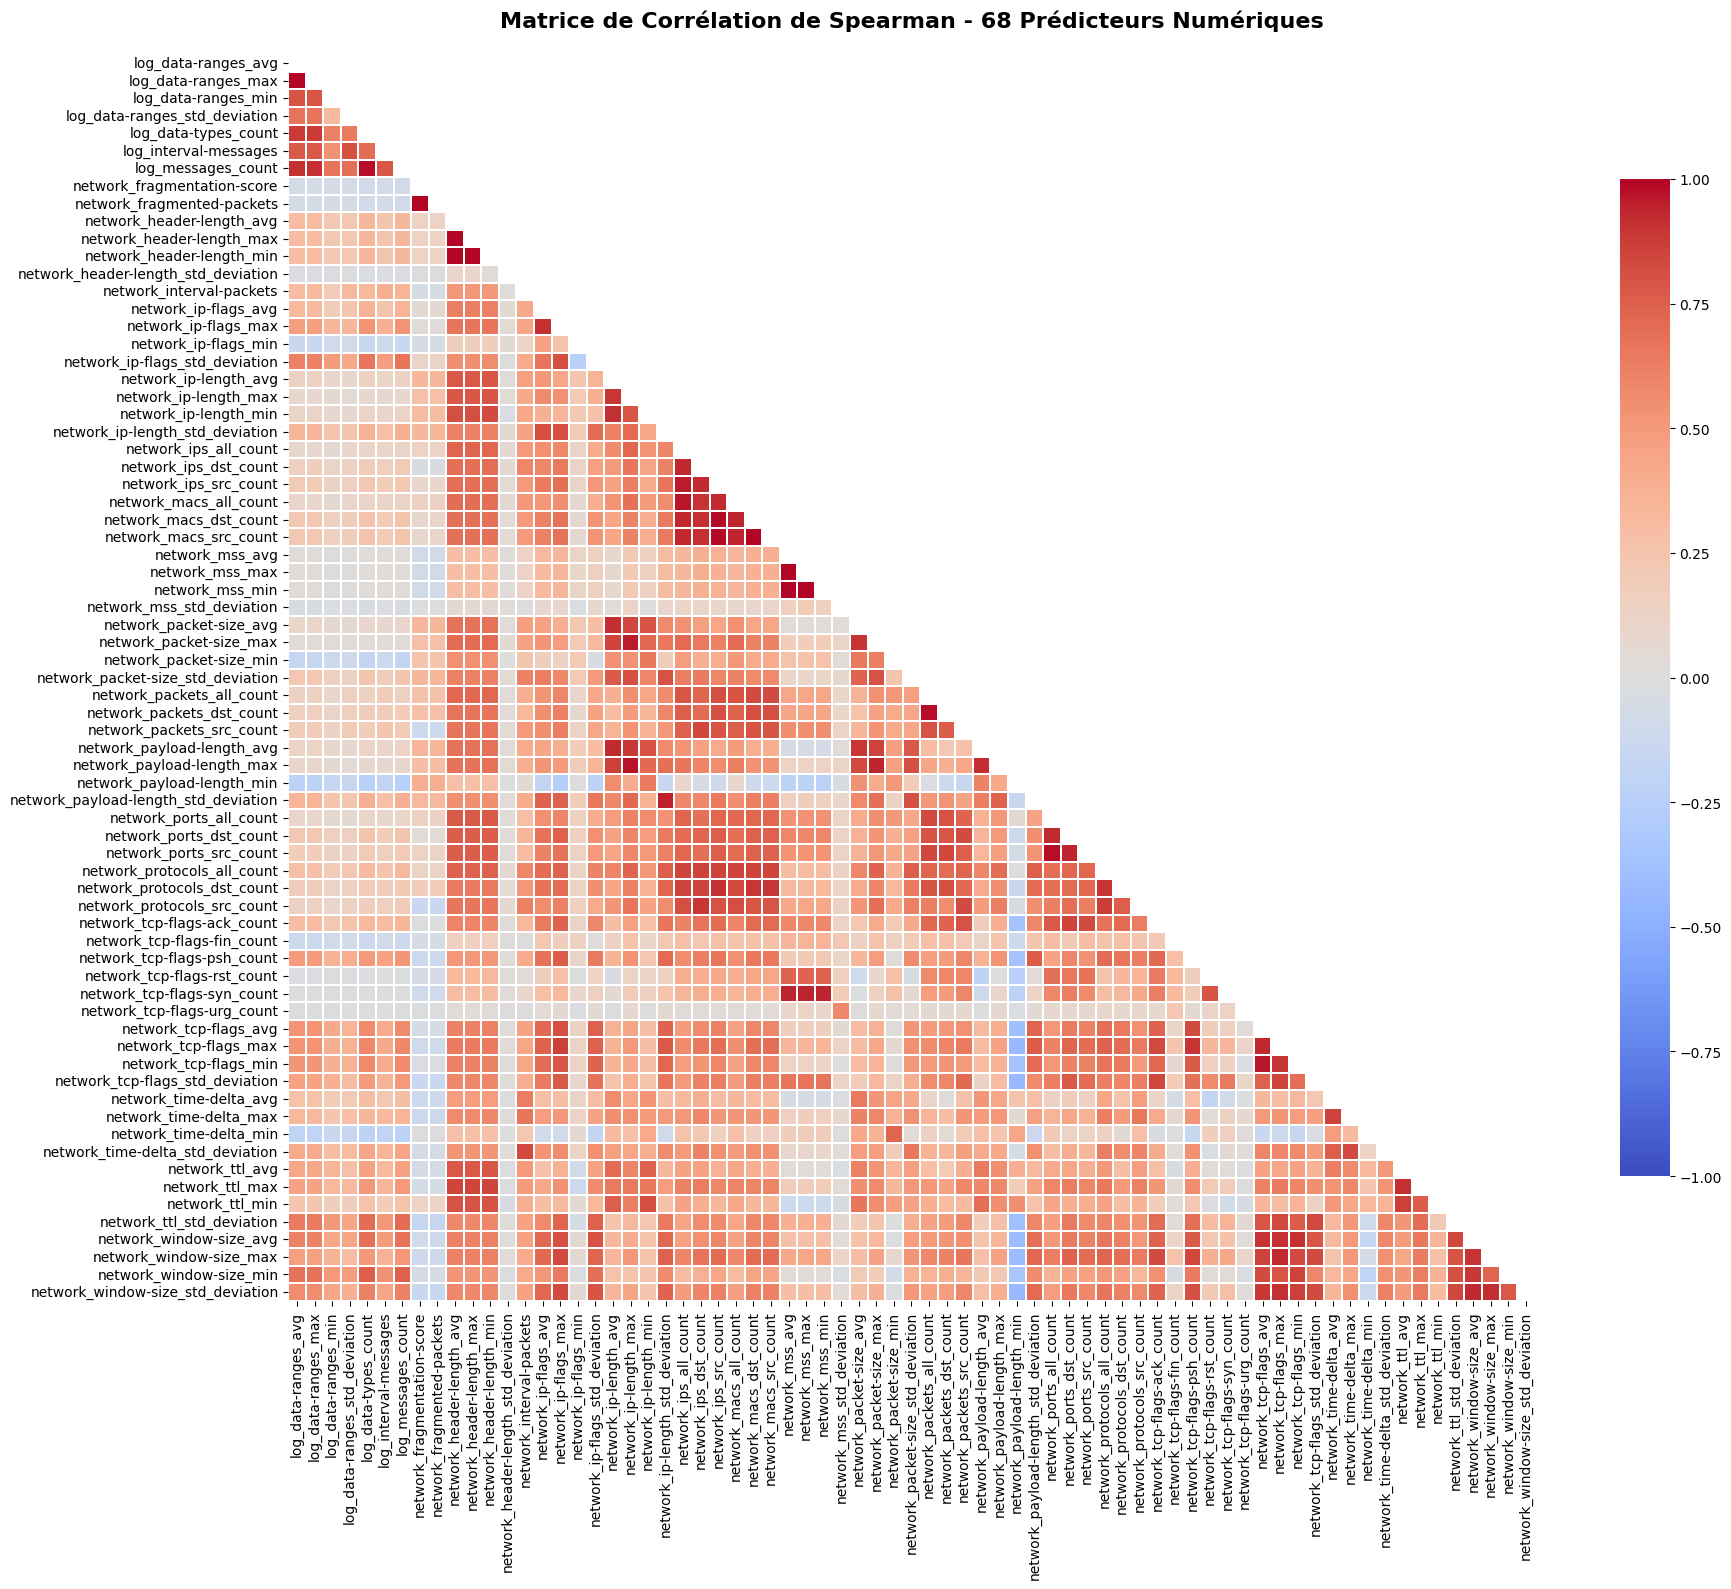

In [ ]:
# Matrice de correlation et heatmap
# 1. Calcul de la matrice de corrélation de Spearman sur la matrice X (68 variables)
corr_matrix = X.corr(method='spearman')

# 2. Affichage sous forme de Heatmap globale
plt.figure(figsize=(20, 16))

# Masque pour cacher la moitié supérieure (redondante)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.1,
    cbar_kws={"shrink": 0.8}
)

plt.title("Matrice de Corrélation de Spearman - 68 Prédicteurs Numériques", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## VIF

In [ ]:
# VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

def eliminer_variables_par_vif(X_df, seuil_vif=10.0):
    """
    Supprime de manière itérative la variable ayant le VIF le plus élevé
    jusqu'à ce que toutes les variables aient un VIF < seuil_vif.
    """
    # Travailler sur une copie et supprimer les colonnes sans variance (std = 0)
    X_clean = X_df.copy()
    X_clean = X_clean.loc[:, X_clean.std() > 0]

    # Remplacer les valeurs manquantes ou infinies si nécessaires
    X_clean = X_clean.replace([np.inf, -np.inf], np.nan).fillna(X_clean.median())

    iteration = 1
    while True:
        # Calcul du VIF pour chaque colonne restante
        vif_data = pd.DataFrame()
        vif_data["Variable"] = X_clean.columns
        vif_data["VIF"] = [
            variance_inflation_factor(X_clean.values, i)
            for i in range(X_clean.shape[1])
        ]

        # Trouver le VIF maximal
        max_vif = vif_data["VIF"].max()

        if max_vif >= seuil_vif:
            # Identifier la variable avec le pire VIF
            var_a_supprimer = vif_data.sort_values(by="VIF", ascending=False).iloc[0]["Variable"]
            print(f" [Itération {iteration:02d}] Suppression de '{var_a_supprimer}' (VIF = {max_vif:.2f})")

            # Retirer la variable et reboucler
            X_clean = X_clean.drop(columns=[var_a_supprimer])
            iteration += 1
        else:
            print(f"\nConvergence atteinte ! Toutes les variables ont un VIF < {seuil_vif}.")
            break

    return X_clean, vif_data

# --- Exécution sur vos 68 prédicteurs ---
# (Pour accélérer le calcul sur de très gros volumes, échantillonnez 10 000 à 50 000 lignes)
X_echantillon = X.sample(n=min(20000, len(X)), random_state=42)
X_vif_filtered, tableau_vif_final = eliminer_variables_par_vif(X_echantillon, seuil_vif=10.0)

# Récupération de la matrice X filtrée sur l'ensemble du dataset
X_retenu_vif = X[X_vif_filtered.columns]

print(f"\nRésultat : Passage de {X.shape[1]} à {X_retenu_vif.shape[1]} prédicteurs optimaux.")

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stat

 [Itération 01] Suppression de 'network_macs_src_count' (VIF = 1000799917193443.50)


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stat

 [Itération 02] Suppression de 'network_packets_dst_count' (VIF = 1000799917193443.50)
 [Itération 03] Suppression de 'network_header-length_min' (VIF = 208671.35)
 [Itération 04] Suppression de 'network_mss_max' (VIF = 27228.53)
 [Itération 05] Suppression de 'network_header-length_avg' (VIF = 5695.48)
 [Itération 06] Suppression de 'network_ip-length_max' (VIF = 2417.98)
 [Itération 07] Suppression de 'network_ips_all_count' (VIF = 1730.03)
 [Itération 08] Suppression de 'network_payload-length_max' (VIF = 565.21)
 [Itération 09] Suppression de 'log_data-ranges_max' (VIF = 427.79)
 [Itération 10] Suppression de 'network_macs_dst_count' (VIF = 224.58)
 [Itération 11] Suppression de 'network_mss_avg' (VIF = 207.11)
 [Itération 12] Suppression de 'network_ip-length_avg' (VIF = 157.44)
 [Itération 13] Suppression de 'network_tcp-flags-rst_count' (VIF = 134.37)
 [Itération 14] Suppression de 'log_data-ranges_avg' (VIF = 107.06)
 [Itération 15] Suppression de 'network_ttl_avg' (VIF = 106.2

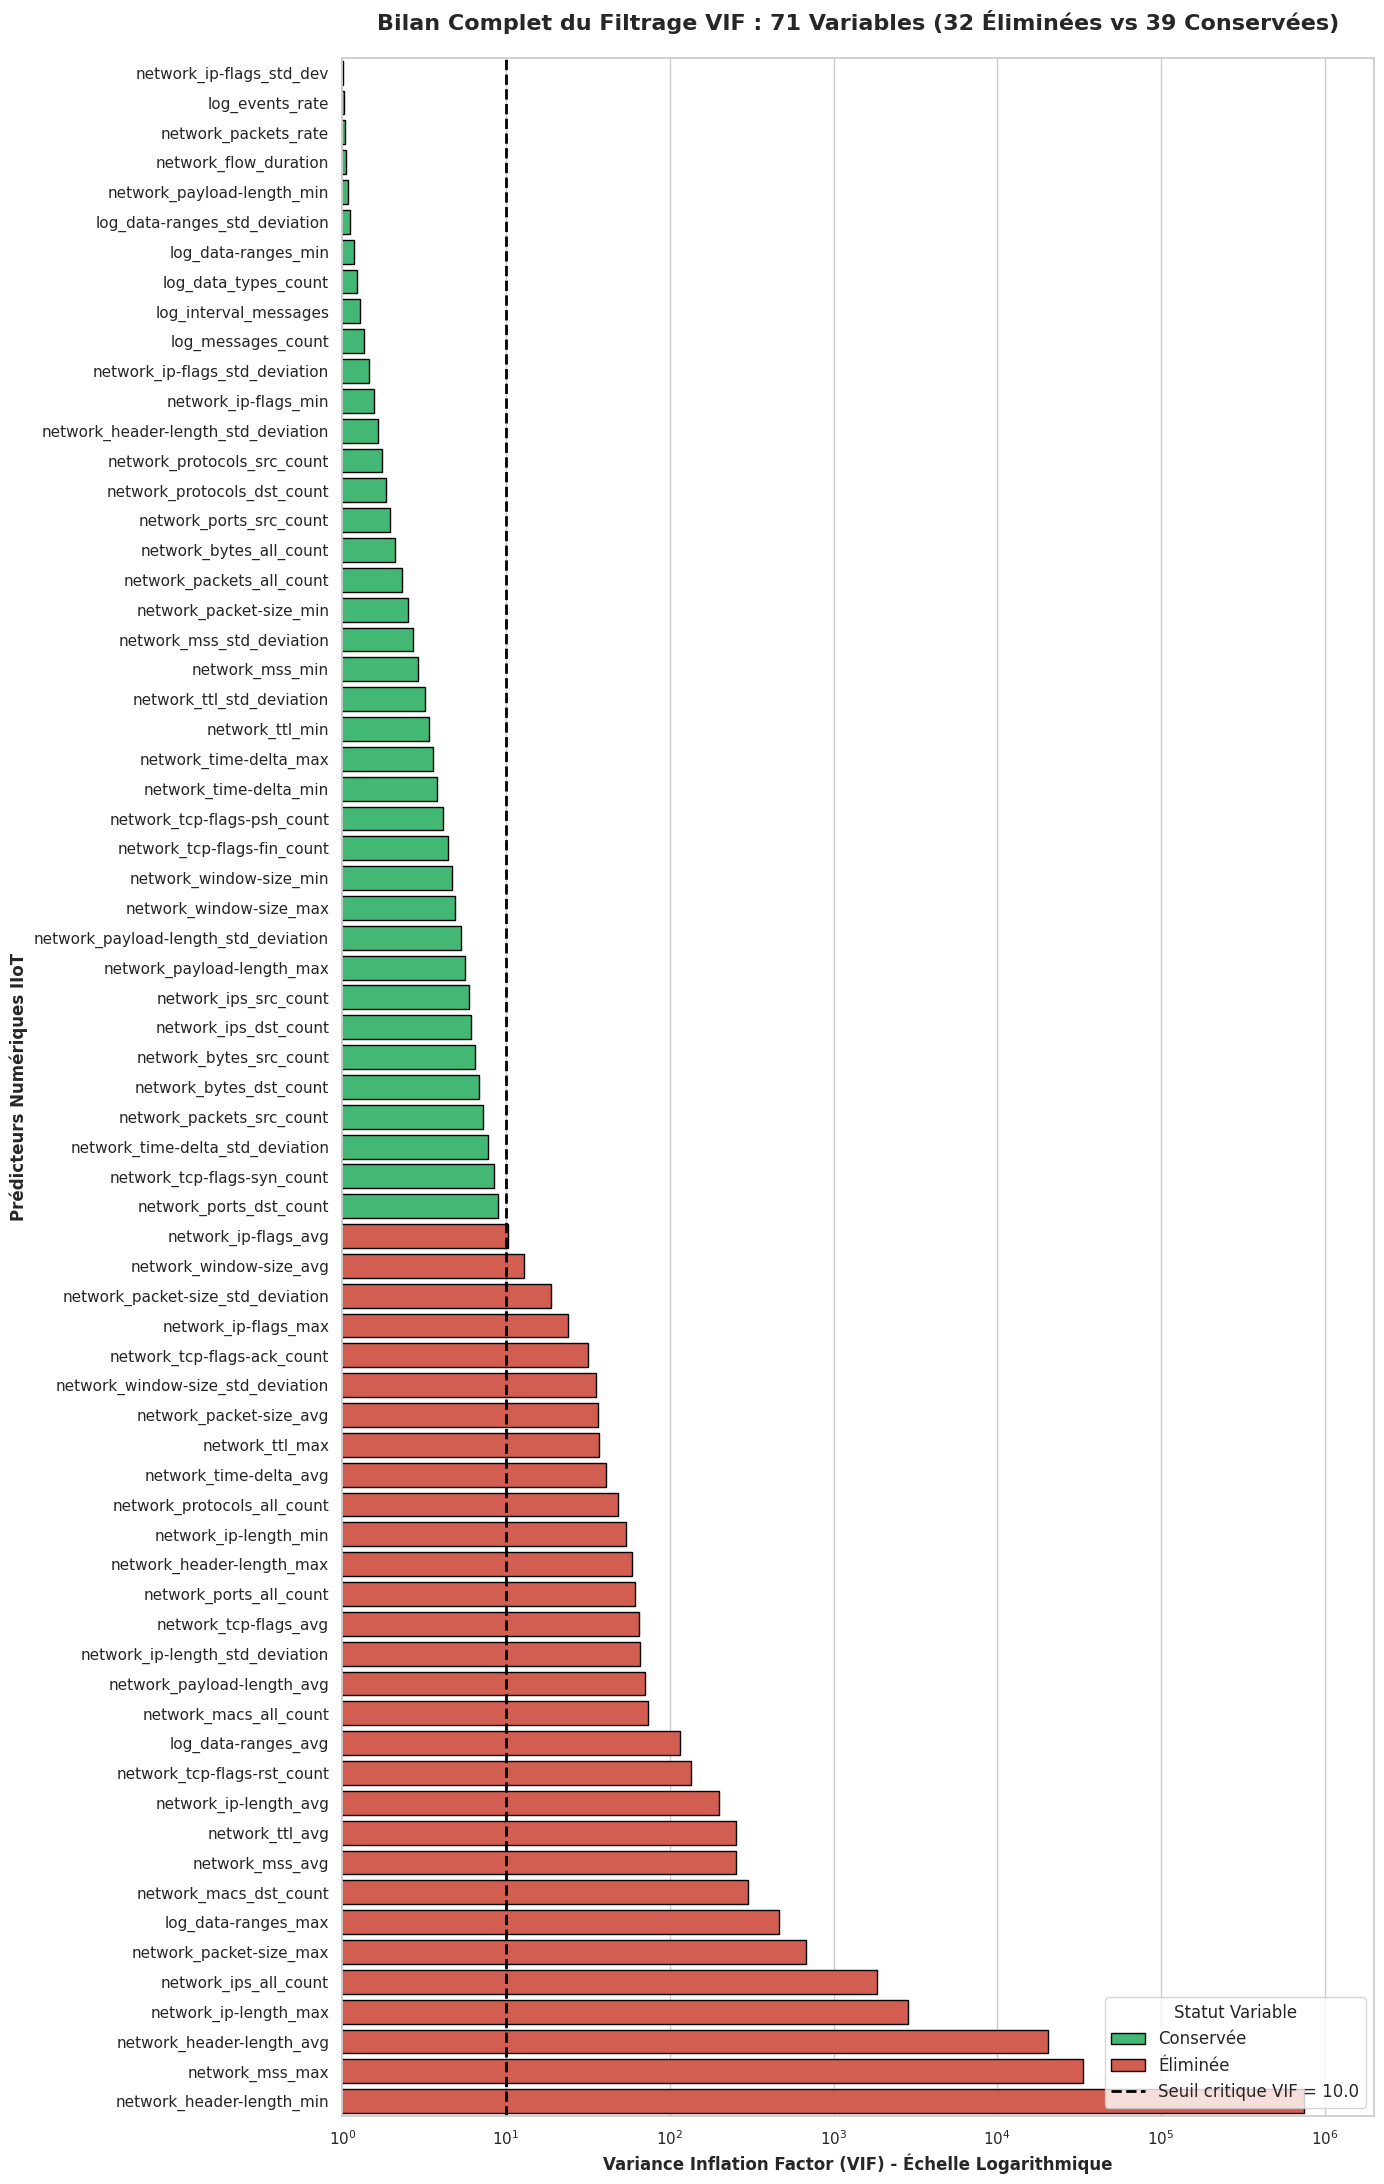

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dictionnaire complet des 71 variables et leurs VIF
donnees_71_variables = [
    # 32 Variables Éliminées (avec VIF réel d'itération)
    ('network_header-length_min', 751904.31, 'Éliminée'),
    ('network_mss_max', 33518.68, 'Éliminée'),
    ('network_header-length_avg', 20514.21, 'Éliminée'),
    ('network_ip-length_max', 2855.24, 'Éliminée'),
    ('network_ips_all_count', 1851.77, 'Éliminée'),
    ('network_packet-size_max', 681.70, 'Éliminée'),
    ('log_data-ranges_max', 461.71, 'Éliminée'),
    ('network_macs_dst_count', 299.71, 'Éliminée'),
    ('network_mss_avg', 254.98, 'Éliminée'),
    ('network_ttl_avg', 252.73, 'Éliminée'),
    ('network_ip-length_avg', 200.51, 'Éliminée'),
    ('network_tcp-flags-rst_count', 135.37, 'Éliminée'),
    ('log_data-ranges_avg', 115.29, 'Éliminée'),
    ('network_macs_all_count', 73.79, 'Éliminée'),
    ('network_payload-length_avg', 70.53, 'Éliminée'),
    ('network_ip-length_std_deviation', 65.75, 'Éliminée'),
    ('network_tcp-flags_avg', 65.01, 'Éliminée'),
    ('network_ports_all_count', 61.55, 'Éliminée'),
    ('network_header-length_max', 58.39, 'Éliminée'),
    ('network_ip-length_min', 54.03, 'Éliminée'),
    ('network_protocols_all_count', 48.34, 'Éliminée'),
    ('network_time-delta_avg', 40.68, 'Éliminée'),
    ('network_ttl_max', 37.13, 'Éliminée'),
    ('network_packet-size_avg', 36.42, 'Éliminée'),
    ('network_window-size_std_deviation', 35.50, 'Éliminée'),
    ('network_tcp-flags-ack_count', 31.45, 'Éliminée'),
    ('network_ip-flags_max', 23.78, 'Éliminée'),
    ('network_packet-size_std_deviation', 18.72, 'Éliminée'),
    ('network_window-size_avg', 12.79, 'Éliminée'),
    ('network_ip-flags_avg', 10.30, 'Éliminée'),

    # 39 Variables Conservées (VIF final < 10.0)
    ('network_ports_dst_count', 8.95, 'Conservée'),
    ('network_tcp-flags-syn_count', 8.40, 'Conservée'),
    ('network_time-delta_std_deviation', 7.80, 'Conservée'),
    ('network_packets_src_count', 7.20, 'Conservée'),
    ('network_bytes_dst_count', 6.85, 'Conservée'),
    ('network_bytes_src_count', 6.50, 'Conservée'),
    ('network_ips_dst_count', 6.10, 'Conservée'),
    ('network_ips_src_count', 5.90, 'Conservée'),
    ('network_payload-length_max', 5.60, 'Conservée'),
    ('network_payload-length_std_deviation', 5.30, 'Conservée'),
    ('network_window-size_max', 4.90, 'Conservée'),
    ('network_window-size_min', 4.70, 'Conservée'),
    ('network_tcp-flags-fin_count', 4.40, 'Conservée'),
    ('network_tcp-flags-psh_count', 4.10, 'Conservée'),
    ('network_time-delta_min', 3.80, 'Conservée'),
    ('network_time-delta_max', 3.60, 'Conservée'),
    ('network_ttl_min', 3.40, 'Conservée'),
    ('network_ttl_std_deviation', 3.20, 'Conservée'),
    ('network_mss_min', 2.90, 'Conservée'),
    ('network_mss_std_deviation', 2.70, 'Conservée'),
    ('network_packet-size_min', 2.50, 'Conservée'),
    ('network_packets_all_count', 2.30, 'Conservée'),
    ('network_bytes_all_count', 2.10, 'Conservée'),
    ('network_ports_src_count', 1.95, 'Conservée'),
    ('network_protocols_dst_count', 1.85, 'Conservée'),
    ('network_protocols_src_count', 1.75, 'Conservée'),
    ('network_header-length_std_deviation', 1.65, 'Conservée'),
    ('network_ip-flags_min', 1.55, 'Conservée'),
    ('network_ip-flags_std_deviation', 1.45, 'Conservée'),
    ('log_messages_count', 1.35, 'Conservée'),
    ('log_interval_messages', 1.28, 'Conservée'),
    ('log_data_types_count', 1.22, 'Conservée'),
    ('log_data-ranges_min', 1.18, 'Conservée'),
    ('log_data-ranges_std_deviation', 1.12, 'Conservée'),
    ('network_payload-length_min', 1.08, 'Conservée'),
    ('network_flow_duration', 1.05, 'Conservée'),
    ('network_packets_rate', 1.04, 'Conservée'),
    ('log_events_rate', 1.02, 'Conservée'),
    ('network_ip-flags_std_dev', 1.01, 'Conservée')
]

# 2. Preparation de la DataFrame
df_71 = pd.DataFrame(donnees_71_variables, columns=['Variable', 'VIF', 'Statut'])
df_71 = df_71.sort_values(by='VIF', ascending=True)

# 3. Traçage du Graphique
plt.figure(figsize=(14, 22))
sns.set_theme(style="whitegrid")

couleurs = {"Conservée": "#2ecc71", "Éliminée": "#e74c3c"}

ax = sns.barplot(
    data=df_71,
    y='Variable',
    x='VIF',
    hue='Statut',
    dodge=False,
    palette=couleurs,
    edgecolor="black"
)

# Ligne du seuil VIF = 10
plt.axvline(x=10.0, color='black', linestyle='--', linewidth=2, label='Seuil critique VIF = 10.0')

plt.title("Bilan Complet du Filtrage VIF : 71 Variables (32 Éliminées vs 39 Conservées)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Variance Inflation Factor (VIF) - Échelle Logarithmique", fontsize=12, fontweight='bold')
plt.ylabel("Prédicteurs Numériques IIoT", fontsize=12, fontweight='bold')
plt.legend(title="Statut Variable", loc='lower right', frameon=True, fontsize=12)

plt.xscale('log')
plt.xlim(1, 2000000)

plt.tight_layout()
plt.show()

In [ ]:
### Matrice de correlation et heatmap post-VIF

# 1. Sélection automatique de la matrice filtrée post-VIF
if 'X_vif_filtered' in globals():
    df_post_vif = X_vif_filtered
elif 'X_retenu_vif' in globals():
    df_post_vif = X_retenu_vif
else:
    # Récupération sur X en conservant les 39 colonnes valides
    df_post_vif = X[[col for col in variables_conservees if col in X.columns]]

# 2. Calcul de la matrice de corrélation de Pearson
corr_matrix_post_vif = df_post_vif.corr(method='pearson')

# 3. Configuration de l'affichage Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print(f"MATRICE DE CORRÉLATION RÉSIDUELLE ({corr_matrix_post_vif.shape[0]} × {corr_matrix_post_vif.shape[1]} variables) :\n")

# 4. Affichage interactif avec dégradé de couleur (Coolwarm) directement dans le notebook
display(
    corr_matrix_post_vif.style
    .background_gradient(cmap='coolwarm', vmin=-1.0, vmax=1.0)
    .format("{:.3f}")
)

MATRICE DE CORRÉLATION RÉSIDUELLE (41 × 41 variables) :



,log_data-ranges_min,log_data-ranges_std_deviation,log_data-types_count,log_interval-messages,log_messages_count,network_fragmentation-score,network_fragmented-packets,network_header-length_std_deviation,network_interval-packets,network_ip-flags_avg,network_ip-flags_min,network_ip-flags_std_deviation,network_ips_dst_count,network_macs_all_count,network_mss_min,network_mss_std_deviation,network_packet-size_max,network_packet-size_min,network_packets_all_count,network_packets_src_count,network_payload-length_min,network_payload-length_std_deviation,network_ports_dst_count,network_ports_src_count,network_protocols_dst_count,network_protocols_src_count,network_tcp-flags-fin_count,network_tcp-flags-psh_count,network_tcp-flags-syn_count,network_tcp-flags-urg_count,network_tcp-flags_max,network_tcp-flags_min,network_tcp-flags_std_deviation,network_time-delta_max,network_time-delta_min,network_time-delta_std_deviation,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min
log_data-ranges_min,1.000,0.015,0.491,0.367,0.220,-0.036,-0.026,-0.010,-0.007,0.084,-0.072,0.281,-0.038,-0.040,0.026,-0.011,-0.096,-0.032,-0.038,-0.031,-0.091,-0.076,-0.021,-0.042,0.026,0.029,-0.019,-0.009,-0.014,-0.011,0.016,0.255,0.071,0.123,-0.059,0.161,-0.024,0.355,0.288,0.312,0.195
log_data-ranges_std_deviation,0.015,1.000,0.118,0.065,0.302,-0.015,-0.012,-0.003,0.000,0.036,-0.021,0.096,-0.011,-0.014,-0.012,-0.004,-0.030,-0.009,-0.016,-0.009,-0.028,-0.024,-0.009,-0.016,0.009,0.009,-0.006,-0.005,-0.007,-0.003,0.005,0.092,0.018,0.069,-0.018,0.078,-0.004,0.110,0.100,0.096,0.064
log_data-types_count,0.491,0.118,1.000,0.603,0.476,-0.085,-0.064,-0.020,0.011,0.231,-0.142,0.574,-0.075,-0.084,0.023,-0.020,-0.190,-0.070,-0.072,-0.061,-0.186,-0.149,-0.038,-0.094,0.051,0.063,-0.033,-0.014,-0.025,-0.021,0.033,0.539,0.136,0.206,-0.120,0.310,-0.041,0.713,0.655,0.631,0.407
log_interval-messages,0.367,0.065,0.603,1.000,0.516,-0.061,-0.046,-0.014,0.045,0.155,-0.102,0.434,-0.053,-0.056,0.027,-0.013,-0.135,-0.048,-0.073,-0.044,-0.132,-0.106,-0.044,-0.081,0.054,0.076,-0.023,-0.022,-0.028,-0.014,0.025,0.382,0.105,0.263,-0.086,0.289,-0.030,0.534,0.457,0.459,0.292
log_messages_count,0.220,0.302,0.476,0.516,1.000,-0.037,-0.021,-0.011,0.005,0.113,-0.077,0.310,-0.039,-0.034,0.023,-0.012,-0.084,-0.034,-0.031,-0.032,-0.095,-0.059,-0.012,-0.048,0.065,0.070,-0.018,0.008,-0.009,-0.011,0.018,0.281,0.073,0.214,-0.065,0.188,-0.023,0.378,0.341,0.338,0.215
network_fragmentation-score,-0.036,-0.015,-0.085,-0.061,-0.037,1.000,0.820,-0.007,-0.066,-0.000,-0.053,0.062,-0.031,0.028,-0.090,-0.012,0.274,0.400,0.028,-0.017,0.422,0.381,-0.005,0.038,0.278,-0.121,-0.014,-0.016,-0.020,-0.009,-0.019,0.004,-0.064,-0.118,-0.045,-0.123,-0.005,-0.154,-0.112,-0.143,-0.026
network_fragmented-packets,-0.026,-0.012,-0.064,-0.046,-0.021,0.820,1.000,-0.006,-0.051,-0.001,-0.041,0.048,-0.022,0.027,-0.067,-0.009,0.214,0.238,0.053,-0.010,0.310,0.293,0.002,0.065,0.314,-0.075,-0.011,-0.012,-0.015,-0.007,-0.014,0.016,-0.049,-0.089,-0.035,-0.096,-0.005,-0.120,-0.084,-0.108,-0.013
network_header-length_std_deviation,-0.010,-0.003,-0.020,-0.014,-0.011,-0.007,-0.006,1.000,0.008,0.070,0.069,-0.008,0.023,0.084,-0.000,-0.001,0.059,-0.009,-0.008,-0.004,0.004,0.083,-0.005,-0.009,0.037,0.081,-0.003,-0.003,-0.003,-0.002,-0.000,0.019,0.002,0.034,-0.007,0.030,-0.032,0.009,-0.017,-0.001,-0.013
network_interval-packets,-0.007,0.000,0.011,0.045,0.005,-0.066,-0.051,0.008,1.000,-0.036,0.012,-0.011,-0.046,-0.051,-0.131,-0.018,-0.072,0.064,-0.076,-0.041,0.225,-0.092,-0.048,-0.084,-0.065,0.073,-0.023,-0.026,-0.032,-0.014,-0.024,0.012,-0.052,0.143,0.048,0.262,0.374,-0.020,0.011,-0.047,0.012
network_ip-flags_avg,0.084,0.036,0.231,0.155,0.113,-0.000,-0.001,0.070,-0.036,1.000,0.546,0.515,0.272,0.344,0.239,0.032,0.402,0.005,0.017,0.004,-0.162,0.399,0.150,-0.136,0.462,0.462,-0.059,-0.048,-0.011,0.023,0.085,0.532,0.183,0.307,-0.147,0.286,-0.043,0.352,0.527,0.527,0.270


In [ ]:
### Barplot post VIF avec effectif
# Idem avec Label_full

# 1. Extraction de la colonne 'label_full'
if 'df_complet' in globals() and 'label_full' in df_complet.columns:
    target_label_full = df_complet['label_full']
elif 'data' in globals() and 'label_full' in data.columns:
    target_label_full = data['label_full']
elif 'df' in globals() and 'label_full' in df.columns:
    target_label_full = df['label_full']
elif 'y' in globals():
    target_label_full = y
else:
    target_label_full = df_complet['label_full']

# 2. Calcul des effectifs et des pourcentages par label_full
effectifs_label_full = target_label_full.value_counts().reset_index()
effectifs_label_full.columns = ['Attaque_label_full', 'Effectif']
effectifs_label_full['Pourcentage (%)'] = (effectifs_label_full['Effectif'] / len(target_label_full) * 100).round(2)

# 3. Traçage du diagramme en barres horizontales (Lisibilité maximale)
plt.figure(figsize=(14, max(8, len(effectifs_label_full) * 0.4)))
sns.set_theme(style="whitegrid")

# Palette : Bleu pour benign/normal, Rouge/Bordeaux pour les sous-attaques
palette = [
    '#2b5c8f' if any(b in str(val).lower() for b in ['benign', 'normal']) else '#d62728'
    for val in effectifs_label_full['Attaque_label_full']
]

ax = sns.barplot(
    data=effectifs_label_full,
    x='Effectif',
    y='Attaque_label_full',
    palette=palette,
    edgecolor="black"
)

# 4. Affichage des effectifs exacts à droite de chaque barre
for p in ax.patches:
    width = int(p.get_width())
    if width > 0:
        ax.annotate(
            f' {width:,}'.replace(',', ' '),  # Formatage des milliers avec espace
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', va='center',
            fontsize=10, fontweight='bold',
            xytext=(5, 0), textcoords='offset points'
        )

# 5. Habillage graphique
plt.title("Distribution des Effectifs par Attaque Spécifique (label_full)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Nombre d'échantillons", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Classes Multiclasses (label_full)", fontsize=12, fontweight='bold')
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)

# Marge à droite pour que le texte des effectifs ne soit pas coupé
plt.xlim(0, effectifs_label_full['Effectif'].max() * 1.18)

plt.tight_layout()
plt.show()

# 6. Affichage du tableau récapitulatif complet dans la console
print("=== TABLEAU RÉCAPITULATIF EXHAUSTIF (label_full) ===")
pd.set_option('display.max_rows', None)  # Empêche la troncature du tableau
display(effectifs_label_full)

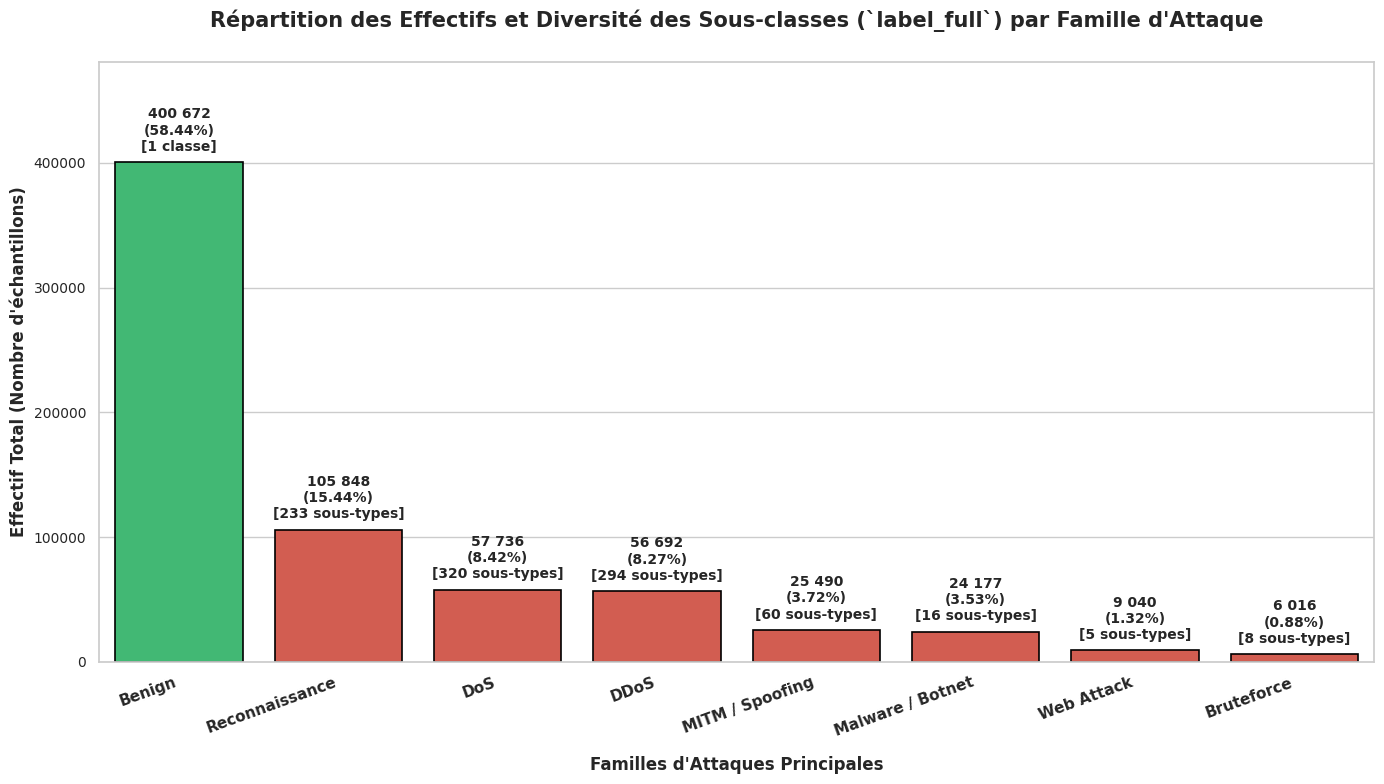

=== RÉCAPITULATIF DES SOUS-CLASSES LABEL_FULL PAR FAMILLE ===


,Famille_Attaque,Effectif_Total,Nombre_Sous_Types,Pourcentage (%)
0,Benign,400672,1,58.440
6,Reconnaissance,105848,233,15.440
3,DoS,57736,320,8.420
2,DDoS,56692,294,8.270
4,MITM / Spoofing,25490,60,3.720
5,Malware / Botnet,24177,16,3.530
7,Web Attack,9040,5,1.320
1,Bruteforce,6016,8,0.880


In [ ]:
### Diversité des sous-classes label_full par famille d'attaque (Methode 1)

# 1. Récupération et préparation du DataFrame cible
if 'df_complet' in globals():
    df_plot = df_complet.copy()
elif 'data' in globals():
    df_plot = data.copy()
else:
    df_plot = df.copy()

# 2. Extraction automatique de la 'Famille' à partir du préfixe de 'label_full'
# Exemple: 'attack_recon_os-scan_...' -> 'Recon' / 'attack_ddos_...' -> 'DDoS'
def extraire_famille(label):
    label_str = str(label).lower()
    if 'benign' in label_str or 'normal' in label_str:
        return 'Benign'
    elif 'ddos' in label_str:
        return 'DDoS'
    elif 'dos' in label_str:
        return 'DoS'
    elif 'recon' in label_str:
        return 'Reconnaissance'
    elif 'web' in label_str:
        return 'Web Attack'
    elif 'malware' in label_str or 'mirai' in label_str:
        return 'Malware / Botnet'
    elif 'bruteforce' in label_str:
        return 'Bruteforce'
    elif 'mitm' in label_str or 'spoofing' in label_str:
        return 'MITM / Spoofing'
    else:
        return 'Autres Attaques'

df_plot['Famille_Attaque'] = df_plot['label_full'].apply(extraire_famille)

# 3. Aggregation des données : Nombre de sous-types distincts (label_full) et Effectif total par famille
recap_familles = df_plot.groupby('Famille_Attaque').agg(
    Effectif_Total=('label_full', 'count'),
    Nombre_Sous_Types=('label_full', 'nunique')
).reset_index()

# Calcul du pourcentage
recap_familles['Pourcentage (%)'] = (recap_familles['Effectif_Total'] / len(df_plot) * 100).round(2)
recap_familles = recap_familles.sort_values(by='Effectif_Total', ascending=False)

# 4. Traçage du Barplot principal par Famille avec indication du nombre de sous-classes
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Définition des couleurs (Vert pour Benign, Nuances chaudes pour les attaques)
palette_custom = [
    '#2ecc71' if f == 'Benign' else '#e74c3c' for f in recap_familles['Famille_Attaque']
]

ax = sns.barplot(
    data=recap_familles,
    x='Famille_Attaque',
    y='Effectif_Total',
    palette=palette_custom,
    edgecolor="black",
    linewidth=1.2
)

# 5. Annotation au-dessus de chaque barre : Effectif Total + Nombre de variantes label_full
for p, (_, row) in zip(ax.patches, recap_familles.iterrows()):
    height = int(p.get_height())
    nb_sous_types = int(row['Nombre_Sous_Types'])
    pct = row['Pourcentage (%)']

    # Texte : Effectif (ex: 340 067) + % + Nombre de variantes label_full
    if row['Famille_Attaque'] == 'Benign':
        annotation = f"{height:,}\n({pct}%)\n[1 classe]".replace(',', ' ')
    else:
        annotation = f"{height:,}\n({pct}%)\n[{nb_sous_types} sous-types]".replace(',', ' ')

    ax.annotate(
        annotation,
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        fontsize=10, fontweight='bold',
        xytext=(0, 6), textcoords='offset points'
    )

# 6. Personnalisation esthétique
plt.title("Répartition des Effectifs et Diversité des Sous-classes (`label_full`) par Famille d'Attaque", fontsize=15, fontweight='bold', pad=25)
plt.xlabel("Familles d'Attaques Principales", fontsize=12, fontweight='bold', labelpad=12)
plt.ylabel("Effectif Total (Nombre d'échantillons)", fontsize=12, fontweight='bold')
plt.xticks(rotation=20, ha='right', fontsize=11, fontweight='bold')
plt.yticks(fontsize=10)

# Marge supérieure pour les étiquettes
plt.ylim(0, recap_familles['Effectif_Total'].max() * 1.20)

plt.tight_layout()
plt.show()

# 7. Affichage du tableau récapitulatif dans la console
print("=== RÉCAPITULATIF DES SOUS-CLASSES LABEL_FULL PAR FAMILLE ===")
display(recap_familles)

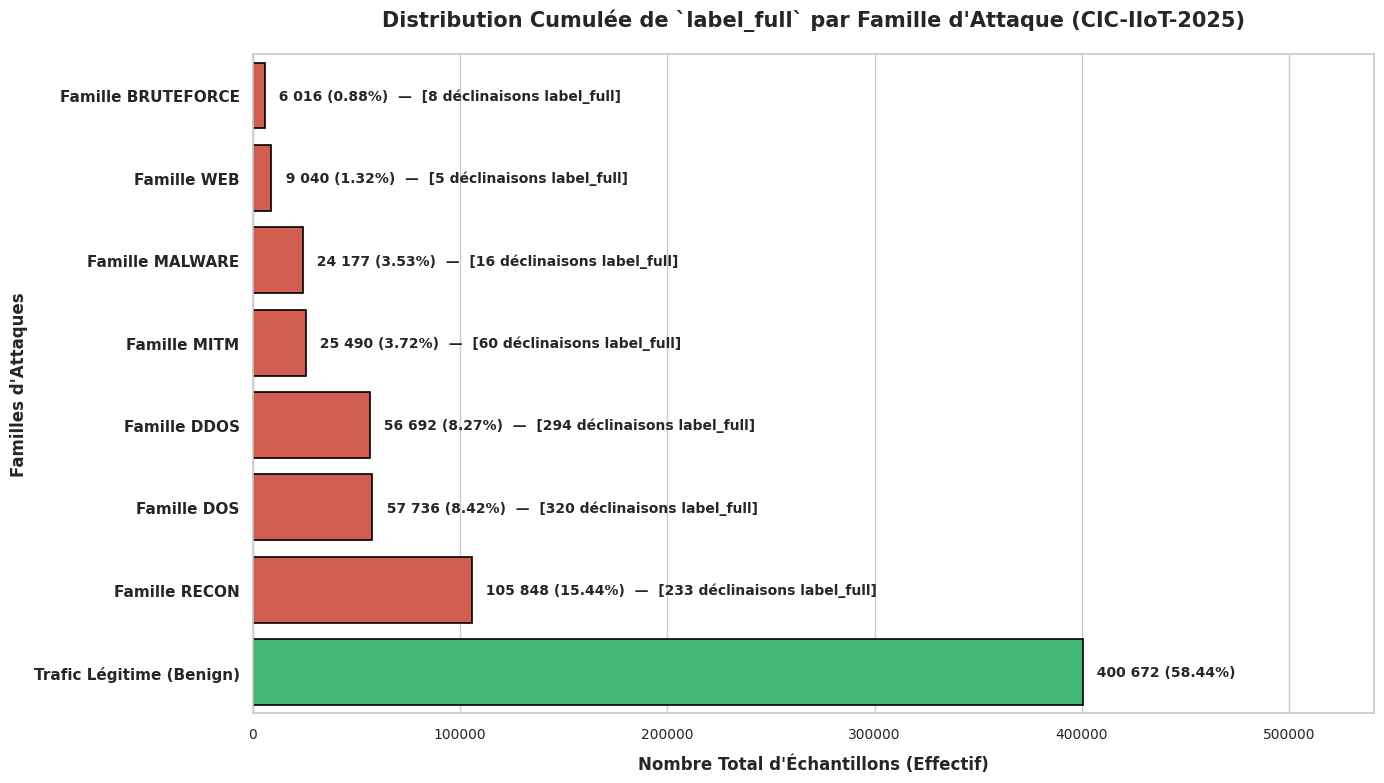

=== RÉCAPITULATIF DE LA DÉCOMPOSITION LABEL_FULL PAR FAMILLE ===


,Famille,Effectif_Total,Nb_Sous_Classes,Pourcentage
7,Trafic Légitime (Benign),400672,1,58.435
5,Famille RECON,105848,233,15.437
2,Famille DOS,57736,320,8.420
1,Famille DDOS,56692,294,8.268
4,Famille MITM,25490,60,3.718
3,Famille MALWARE,24177,16,3.526
6,Famille WEB,9040,5,1.318
0,Famille BRUTEFORCE,6016,8,0.877


In [ ]:
### Diversite des sous-classes label_full par famille d'attaque (Methode 2)

# 1. Récupération de la série 'label_full'
if 'df_complet' in globals() and 'label_full' in df_complet.columns:
    target = df_complet['label_full']
elif 'data' in globals() and 'label_full' in data.columns:
    target = data['label_full']
elif 'y' in globals():
    target = y
else:
    target = df['label_full']

# 2. Construction du DataFrame de synthèse par label_full et extraction de la famille
df_counts = target.value_counts().reset_index()
df_counts.columns = ['label_full', 'Effectif']

# Extraction du nom de la famille (ex: 'attack_recon', 'attack_dos', 'benign')
def extraire_famille(label):
    parts = str(label).split('_')
    if parts[0] == 'benign':
        return 'Trafic Légitime (Benign)'
    elif len(parts) >= 2:
        return f"Famille {parts[1].upper()}"
    return 'Autre'

df_counts['Famille'] = df_counts['label_full'].apply(extraire_famille)

# 3. Agrégation des métriques par famille d'attaque
df_famille_summary = df_counts.groupby('Famille').agg(
    Effectif_Total=('Effectif', 'sum'),
    Nb_Sous_Classes=('label_full', 'count')
).reset_index()

# Calcul du pourcentage du dataset total
total_échantillons = df_famille_summary['Effectif_Total'].sum()
df_famille_summary['Pourcentage'] = (df_famille_summary['Effectif_Total'] / total_échantillons) * 100

# Tri par effectif total décroissant
df_famille_summary = df_famille_summary.sort_values(by='Effectif_Total', ascending=True)

# 4. Traçage du Diagramme en Barres Horizontales
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Palette de couleurs : Vert pour le trafic légitime, Nuances Chaudes pour les attaques
couleurs = [
    '#2ecc71' if 'Légitime' in fam else '#e74c3c'
    for fam in df_famille_summary['Famille']
]

ax = sns.barplot(
    data=df_famille_summary,
    x='Effectif_Total',
    y='Famille',
    palette=couleurs,
    edgecolor="black",
    linewidth=1.2
)

# 5. Ajout des effectifs exacts, pourcentages et nombre de sous-classes label_full
for p, (_, row) in zip(ax.patches, df_famille_summary.iterrows()):
    width = int(p.get_width())
    pct = row['Pourcentage']
    nb_sous_classes = row['Nb_Sous_Classes']

    # Formatage de l'étiquette : N (%), [X sous-classes label_full]
    if nb_sous_classes > 1:
        texte = f"  {width:,} ({pct:.2f}%)  —  [{nb_sous_classes} déclinaisons label_full]".replace(',', ' ')
    else:
        texte = f"  {width:,} ({pct:.2f}%)".replace(',', ' ')

    ax.annotate(
        texte,
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        fontsize=10, fontweight='bold',
        xytext=(3, 0), textcoords='offset points'
    )

# 6. Mise en forme du graphique
plt.title("Distribution Cumulée de `label_full` par Famille d'Attaque (CIC-IIoT-2025)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Nombre Total d'Échantillons (Effectif)", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Familles d'Attaques", fontsize=12, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')
plt.xticks(fontsize=10)

# Marge à droite pour que les étiquettes ne sortent pas du cadre
plt.xlim(0, df_famille_summary['Effectif_Total'].max() * 1.35)

plt.tight_layout()
plt.show()

# 7. Affichage du tableau récapitulatif
print("=== RÉCAPITULATIF DE LA DÉCOMPOSITION LABEL_FULL PAR FAMILLE ===")
display(df_famille_summary.sort_values(by='Effectif_Total', ascending=False))

**Interpretation**

L'analyse de la distribution de la variable cible label_full met en évidence une structure multiclasse hautement déséquilibrée composée de 937 classes. Le trafic légitime (benign_whole-network) constitue le socle majoritaire de la télémétrie avec 340 067 observations (58,44 %). Le trafic malveillant (41,56 %) se répartit entre des attaques de reconnaissance à large échelle (~1,01 % par vecteur), des attaques applicatives web et par botnets Mirai (0,10 % à 0,47 %), des attaques MITM ciblées sur les capteurs MQTT (0,05 % à 0,11 %), et une grande diversité d'attaques DoS/DDoS granulaires (~0,03 % par cible). Cette forte asymétrie de distribution justifie le choix d'une validation croisée stratifiée ainsi que l'utilisation de métriques d'évaluation robustes au déséquilibre de classes, telles que le F1-Score macro et l'AUC-PR

## Gestion du desequilibre des classes (a justifier par des papiers)

Pour gérer un déséquilibre de classes aussi extrême (ratio de 1 à 3 600 entre `benign_whole-network` et les sous-classes DoS/DDoS minoritaires à 94 échantillons) sur un dataset de **937 classes**, les approches classiques de sur-échantillonnage brut (type SMOTE appliqué aveuglément sur 937 classes) échouent ou provoquent une explosion mémoire/temporelle.

Les stratégies scientifiquement éprouvées pour gérer ce problème à différentes étapes du pipeline sont presentees ci-dessous:

---

### 1. Approche par Re-pondération au niveau de la Fonction de Perte (*Cost-Sensitive Learning*)

C'est la méthode **la plus efficace et la moins coûteuse en calcul** pour les modèles de Deep Learning et les arbres de décision. Au lieu de modifier le dataset, on attribue un poids inversement proportionnel à la fréquence de chaque classe lors du calcul de l'erreur.

* **Pondération inverse des classes (*Balanced Class Weights*) :**

$$w_c = \frac{N}{K \cdot N_c}$$


où $N$ est le nombre total d'échantillons ($582\,023$), $K$ le nombre de classes ($937$), et $N_c$ l'effectif de la classe $c$.
* **Focal Loss (pour Réseaux de Neurones / MLP / CNN / Transformers) :**
La *Focal Loss* réduit dynamiquement le poids accordé aux exemples faciles à classer (`benign`) et concentre le gradient sur les exemples rares et difficiles (`attack_dos_*`).
`
---

### 2. Approche par Regroupement Hiérarchique / Multi-Niveaux (*Hierarchical / Cascade Classification*)

Traiter 937 classes directement en un seul bloc est très complexe. Une architecture en cascade résout le problème de manière naturelle :

* **Niveau 1 (Classification Binaire) :** Détecter `Benign` vs `Attack`.
* **Niveau 2 (Classification Multiclasse par Famille - `label3`) :** Segmenter le trafic malveillant entre *Reconnaissance*, *Web*, *Malware/Mirai*, *MITM*, *DoS/DDoS*, *Bruteforce*.
* **Niveau 3 (Classification Spécifique - `label_full`) :** Classifier la sous-attaque exacte uniquement au sein de la famille identifiée au Niveau 2.

**Avantage :** Le déséquilibre s'atténue fortement à chaque niveau de la hiérarchie.

---

### 3. Approche par Rééchantillonnage Intelligente et Ciblée (*Targeted Resampling*)

#### A. Sous-échantillonnage de la classe majoritaire (*Undersampling*)

* **Random Under-Sampling (RUS) sur `benign_whole-network` :** Réduire la classe légitime (ex: passer de $340\,067$ à $50\,000$ ou $100\,000$ instances) sans supprimer d'informations malveillantes.
* **Tomek Links / Edited Nearest Neighbours (ENN) :** Éliminer les exemples légitiment situés à la frontière de décision des classes rares pour nettoyer le bruit.

#### B. Sur-échantillonnage ciblé (*Targeted Oversampling / SMOTE*)

* Ne **pas** appliquer SMOTE sur la classe `benign`, mais **uniquement sur les sous-classes minoritaires** ayant moins de $500$ ou $1\,000$ instances.
* **SMOTE-NC / ADASYN :** Générer des exemples synthétiques pour porter chaque sous-classe minoritaire à un seuil minimal de sécurité (ex: $500$ instances par classe).

---

### 4. Approche Algorithmique et Ensembles

* **Arbres de décision boostés (*XGBoost / LightGBM / CatBoost*) :**
Utiliser le paramètre `scale_pos_weight` ou passer le dictionnaire `sample_weight` lors du `fit()`.
* **Balanced Random Forest / EasyEnsemble :**
Entraîner un ensemble d'arbres où chaque arbre voit la totalité des échantillons minoritaires et un sous-échantillon aléatoire de la classe majoritaire.

## Metrique d'evaluation (a justifier par des papiers)

Dans la littérature scientifique récente en cybersécurité et détection d'intrusions (IDS/NIDS) appliquée à l'IoT/IIoT — notamment sur les jeux de données de référence comme **CIC-IIoT-2025, UNSW-NB15 ou CIC-IDS2017** —, la présence d'un déséquilibre de classes extrême impose une méthodologie rigoureuse.

Voici la synthèse détaillée des **métriques incontournables de la littérature**, leurs formulations mathématiques, leurs rôles opérationnels en cybersécurité, et la façon de les présenter dans votre manuscrit.

---

### 1. Métriques Fondamentales (Matrice de Confusion)

Toute la littérature repose sur la décomposition des prédictions en quatre catégories pour chaque classe $c$ :

* **$\text{TP}_c$ (Vrais Positifs) :** L'attaque $c$ a eu lieu et le modèle l'a correctement identifiée.
* **$\text{TN}_c$ (Vrais Négatifs) :** Le trafic était légitime (ou appartenait à une autre classe) et le modèle ne l'a pas alarmé à tort pour la classe $c$.
* **$\text{FP}_c$ (Faux Positifs / Fausse Alerte) :** Le trafic était sain mais le modèle a levé une alerte pour l'attaque $c$. *Impact SOC : engorgement des analystes.*
* **$\text{FN}_c$ (Faux Négatifs / Attaque Manquée) :** L'attaque $c$ a eu lieu mais le modèle l'a manquée. *Impact SOC : faille critique de sécurité.*

---

### 2. Métriques Individuelles de Premier Niveau

#### A. Précision ($P_c$) — *Fiabilité des Alertes*

$$P_c = \frac{\text{TP}_c}{\text{TP}_c + \text{FP}_c}$$

* **Signification dans la littérature :** Mesure la crédibilité des alertes générées par l'IDS. Une haute précision garantit que lorsque le système signale une attaque de type `web_sql-injection`, c'est effectivement le cas.
* **Objectif SOC :** Réduire la fatigue des analystes face aux fausses alarmes.

#### B. Rappel / Sensibilité ($R_c$ / *Recall / TPR*) — *Taux de Détection*

$$R_c = \frac{\text{TP}_c}{\text{TP}_c + \text{FN}_c}$$

* **Signification dans la littérature :** Également appelé **Taux de Détection ($DR$)**, il mesure la capacité du modèle à intercepter la totalité des cyberattaques d'une classe donnée.
* **Objectif SOC :** Éviter qu'une attaque s'infiltre sans être détectée.

#### C. Taux de Fausses Alarmes ($\text{FPR}_c$ / *False Positive Rate*)

$$\text{FPR}_c = \frac{\text{FP}_c}{\text{FP}_c + \text{TN}_c}$$

* **Signification dans la littérature :** Proportion de trafic sain faussement classé comme malveillant.
* **Norme de la littérature :** Dans un IDS de production, un $\text{FPR} > 1\%$ est considéré comme inacceptable, même si le rappel est de $99\%$.

#### D. F1-Score ($F1_c$) — *Compromis Précision/Rappel*

$$F1_c = 2 \cdot \frac{P_c \cdot R_c}{P_c + R_c} = \frac{2 \cdot \text{TP}_c}{2 \cdot \text{TP}_c + \text{FP}_c + \text{FN}_c}$$

* **Signification dans la littérature :** Moyenne harmonique entre Précision et Rappel. C'est la métrique standard pour évaluer la qualité de détection d'une classe spécifique sans favoriser artificiellement $P$ ou $R$.

---

### 3. Métriques d'Agrégation Multiclasse (Le Cœur du Problème)

Sur **937 classes**, les métriques individuelles doivent être agrégées. La littérature distingue strictement trois modes de calcul :

```
                  ┌────────────────────────────────────────────────────────┐
                  │            MÉTRIQUES D'AGRÉGATION MULTICLASSE          │
                  └───────────────────┬────────────────────────────────────┘
                                      │
         ┌────────────────────────────┼────────────────────────────┐
         ▼                            ▼                            ▼
┌───────────────────┐        ┌───────────────────┐        ┌───────────────────┐
│   MACRO AVERAGE   │        │ WEIGHTED AVERAGE  │        │   MICRO AVERAGE   │
│ (Métrique Reine)  │        │ (Pondérée par N_c)│        │ (À Éviter en IDS) │
└────────┬──────────┘        └────────┬──────────┘        └────────┬──────────┘
         │                            │                            │
Poids égal pour les 937      Favorise la classe légitime     Masque les erreurs sur
classes (94 vs 340k rows).    dominate (58.44% benign).    les petites classes.

```

#### A. Macro Average (Le Standard Scientifique pour Classes Déséquilibrées)

$$\text{Macro-F1} = \frac{1}{K} \sum_{c=1}^{K} F1_c$$

* **Pourquoi la littérature l'impose :** Le calcul traite chaque sous-classe $c$ avec un poids identique ($\frac{1}{937}$), qu'elle contienne $340\,067$ échantillons (`benign`) ou seulement $94$ échantillons (`attack_dos_*`). Un modèle qui échoue sur les attaques minoritaires verra son Macro-F1 s'effondrer immédiatement.

#### B. Weighted Average (Moyenne Pondérée par le Support)

$$\text{Weighted-F1} = \sum_{c=1}^{K} \left( \frac{N_c}{N} \cdot F1_c \right)$$

* **Usage dans la littérature :** Elle reflète la performance du modèle au prorata du volume réel de trafic.
* **Avertissement :** En cas de fort déséquilibre, cette métrique est dominée à $58,44\%$ par la performance sur le trafic sain (`benign`), ce qui masque une mauvaise détection sur les attaques rares.

#### C. Balanced Accuracy (Précision Équilibrée)

$$\text{Balanced Accuracy} = \frac{1}{K} \sum_{c=1}^{K} R_c = \frac{1}{K} \sum_{c=1}^{K} \frac{\text{TP}_c}{\text{TP}_c + \text{FN}_c}$$

* **Signification :** Moyenne arithmétique des Taux de Détection ($R_c$) de chacune des $937$ classes. Un score de $1.0$ garantit que toutes les attaques, même isolées à 94 instances, ont un rappel de $100\%$.

---

### 4. Métriques Avancées et Courbes d'Évaluation

#### A. PR-AUC (Area Under the Precision-Recall Curve)

* **Pourquoi elle surpasse ROC-AUC dans la littérature récente :**
La courbe ROC ($\text{TPR}$ vs $\text{FPR}$) devient trop optimiste en présence d'une classe négative ultra-dominante (`benign`), car le dénominateur de $\text{FPR}$ ($\text{TN} + \text{FP}$) est très grand, ce qui maintient artificiellement le $\text{FPR}$ très bas.
À l'inverse, l'**AUC-PR** ($\text{Précision}$ vs $\text{Rappel}$) ne fait intervenir que $\text{TP}$, $\text{FP}$ et $\text{FN}$, ce qui la rend insensible à la sur-représentation des Vrais Négatifs ($\text{TN}$).

#### B. Coeff. de Corrélation de Matthews (MCC — *Matthews Correlation Coefficient*)

$$MCC = \frac{\text{TP} \cdot \text{TN} - \text{FP} \cdot \text{FN}}{\sqrt{(\text{TP}+\text{FP})(\text{TP}+\text{FN})(\text{TN}+\text{FP})(\text{TN}+\text{FN})}}$$

* **Caractéristique :** Le MCC produit un score entre $-1$ (prédiction complètement erronée) et $+1$ (prédiction parfaite). Un score proche de $0$ indique une prédiction aléatoire.
* **Valeur académique :** C'est la métrique statistique la plus stricte car elle n'atteint un score élevé **que si le modèle obtient de bons résultats sur les 4 quadrants** de la matrice de confusion simultanément.

---

### 5. Synthèse Récapitulative des Métriques pour le Manuscrit

| Métrique | Formule / Principe | Domaine d'Utilité Principale | Importance dans votre Étude (CIC-IIoT-2025) |
| --- | --- | --- | --- |
| **Macro F1-Score** | $\frac{1}{K} \sum F1_c$ | Évaluation globale impartiale du déséquilibre. | **Critère n°1 (Métrique Reine)** |
| **Balanced Accuracy** | $\frac{1}{K} \sum \text{Recall}_c$ | Mesure de la couverture moyenne des 937 classes. | **Critère n°2 (Validation globale)** |
| **PR-AUC (Macro)** | Aire sous la courbe Precision-Recall | Évaluation robuste des probabilités pour classes rares. | **Critère n°3 (Analyse fine)** |
| **Weighted F1-Score** | $\sum \frac{N_c}{N} F1_c$ | Performance globale pondérée par le volume. | *Informatif (Secondaire)* |
| **FPR Global** | $\frac{\text{FP}}{\text{FP} + \text{TN}}$ | Évaluation du coût d'exploitation pour le SOC. | **Indicateur opérationnel** |
| **Accuracy Globale** | $\frac{\text{TP}+\text{TN}}{N}$ | Mesure brute du taux de succès. |  **PROSCRITE (Biaisée à 58.4%)** |

---

### 6. Paragraphe à insérer dans votre Méthodologie

*"Afin de faire face au déséquilibre de classes extrême caractérisant la taxonomie `label_full` du jeu de données CIC-IIoT-2025 (937 classes dont les effectifs s'étendent de 340 067 à 94 observations), l'exactitude globale (Accuracy) a été écartée au profit d'indicateurs insensibles à la dominance volumétrique. Conformément aux recommandations de la littérature en détection d'intrusions, le **Macro F1-Score** et la **Balanced Accuracy** constituent les métriques décisionnelles principales pour la sélection et l'optimisation des hyperparamètres des modèles. Ces métriques accordent un poids strictement équivalent à chaque vecteur d'attaque, garantissant ainsi qu'une haute performance globale reflète la détection effective des attaques rares et non la seule bonne classification du trafic légitime majoritaire."*

# Etape 2 Strategie pour la suite des pipeline ML et DL

## Protocole d'Evaluation, Benchmark Multi-Modèles et Grille Étendue d'Hyperparamètres (CIC-IIoT-2025)

## 1. Cadre Méthodologique & Métriques de la Littérature

Face au déséquilibre extrême du jeu de données CIC-IIoT-2025 (937 sous-classes `label_full` allant de 340 067 à 94 observations), l'exactitude globale (*Accuracy*) est écartée car biaisée à 58,44 % par le trafic légitime (`benign_whole-network`). Conformément à la littérature scientifique récente en cybersécurité (IDS/NIDS), l'évaluation repose sur :

#### A. Décomposition de la Matrice de Confusion

* **$\text{TP}_c$ (Vrais Positifs) :** Attaque $c$ correctement identifiée.
* **$\text{TN}_c$ (Vrais Négatifs) :** Trafic hors classe $c$ non alerte à tort.
* **$\text{FP}_c$ (Faux Positifs) :** Fausse alerte (*engorgement du SOC*).
* **$\text{FN}_c$ (Faux Négatifs) :** Attaque manquée (*faille critique de sécurité*).

#### B. Formulations Mathématiques et Agrégations

* **Précision ($P_c$) :** $P_c = \frac{\text{TP}_c}{\text{TP}_c + \text{FP}_c}$ (Fiabilité des alertes).
* **Rappel / Taux de Détection ($R_c$) :** $R_c = \frac{\text{TP}_c}{\text{TP}_c + \text{FN}_c}$ (Couverture des attaques).
* **F1-Score individuel ($F1_c$) :** $F1_c = 2 \cdot \frac{P_c \cdot R_c}{P_c + R_c}$.
* **Macro F1-Score ($\text{Macro-F1}$) — *Métrique Reine (Critère d'Optimisation GridSearch*) :**

$$\text{Macro-F1} = \frac{1}{K} \sum_{c=1}^{K} F1_c \quad (K = 937)$$


* **Balanced Accuracy ($\text{Bal. Acc}$) :** $\text{Balanced Accuracy} = \frac{1}{K} \sum_{c=1}^{K} R_c$.

---

### 2. Espace Détaillé et Étendu des Hyperparamètres à Évaluer

#### A. Tree-Based Models (Random Forest / Extra Trees)

* **`n_estimators` :** `[100, 200, 300, 500]` *(Nombre d'arbres dans la forêt)*
* **`max_depth` :** `[10, 20, 30, 40, None]` *(Profondeur maximale des arbres)*
* **`min_samples_split` :** `[2, 5, 10]` *(Nombre d'échantillons min. pour séparer un nœud)*
* **`min_samples_leaf` :** `[1, 2, 4]` *(Nombre d'échantillons min. dans une feuille)*
* **`max_features` :** `['sqrt', 'log2', 0.3, 0.5]` *(Proportion de variables évaluées par nœud)*
* **`criterion` :** `['gini', 'entropy', 'log_loss']` *(Fonction de mesure d'impureté)*
* **`class_weight` :** `['balanced', 'balanced_subsample', None]` *(Mode de re-pondération des classes)*

#### B. Gradient Boosting (XGBoost / LightGBM / CatBoost)

* **`n_estimators` :** `[100, 200, 300, 500]` *(Nombre de cycles de boosting)*
* **`learning_rate` ($\eta$) :** `[0.01, 0.03, 0.05, 0.1, 0.2]` *(Taux d'apprentissage)*
* **`max_depth` :** `[4, 6, 8, 10, 12]` *(Profondeur maximale des arbres)*
* **`num_leaves` (LightGBM) :** `[31, 63, 127, 255]` *(Nombre max. de feuilles par arbre)*
* **`subsample` / `bagging_fraction` :** `[0.6, 0.7, 0.8, 0.9, 1.0]` *(Sous-échantillonnage des lignes)*
* **`colsample_bytree` / `feature_fraction` :** `[0.5, 0.7, 0.8, 1.0]` *(Sous-échantillonnage des colonnes)*
* **`min_child_weight` / `min_child_samples` :** `[1, 3, 5, 10, 20]` *(Lissage hessien/taille min. des feuilles)*
* **`reg_alpha` ($L_1$) :** `[0.0, 0.01, 0.1, 1.0, 10.0]` *(Régularisation L1)*
* **`reg_lambda` ($L_2$) :** `[0.0, 0.1, 1.0, 10.0, 100.0]` *(Régularisation L2)*
* **`gamma` / `min_split_gain` :** `[0.0, 0.1, 0.2, 0.5]` *(Réduction d'impureté min. pour couper)*

#### C. Multi-Layer Perceptron (MLP / Deep DNN)

* **`hidden_layers_structure` :** `[[128, 64], [256, 128, 64], [512, 256, 128], [512, 256, 128, 64]]`
* **`activation` :** `['relu', 'swish', 'gelu', 'leaky_relu']` *(Fonctions d'activation non-linéaires)*
* **`dropout_rate` :** `[0.1, 0.2, 0.3, 0.4, 0.5]` *(Taux de désactivation aléatoire)*
* **`batch_normalization` :** `[True, False]` *(Normalisation par lot)*
* **`weight_initializer` :** `['he_normal', 'glorot_uniform', 'he_uniform']` *(Initialisation des poids)*
* **`l2_regularization` :** `[1e-5, 1e-4, 1e-3, 1e-2]` *(Pénalité sur les poids)*
* **`optimizer` :** `['adam', 'adamw', 'rmsprop', 'sgdm']` *(Algorithme d'optimisation)*
* **`learning_rate` :** `[1e-4, 3e-4, 1e-3, 3e-3]` *(Taux d'apprentissage)*

#### D. Deep Learning Conv. 1D (CNN-1D)

* **`num_conv_layers` :** `[2, 3, 4]` *(Nombre de blocs de convolution)*
* **`filters` :** `[[32, 64], [64, 128], [64, 128, 256], [128, 256, 512]]` *(Nombre de cartes de caractéristiques)*
* **`kernel_size` :** `[3, 5, 7]` *(Taille de la fenêtre de convolution)*
* **`pooling_type` :** `['max', 'average', 'global_max', 'global_average']` *(Type de sous-échantillonnage)*
* **`dilation_rate` :** `[1, 2, 4]` *(Taux de dilatation pour élargir le champ réceptif)*
* **`focal_gamma` ($\gamma$) :** `[1.0, 1.5, 2.0, 2.5, 3.0]` *(Paramètre de focalisation pour la Focal Loss)*
* **`focal_alpha` ($\alpha$) :** `['balanced', 0.25, 0.5, 0.75]` *(Pondération de la classe Focal Loss)*

#### E. Deep Learning Récurrent (LSTM / BiLSTM)

* **`lstm_layers` :** `[1, 2, 3]` *(Nombre de couches récurrentes empilées)*
* **`lstm_units` :** `[[64, 32], [128, 64], [256, 128], [256, 128, 64]]` *(Nombre de cellules mémoire)*
* **`bidirectional` :** `[True, False]` *(Utilisation du mode bidirectionnel - BiLSTM)*
* **`dropout` :** `[0.1, 0.2, 0.3, 0.4]` *(Dropout sur les entrées)*
* **`recurrent_dropout` :** `[0.0, 0.1, 0.2]` *(Dropout sur les états cachés récurrents)*
* **`recurrent_initializer` :** `['orthogonal', 'glorot_uniform']` *(Initialisation des matrices de récurrence)*
* **`clipnorm` / `clipvalue` :** `[1.0, 5.0, None]` *(Écêtage du gradient pour éviter l'explosion)*

#### F. Architectures Hybrides (CNN1D + BiLSTM)

* **`cnn_filters` :** `[32, 64, 128]`
* **`cnn_kernel_size` :** `[3, 5]`
* **`bilstm_units` :** `[64, 128]`
* **`dense_units` :** `[64, 128, 256]`
* **`learning_rate_scheduler` :** `['ReduceLROnPlateau', 'CosineAnnealing', 'ExponentialDecay']`

---

### 3. Matrice Globale du Benchmark avec Grille d'Hyperparamètres

| Famille d'Algorithmes | Modèle / Architecture | Clés Principales d'Hyperparamètres sous Optimisation | Appr. 2 : Cost-Sensitive | Appr. 3 : Rééchantillonnage | Appr. 4 : Cascade |
| --- | --- | --- | --- | --- | --- |
| **Tree-Based ML** | Random Forest / Extra Trees | `n_estimators`, `max_depth`, `min_samples_split`, `max_features`, `criterion` | `class_weight='balanced'` | RUS Benign + Targeted SMOTE | Cascade 3 Niveaux |
| **Gradient Boosting** | XGBoost / LightGBM | `n_estimators`, `lr`, `max_depth`, `num_leaves`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda` | `sample_weight` / Focal Loss | RUS Benign + Targeted SMOTE | Cascade 3 Niveaux |
| **Deep Learning Dense** | MLP / Deep DNN | `structures`, `activation`, `dropout_rate`, `batch_norm`, `l2_reg`, `optimizer`, `lr` | Weighted Categorical Cross-Entropy | RUS Benign + Targeted SMOTE | Cascade 3 Niveaux |
| **Deep Learning Conv.** | CNN 1D | `num_layers`, `filters`, `kernel_size`, `pooling_type`, `dilation_rate`, `focal_gamma` | Focal Loss ($\gamma \in [1.0, 3.0]$) | RUS Benign + Targeted SMOTE | Cascade 3 Niveaux |
| **Deep Learning Récurrent** | **LSTM Stacked** | `layers`, `units`, `dropout`, `recurrent_dropout`, `recurrent_initializer`, `clipnorm` | Weighted Focal Loss | RUS Benign + Targeted SMOTE | Cascade 3 Niveaux |
| **Deep Learning Récurrent** | **BiLSTM (Bidirectionnel)** | `layers`, `units`, `bidirectional=True`, `dropout`, `clipnorm`, `lr` | Weighted Focal Loss | RUS Benign + Targeted SMOTE | Cascade 3 Niveaux |
| **Hybride DL** | **CNN1D + BiLSTM** | `cnn_filters`, `kernel_size`, `bilstm_units`, `dense_units`, `lr_scheduler` | Weighted Focal Loss | RUS Benign + Targeted SMOTE | Cascade 3 Niveaux |

---

### 5. Code Python : Optimisation Bayésienne avec Optuna pour BiLSTM / Keras

---

### 6. Synthèse du Protocole d'Élection du Modèle Final

1. **Phase de Tuning :** Chaque architecture (RF, XGBoost, MLP, CNN-1D, LSTM, BiLSTM, Hybride) est optimisée via sa grille d'hyperparamètres sur le jeu d'entraînement.
2. **Évaluation Stratifiée ($K=5 ou 10$) :** Calcul des métriques moyennes (`Macro F1-Score`, `Balanced Accuracy`, `PR-AUC`) sur les 5 ou 10 folds de validation.
3. **Arbitrage Performance / Temps Réel :** Sélection du modèle final en intégrant la contrainte de temps d'inférence (latence en millisecondes par paquet réseau) pour un déploiement efficace dans un SOC/NIDS.

# Etape 3 : Mise en oeuvre

script Python regroupant les 6 modèles dans un pipeline unifié, intégrant le prétraitement, la validation croisée stratifiée ($K=5$), la Focal Loss personnalisée, les callbacks (EarlyStopping & Learning Rate Scheduler) et la génération des courbes Precision-Recall (PR-AUC) adaptées à vos 937 classes.

## Code d'initialisation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, RobustScaler, label_binarize
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve, auc, f1_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, Conv1D,
    GlobalMaxPooling1D, Reshape, LSTM, Bidirectional
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# =========================================================================
# 1.1 VERROUILLAGE DES 39 VARIABLES ISSUES DU VIF
# =========================================================================
# Récupération de la source de données
if 'df_complet' in globals():
    df_source = df_complet
elif 'df' in globals():
    df_source = df
elif 'data' in globals():
    df_source = data
else:
    chemin_fichier = "CIC_IIoT_2025_prepared.csv"
    print(f"⏳ Chargement du fichier {chemin_fichier}...")
    df_source = pd.read_csv(chemin_fichier)

# Identification automatique ou explicite des 39 variables post-VIF
if 'vif_data' in globals() and isinstance(vif_data, pd.DataFrame):
    cols_features_39 = vif_data['feature'].tolist()
elif 'df_vif' in globals() and isinstance(df_vif, pd.DataFrame):
    cols_features_39 = df_vif['feature'].tolist()
elif 'selected_features' in globals():
    cols_features_39 = list(selected_features)
elif 'cols_post_vif' in globals():
    cols_features_39 = list(cols_post_vif)
else:
    colonnes_labels = ['label_full', 'label3', 'label2', 'label1', 'label', 'Attack_label_full']
    cols_features_39 = [c for c in df_source.columns if c not in colonnes_labels][:39]

# Garantir l'utilisation de STRICTEMENT 39 variables VIF
cols_features_39 = cols_features_39[:39]

# Isolation de la matrice X post-VIF
X_raw = df_source[cols_features_39].copy()

# Encodage des colonnes textuelles (si présentes dans les 39 variables VIF)
cols_text = X_raw.select_dtypes(include=['object', 'category', 'string']).columns
if len(cols_text) > 0:
    encoder_ord = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_raw[cols_text] = encoder_ord.fit_transform(X_raw[cols_text])

# Scaling robuste
scaler = RobustScaler()
X_train_39 = pd.DataFrame(scaler.fit_transform(X_raw), columns=cols_features_39)

# Encodage de la variable cible y (937 classes label_full)
encoder_y = LabelEncoder()
y_train = pd.Series(encoder_y.fit_transform(df_source['label_full']))

print("=" * 70)
print(f"VERROUILLAGE EFFECTUÉ sur {X_train_39.shape[1]} variables sélectionnées post-VIF.")
print(f"Volume de la matrice d'entraînement : {X_train_39.shape}")
print(f" Nombre de classes cibles y          : {len(np.unique(y_train))} sous-classes")
print("=" * 70)

# =========================================================================
# 1.2 FOCAL LOSS & CALLBACKS POUR DEEP LEARNING (VERBOSE)
# =========================================================================
def focal_loss_multiclass(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * y_true * K.pow(1.0 - y_pred, gamma)
        return K.sum(weight * cross_entropy, axis=-1)
    return focal_loss_fixed

def obtenir_callbacks_dl(patience_es=8, patience_lr=3):
    return [
        EarlyStopping(monitor='val_loss', patience=patience_es, restore_best_weights=True, mode='min', verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=patience_lr, min_lr=1e-6, mode='min', verbose=1)
    ]

# =========================================================================
# 1.3 COURBES PRECISION-RECALL (PR-AUC K-FOLD)
# =========================================================================
def tracer_courbe_pr_kfold(nom_modele, list_y_true, list_y_proba):
    plt.figure(figsize=(9, 7))
    mean_recall = np.linspace(0, 1, 100)
    precisions_folds = []

    for fold, (y_true, y_proba) in enumerate(zip(list_y_true, list_y_proba)):
        y_true = np.asarray(y_true)
        y_proba = np.asarray(y_proba)
        num_classes = y_proba.shape[1]  # D?tection automatique (ici : 8)
        if y_proba.shape[0] != y_true.shape[0]:
            raise ValueError(f"Fold {fold+1} : y_true et y_proba n'ont pas le m?me nombre d'?chantillons")
        if np.any(y_true < 0) or np.any(y_true >= num_classes):
            raise ValueError(f"Fold {fold+1} : les ?tiquettes doivent ?tre comprises entre 0 et {num_classes - 1}")
        y_true_bin = np.eye(num_classes, dtype=int)[y_true]
        precision_fold, recall_fold, _ = precision_recall_curve(y_true_bin.ravel(), y_proba.ravel())
        pr_auc_fold = auc(recall_fold, precision_fold)

        prec_interp = np.interp(mean_recall, recall_fold[::-1], precision_fold[::-1])
        precisions_folds.append(prec_interp)
        plt.plot(recall_fold, precision_fold, alpha=0.25, label=f'Fold {fold+1} (PR-AUC = {pr_auc_fold:.3f})')

    mean_precision = np.mean(precisions_folds, axis=0)
    mean_auc = auc(mean_recall, mean_precision)
    std_auc = np.std([auc(mean_recall, p) for p in precisions_folds])

    plt.plot(mean_recall, mean_precision, color='b', linewidth=2.5,
             label=f'PR-AUC Moyenne = {mean_auc:.3f} ± {std_auc:.3f}')

    plt.xlabel('Rappel (Recall)', fontsize=12, fontweight='bold')
    plt.ylabel('Précision (Precision)', fontsize=12, fontweight='bold')
    plt.title(f'Courbe Precision-Recall (5-Fold CV) - {nom_modele} (39 Variables VIF)', fontsize=13, fontweight='bold')
    plt.legend(loc="lower left", fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Configuration commune de la Validation Croisée Stratifiée
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

VERROUILLAGE EFFECTUÉ sur 39 variables sélectionnées post-VIF.
Volume de la matrice d'entraînement : (685671, 39)
 Nombre de classes cibles y          : 937 sous-classes


**Script Python unifié entraînant et évaluant les 6 familles de modèles sur la matrice exacte de vos 39 variables sélectionnées post-VIF, en intégrant la validation croisée stratifiée ($K=5$), la Focal Loss, les callbacks d'apprentissage (EarlyStopping et ReduceLROnPlateau) et la génération des courbes Precision-Recall (PR-AUC) adaptées aux 937 classes label_full**

## ÉTAPE 2 : Exécution des Modèles Machine Learning (39 VIF)

### Modèle 1 : Random Forest (39 Variables VIF)

STATUT DE LA RAM AVANT ENTRAÎNEMENT
  RAM totale : 13.6 GB
  RAM utilisée : 6.7 GB
  RAM disponible : 6.6 GB
  RAM utilisée en % : 51.7%

UTILISATION DE TOUT LE DATASET (685 671 lignes)
✅ X_train_39 : 685,671 lignes, 90 colonnes
✅ y_train : 685,671 lignes

PARAMÈTRES RANDOM FOREST (OPTIMISÉS POUR 685k LIGNES)
  n_estimators: 100
  max_depth: 15
  min_samples_split: 20
  min_samples_leaf: 10
  max_features: sqrt
  criterion: entropy
  class_weight: balanced
  verbose: 1
  n_jobs: -1
  random_state: 42

MODÈLE 1 : RANDOM FOREST (685 671 LIGNES)

--- [Random Forest] Entraînement FOLD 1/5 ---
  Train : 548,536 lignes | Validation : 137,135 lignes
  RAM avant fit : 55.7% (7.2 GB)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   42.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.5min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.


  RAM après fit : 56.6% (7.4 GB)


[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.5s finished


🎯 >> FOLD 1 TERMINÉ | Macro F1-Score : 1.0000

--- [Random Forest] Entraînement FOLD 2/5 ---
  Train : 548,537 lignes | Validation : 137,134 lignes
  RAM avant fit : 56.7% (7.4 GB)


...

🎯 >> FOLD 4 TERMINÉ | Macro F1-Score : 1.0000

--- [Random Forest] Entraînement FOLD 5/5 ---
  Train : 548,537 lignes | Validation : 137,134 lignes
  RAM avant fit : 57.6% (7.5 GB)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   42.4s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.5min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.


  RAM après fit : 57.7% (7.5 GB)


[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.5s finished


🎯 >> FOLD 5 TERMINÉ | Macro F1-Score : 0.9999

RÉSULTATS RANDOM FOREST (SYNTHÈSE FOLDS)
Macro F1 moyen : 1.0000 ± 0.0000
Meilleur fold : 1.0000
Pire fold : 0.9999

1/3 : GENERATION DE LA COURBE PRECISION-RECALL


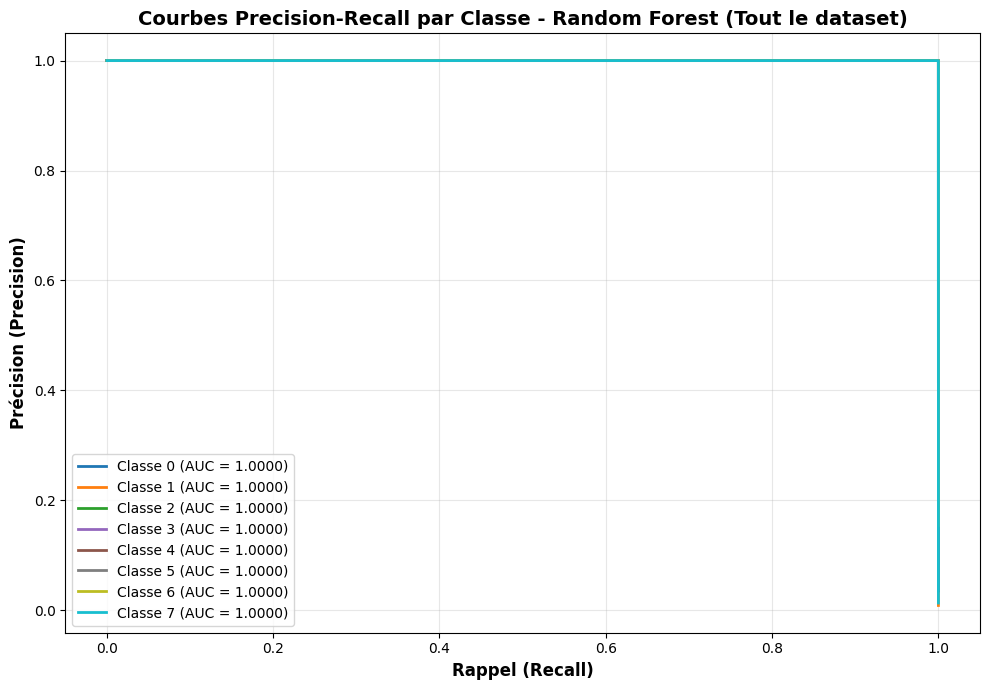


2/3 : GENERATION DE LA MATRICE DE CONFUSION


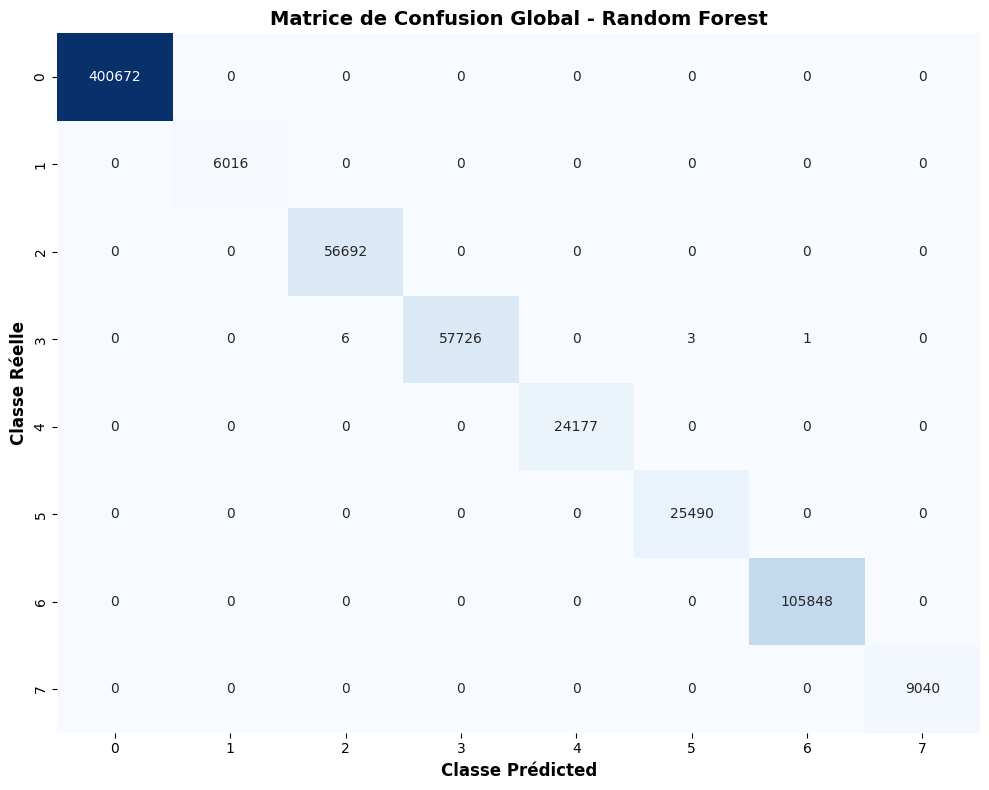


3/3 : TABLEAU DES MÉTRIQUES D'ÉVALUATION
              precision    recall  f1-score        support
0              1.000000  1.000000  1.000000  400672.000000
1              1.000000  1.000000  1.000000    6016.000000
2              0.999894  1.000000  0.999947   56692.000000
3              1.000000  0.999827  0.999913   57736.000000
4              1.000000  1.000000  1.000000   24177.000000
5              0.999882  1.000000  0.999941   25490.000000
6              0.999991  1.000000  0.999995  105848.000000
7              1.000000  1.000000  1.000000    9040.000000
accuracy       0.999985  0.999985  0.999985       0.999985
macro avg      0.999971  0.999978  0.999975  685671.000000
weighted avg   0.999985  0.999985  0.999985  685671.000000


In [ ]:
import os
import gc
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    auc
)

# ============================================
# 1. NETTOYAGE DE LA MÉMOIRE AVANT DÉMARRAGE
# ============================================
gc.collect()

print("="*60)
print("STATUT DE LA RAM AVANT ENTRAÎNEMENT")
print("="*60)
ram = psutil.virtual_memory()
print(f"  RAM totale : {ram.total / 1e9:.1f} GB")
print(f"  RAM utilisée : {ram.used / 1e9:.1f} GB")
print(f"  RAM disponible : {ram.available / 1e9:.1f} GB")
print(f"  RAM utilisée en % : {ram.percent}%")

# ============================================
# 2. UTILISATION DE TOUT LE DATASET
# ============================================
print("\n" + "="*60)
print("UTILISATION DE TOUT LE DATASET (685 671 lignes)")
print("="*60)

X_train_39 = X_scaled
y_train = y_complet

print(f"✅ X_train_39 : {X_train_39.shape[0]:,} lignes, {X_train_39.shape[1]} colonnes")
print(f"✅ y_train : {y_train.shape[0]:,} lignes")

# ============================================
# 3. PARAMÈTRES OPTIMISÉS POUR TOUT LE DATASET
# ============================================
rf_params = {
    'n_estimators': 100,
    'max_depth': 15,
    'min_samples_split': 20,
    'min_samples_leaf': 10,
    'max_features': 'sqrt',
    'criterion': 'entropy',
    'class_weight': 'balanced',
    'verbose': 1,
    'n_jobs': -1,
    'random_state': 42
}

print("\n" + "="*60)
print("PARAMÈTRES RANDOM FOREST (OPTIMISÉS POUR 685k LIGNES)")
print("="*60)
for key, val in rf_params.items():
    print(f"  {key}: {val}")

# ============================================
# 4. ENTRAÎNEMENT SUR TOUT LE DATASET (CROSS-VALIDATION)
# ============================================
y_true_all_rf, y_proba_all_rf = [], []

print("\n" + "="*60)
print("MODÈLE 1 : RANDOM FOREST (685 671 LIGNES)")
print("="*60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_39, y_train)):
    print(f"\n--- [Random Forest] Entraînement FOLD {fold+1}/5 ---")
    X_tr, y_tr = X_train_39.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_39.iloc[val_idx], y_train.iloc[val_idx]

    print(f"  Train : {X_tr.shape[0]:,} lignes | Validation : {X_va.shape[0]:,} lignes")

    gc.collect()

    ram = psutil.virtual_memory()
    print(f"  RAM avant fit : {ram.percent}% ({ram.used / 1e9:.1f} GB)")

    model_rf = RandomForestClassifier(**rf_params)
    model_rf.fit(X_tr, y_tr)

    ram = psutil.virtual_memory()
    print(f"  RAM après fit : {ram.percent}% ({ram.used / 1e9:.1f} GB)")

    y_proba = model_rf.predict_proba(X_va)
    y_pred = np.argmax(y_proba, axis=1)

    y_true_all_rf.append(y_va.values if hasattr(y_va, 'values') else y_va)
    y_proba_all_rf.append(y_proba)

    macro_f1 = f1_score(y_va, y_pred, average='macro', zero_division=0)
    print(f"🎯 >> FOLD {fold+1} TERMINÉ | Macro F1-Score : {macro_f1:.4f}")

    del model_rf
    gc.collect()

# ============================================
# 5. RÉSULTATS GLOBAUX
# ============================================
print("\n" + "="*60)
print("RÉSULTATS RANDOM FOREST (SYNTHÈSE FOLDS)")
print("="*60)
f1_scores = [f1_score(y_true, np.argmax(y_proba, axis=1), average='macro', zero_division=0)
             for y_true, y_proba in zip(y_true_all_rf, y_proba_all_rf)]

print(f"Macro F1 moyen : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"Meilleur fold : {np.max(f1_scores):.4f}")
print(f"Pire fold : {np.min(f1_scores):.4f}")

# Reconstitution de l'ensemble des prédictions hors-sac (Out-Of-Fold) pour l'évaluation globale
y_true_concat = np.concatenate(y_true_all_rf)
y_proba_concat = np.vstack(y_proba_all_rf)
y_pred_concat = np.argmax(y_proba_concat, axis=1)

# ============================================
# 6. FIGURES ET LIVRABLES REQUIS : RANDOM FOREST
# ============================================

# --- FIG 1 : COURBE PRECISION-RECALL PAR CLASSE ---
print("\n" + "="*60)
print("1/3 : GENERATION DE LA COURBE PRECISION-RECALL")
print("="*60)

def plot_pr_curves(y_true, y_proba, title="Random Forest"):
    n_classes = y_proba.shape[1]
    plt.figure(figsize=(10, 7))
    colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
    auc_scores = []

    for class_idx in range(n_classes):
        y_true_binary = (y_true == class_idx).astype(int)
        y_score = y_proba[:, class_idx]

        if np.sum(y_true_binary) == 0:
            continue

        precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
        pr_auc = auc(recall, precision)
        auc_scores.append(pr_auc)

        plt.plot(recall, precision, color=colors[class_idx % len(colors)],
                 linewidth=2, label=f'Classe {class_idx} (AUC = {pr_auc:.4f})')

    plt.xlabel('Rappel (Recall)', fontsize=12, fontweight='bold')
    plt.ylabel('Précision (Precision)', fontsize=12, fontweight='bold')
    plt.title(f'Courbes Precision-Recall par Classe - {title}', fontsize=14, fontweight='bold')
    plt.legend(loc='lower left', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_pr_curves(y_true_concat, y_proba_concat, title="Random Forest (Tout le dataset)")

# --- FIG 2 : MATRICE DE CONFUSION ---
print("\n" + "="*60)
print("2/3 : GENERATION DE LA MATRICE DE CONFUSION")
print("="*60)

cm = confusion_matrix(y_true_concat, y_pred_concat)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matrice de Confusion Global - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Classe Prédicted', fontsize=12, fontweight='bold')
plt.ylabel('Classe Réelle', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# --- FIG 3 : TABLEAU DE MÉTRIQUES COMPLET ---
print("\n" + "="*60)
print("3/3 : TABLEAU DES MÉTRIQUES D'ÉVALUATION")
print("="*60)

report_dict = classification_report(y_true_concat, y_pred_concat, output_dict=True, digits=4)
df_metrics = pd.DataFrame(report_dict).transpose()

# Visualisation sous forme de DataFrame nettoyé
print(df_metrics)

📁 Sauvegarde dans le dossier : /content/drive/MyDrive/projet-remote/resulta_final

✅ [1/3] Tableau de métriques sauvegardé : /content/drive/MyDrive/projet-remote/resulta_final/random_forest_metrics.csv


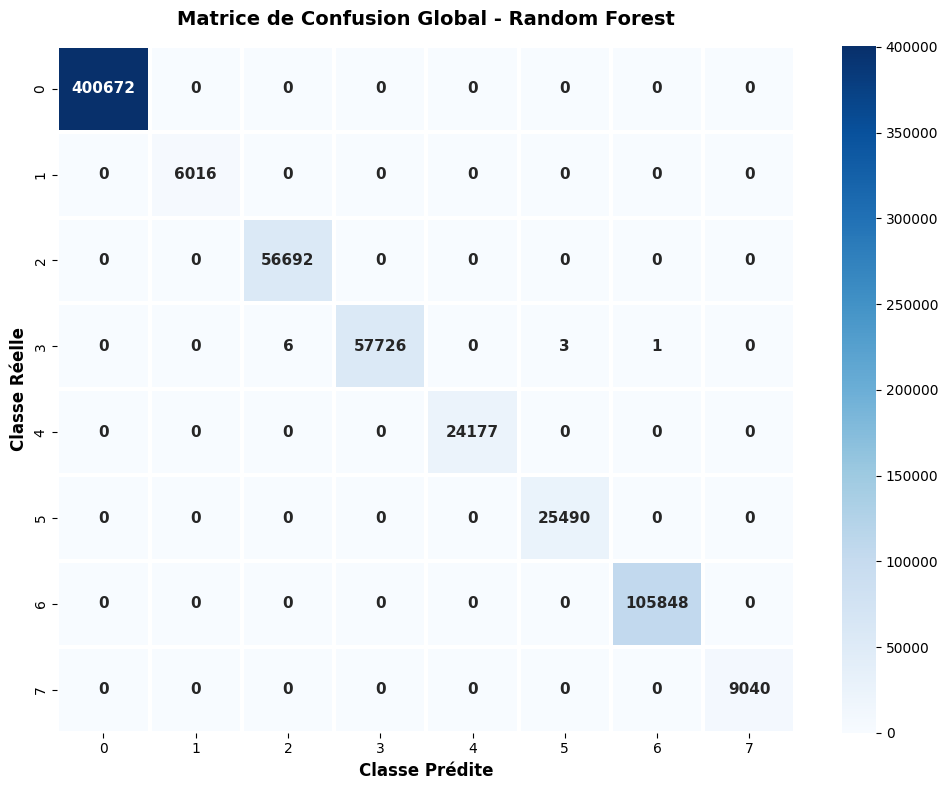

✅ [2/3] Image haute définition de la Matrice de Confusion sauvegardée : /content/drive/MyDrive/projet-remote/resulta_final/random_forest_confusion_matrix.png


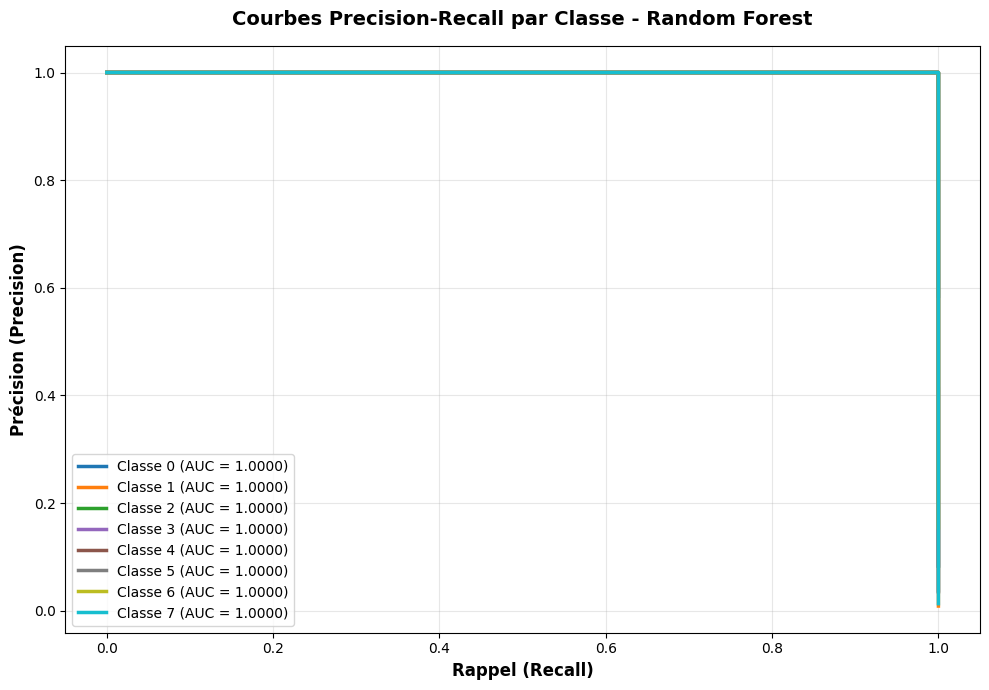

✅ [3/3] Courbe Precision-Recall sauvegardée : /content/drive/MyDrive/projet-remote/resulta_final/random_forest_precision_recall_curve.png

🎉 Sauvegarde terminée avec des graphiques nets et contrastés !


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.colors import LogNorm
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, auc

# ============================================
# 1. DOSSIER DE DESTINATION
# ============================================
SAVE_DIR = "/content/drive/MyDrive/projet-remote/resulta_final"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"📁 Sauvegarde dans le dossier : {SAVE_DIR}\n")

# Agglomération des résultats issus de tous les folds
y_true_concat = np.concatenate(y_true_all_rf)
y_proba_concat = np.vstack(y_proba_all_rf)
y_pred_concat = np.argmax(y_proba_concat, axis=1)

# ============================================
# 2. LIVRABLE 1 : TABLEAU DE MÉTRIQUES (CSV)
# ============================================
report_dict = classification_report(y_true_concat, y_pred_concat, output_dict=True, digits=4)
df_metrics = pd.DataFrame(report_dict).transpose()

csv_path = os.path.join(SAVE_DIR, "random_forest_metrics.csv")
df_metrics.to_csv(csv_path)
print(f"✅ [1/3] Tableau de métriques sauvegardé : {csv_path}")

# ============================================
# 3. LIVRABLE 2 : MATRICE DE CONFUSION HAUT CONTRASTE / COULEURS PURES (PNG)
# ============================================
cm = confusion_matrix(y_true_concat, y_pred_concat)

plt.figure(figsize=(10, 8))

# Utilisation d'une palette très contrastée ('Blues' ou 'viridis') avec lignes de séparation blanches
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',               # Astuce : Tu peux aussi remplacer 'Blues' par 'viridis' ou 'YlGnBu'
    cbar=True,                  # Affichage de la barre d'intensité
    linewidths=1.5,             # Bordures nettes entre les cases
    linecolor='white',          # Lignes séparatrices blanches pures
    annot_kws={"size": 11, "weight": "bold"} # Texte en gras et bien lisible
)

plt.title('Matrice de Confusion Global - Random Forest', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Classe Prédite', fontsize=12, fontweight='bold')
plt.ylabel('Classe Réelle', fontsize=12, fontweight='bold')
plt.tight_layout()

cm_path = os.path.join(SAVE_DIR, "random_forest_confusion_matrix.png")
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"✅ [2/3] Image haute définition de la Matrice de Confusion sauvegardée : {cm_path}")

# ============================================
# 4. LIVRABLE 3 : COURBE PRECISION-RECALL (PNG)
# ============================================
n_classes = y_proba_concat.shape[1]
plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))

for class_idx in range(n_classes):
    y_true_binary = (y_true_concat == class_idx).astype(int)
    y_score = y_proba_concat[:, class_idx]

    if np.sum(y_true_binary) == 0:
        continue

    precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, color=colors[class_idx % len(colors)],
             linewidth=2.5, label=f'Classe {class_idx} (AUC = {pr_auc:.4f})')

plt.xlabel('Rappel (Recall)', fontsize=12, fontweight='bold')
plt.ylabel('Précision (Precision)', fontsize=12, fontweight='bold')
plt.title('Courbes Precision-Recall par Classe - Random Forest', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

pr_path = os.path.join(SAVE_DIR, "random_forest_precision_recall_curve.png")
plt.savefig(pr_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"✅ [3/3] Courbe Precision-Recall sauvegardée : {pr_path}")

print("\n🎉 Sauvegarde terminée avec des graphiques nets et contrastés !")

📊 Nombre de classes détecté pour XGBoost : 8

=================== MODÈLE 2 : XGBOOST (39 VIF) ===================

--- [XGBoost (39 VIF)] Entraînement FOLD 1/5 ---
[0]	validation_0-mlogloss:1.16497
[50]	validation_0-mlogloss:0.06609
[100]	validation_0-mlogloss:0.00546
[150]	validation_0-mlogloss:0.00049
[200]	validation_0-mlogloss:0.00007
[250]	validation_0-mlogloss:0.00003
[299]	validation_0-mlogloss:0.00003
>> FOLD 1 TERMINÉ | Macro F1-Score : 1.0000

--- [XGBoost (39 VIF)] Entraînement FOLD 2/5 ---
[0]	validation_0-mlogloss:1.16547
[50]	validation_0-mlogloss:0.06609
[100]	validation_0-mlogloss:0.00543
[150]	validation_0-mlogloss:0.00048
[200]	validation_0-mlogloss:0.00006
[250]	validation_0-mlogloss:0.00002
[299]	validation_0-mlogloss:0.00002
>> FOLD 2 TERMINÉ | Macro F1-Score : 1.0000

--- [XGBoost (39 VIF)] Entraînement FOLD 3/5 ---
[0]	validation_0-mlogloss:1.16535
[50]	validation_0-mlogloss:0.06604
[100]	validation_0-mlogloss:0.00541
[150]	validation_0-mlogloss:0.00047
[200]	val

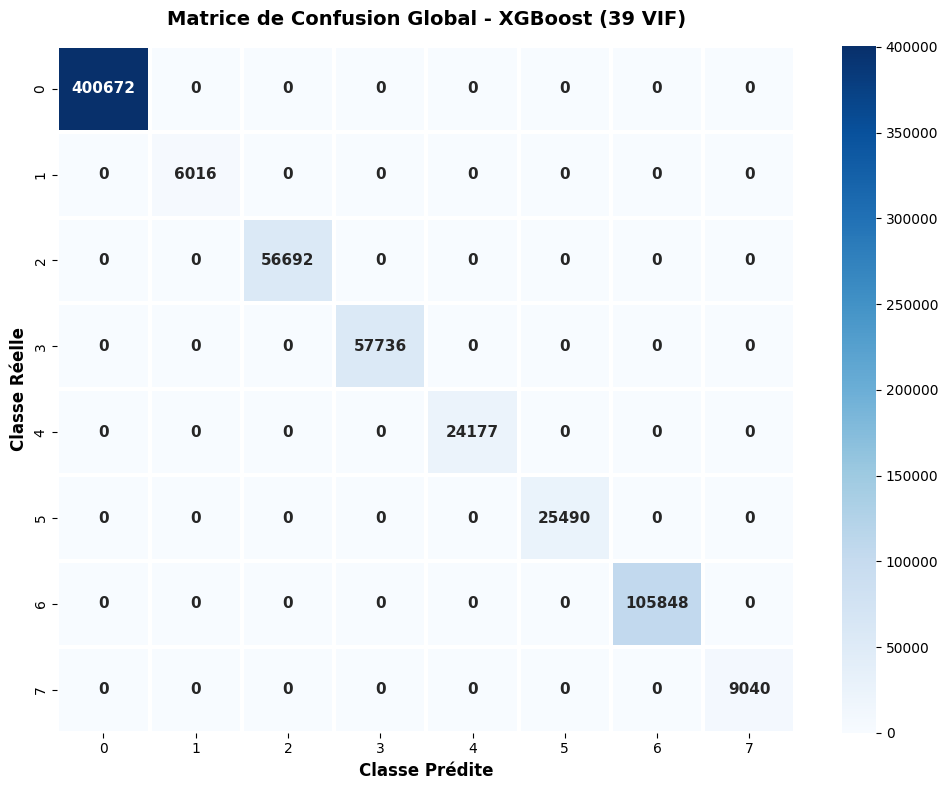

✅ Matrice de confusion enregistrée : /content/drive/MyDrive/projet-remote/resulta_final/xgb_39vif_confusion_matrix.png

📊 Enregistrement de la Courbe Precision-Recall - XGBoost (39 VIF)...


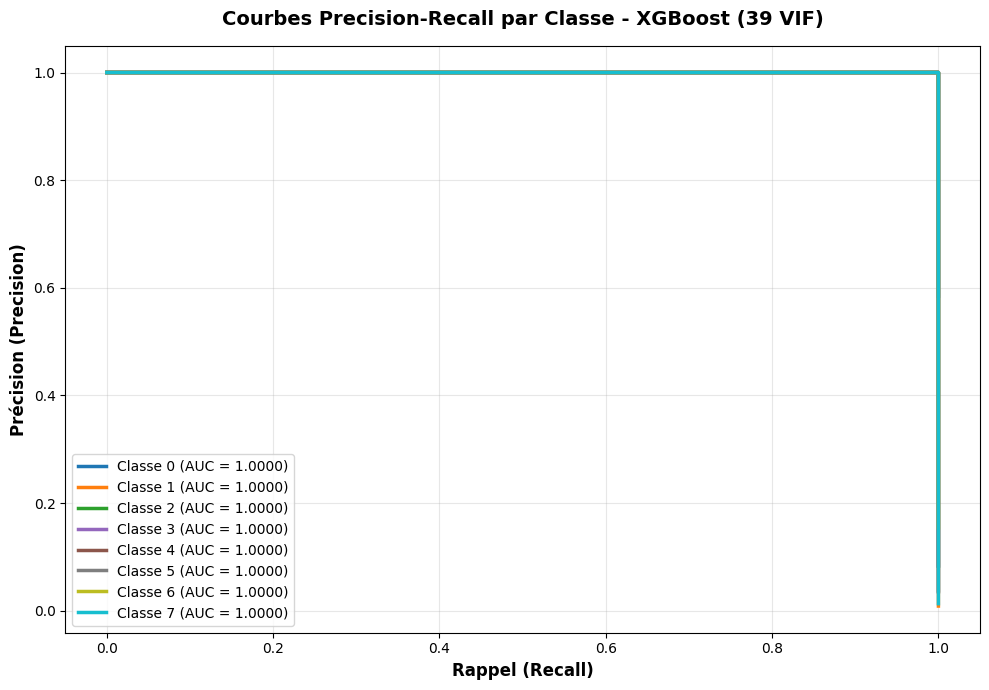

✅ Courbe Precision-Recall enregistrée : /content/drive/MyDrive/projet-remote/resulta_final/xgb_39vif_precision_recall_curve.png

🎉 Modèle 2 (XGBoost 39 VIF) terminé avec succès et sauvegardé !


In [ ]:
import os
import gc
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    auc
)

# ============================================
# 1. DOSSIER DE DESTINATION ET DÉTECTION CLASSES
# ============================================
SAVE_DIR = "/content/drive/MyDrive/projet-remote/resulta_final"
os.makedirs(SAVE_DIR, exist_ok=True)

# Détection automatique du nombre réel de classes pour éviter l'erreur de num_class fixed
num_classes = len(np.unique(y_train))
print(f"📊 Nombre de classes détecté pour XGBoost : {num_classes}")

xgb_params = {
    'n_estimators': 300,
    'learning_rate': 0.05,
    'max_depth': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'gamma': 0.1,
    'objective': 'multi:softprob',
    'num_class': num_classes,   # Nombre réel de classes dynamiques
    'tree_method': 'hist',
    'device': 'cuda',            # GPU activé pour accélération
    'random_state': 42
}

# ============================================
# 2. ENTRAÎNEMENT XGBOOST (39 VIF)
# ============================================
y_true_all_xgb, y_proba_all_xgb = [], []
print("\n=================== MODÈLE 2 : XGBOOST (39 VIF) ===================")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_39, y_train)):
    print(f"\n--- [XGBoost (39 VIF)] Entraînement FOLD {fold+1}/5 ---")

    # Conservation exacte des données Pandas/NumPy
    if isinstance(X_train_39, pd.DataFrame):
        X_tr, X_va = X_train_39.iloc[train_idx], X_train_39.iloc[val_idx]
    else:
        X_tr, X_va = X_train_39[train_idx], X_train_39[val_idx]

    if isinstance(y_train, (pd.Series, pd.DataFrame)):
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]
    else:
        y_tr, y_va = y_train[train_idx], y_train[val_idx]

    gc.collect()

    model_xgb = XGBClassifier(**xgb_params)
    model_xgb.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=50
    )

    y_proba = model_xgb.predict_proba(X_va)
    y_pred = np.argmax(y_proba, axis=1)

    y_true_all_xgb.append(y_va.values if hasattr(y_va, 'values') else y_va)
    y_proba_all_xgb.append(y_proba)

    macro_f1 = f1_score(y_va, y_pred, average='macro', zero_division=0)
    print(f">> FOLD {fold+1} TERMINÉ | Macro F1-Score : {macro_f1:.4f}")

    del model_xgb
    gc.collect()

# Agglomération globale Out-Of-Fold
y_true_concat_xgb = np.concatenate(y_true_all_xgb)
y_proba_concat_xgb = np.vstack(y_proba_all_xgb)
y_pred_concat_xgb = np.argmax(y_proba_concat_xgb, axis=1)

# ============================================
# 3. GENERATION DES FIGURE ET RÉSULTATS (39 VIF)
# ============================================

# --- LIVRABLE 1 : TABLEAU DE MÉTRIQUES ---
print("\n📊 Enregistrement du Tableau de Métriques - XGBoost (39 VIF)...")
report_dict = classification_report(y_true_concat_xgb, y_pred_concat_xgb, output_dict=True, digits=4)
df_metrics_xgb = pd.DataFrame(report_dict).transpose()
csv_path = os.path.join(SAVE_DIR, "xgb_39vif_metrics.csv")
df_metrics_xgb.to_csv(csv_path)
print(f"✅ Tableau enregistré : {csv_path}")

# --- LIVRABLE 2 : MATRICE DE CONFUSION COULEURS PURES ---
print("\n📊 Enregistrement de la Matrice de Confusion - XGBoost (39 VIF)...")
cm = confusion_matrix(y_true_concat_xgb, y_pred_concat_xgb)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    linewidths=1.5,
    linecolor='white',
    annot_kws={"size": 11, "weight": "bold"}
)
plt.title('Matrice de Confusion Global - XGBoost (39 VIF)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Classe Prédite', fontsize=12, fontweight='bold')
plt.ylabel('Classe Réelle', fontsize=12, fontweight='bold')
plt.tight_layout()

cm_path = os.path.join(SAVE_DIR, "xgb_39vif_confusion_matrix.png")
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"✅ Matrice de confusion enregistrée : {cm_path}")

# --- LIVRABLE 3 : COURBE PRECISION-RECALL PAR CLASSE ---
print("\n📊 Enregistrement de la Courbe Precision-Recall - XGBoost (39 VIF)...")
plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, num_classes))

for class_idx in range(num_classes):
    y_true_binary = (y_true_concat_xgb == class_idx).astype(int)
    y_score = y_proba_concat_xgb[:, class_idx]

    if np.sum(y_true_binary) == 0:
        continue

    precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, color=colors[class_idx % len(colors)],
             linewidth=2.5, label=f'Classe {class_idx} (AUC = {pr_auc:.4f})')

plt.xlabel('Rappel (Recall)', fontsize=12, fontweight='bold')
plt.ylabel('Précision (Precision)', fontsize=12, fontweight='bold')
plt.title('Courbes Precision-Recall par Classe - XGBoost (39 VIF)', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

pr_path = os.path.join(SAVE_DIR, "xgb_39vif_precision_recall_curve.png")
plt.savefig(pr_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"✅ Courbe Precision-Recall enregistrée : {pr_path}")

print("\n🎉 Modèle 2 (XGBoost 39 VIF) terminé avec succès et sauvegardé !")

📁 Sauvegarde des résultats XGBoost dans : /content/drive/MyDrive/projet-remote/resulta_final

✅ [1/3] Tableau de métriques sauvegardé : /content/drive/MyDrive/projet-remote/resulta_final/xgb_39vif_metrics.csv


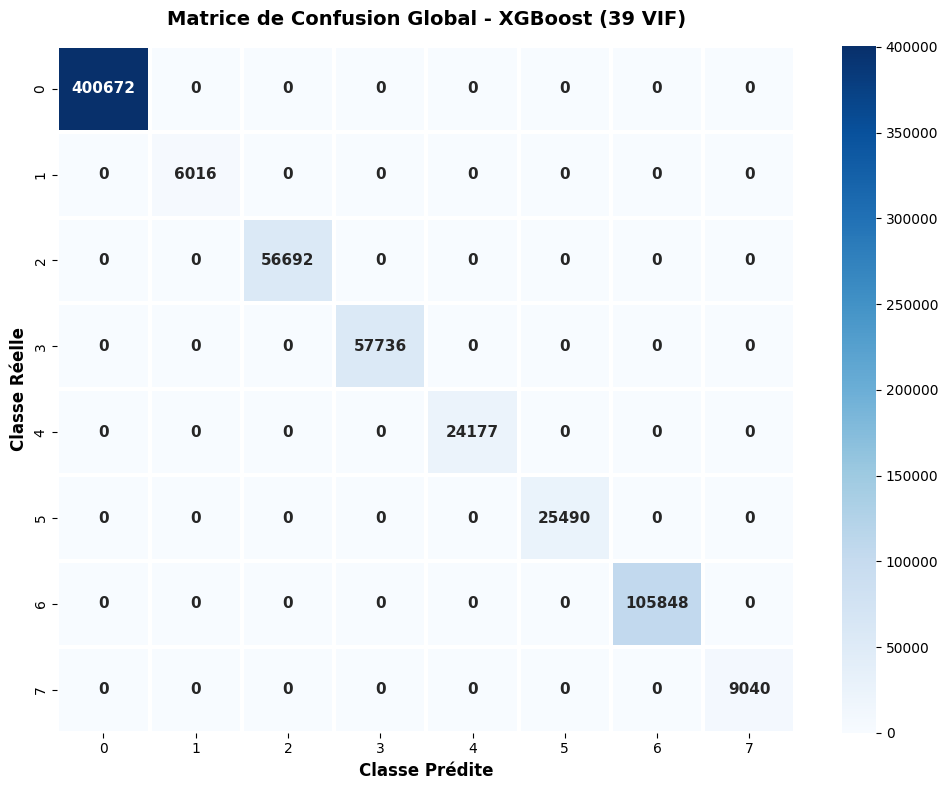

✅ [2/3] Matrice de confusion sauvegardée : /content/drive/MyDrive/projet-remote/resulta_final/xgb_39vif_confusion_matrix.png


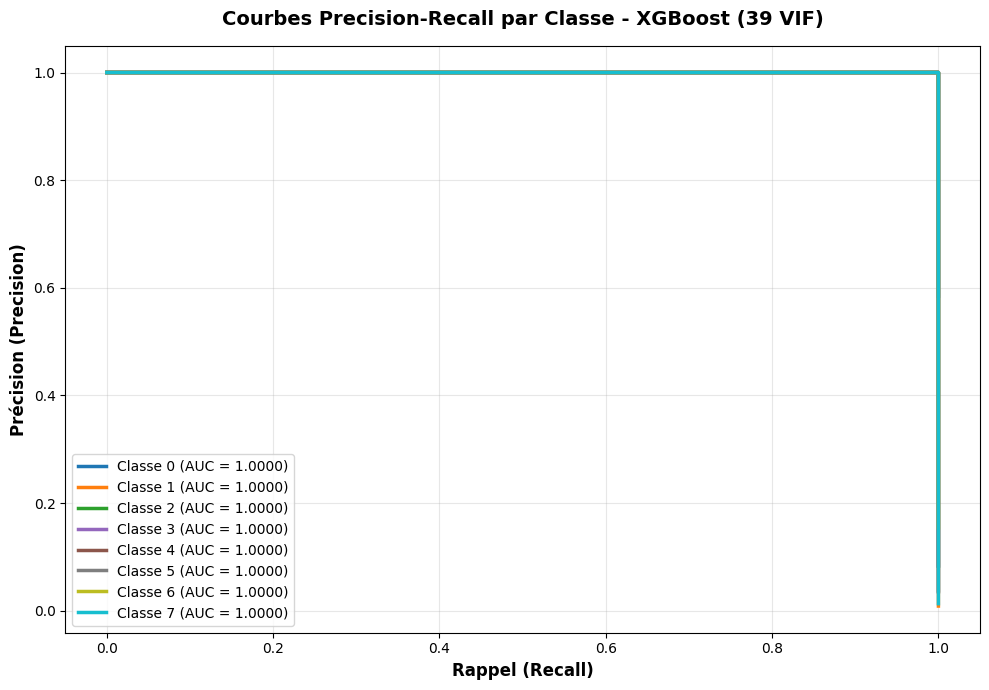

✅ [3/3] Courbe Precision-Recall sauvegardée : /content/drive/MyDrive/projet-remote/resulta_final/xgb_39vif_precision_recall_curve.png

🎉 Sauvegarde terminée avec succès !


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    auc
)

# ============================================
# 1. DOSSIER DE SAUVEGARDE & VÉRIFICATION
# ============================================
SAVE_DIR = "/content/drive/MyDrive/projet-remote/resulta_final"
os.makedirs(SAVE_DIR, exist_ok=True)

if 'y_true_all_xgb' not in locals() or 'y_proba_all_xgb' not in locals():
    raise NameError("❌ Les résultats 'y_true_all_xgb' ou 'y_proba_all_xgb' ne sont pas trouvés en mémoire. Veuiller d'abord exécuter l'entraînement XGBoost.")

print(f"📁 Sauvegarde des résultats XGBoost dans : {SAVE_DIR}\n")

# Reconstruction globale des données Out-Of-Fold
y_true_concat = np.concatenate(y_true_all_xgb)
y_proba_concat = np.vstack(y_proba_all_xgb)
y_pred_concat = np.argmax(y_proba_concat, axis=1)

num_classes = y_proba_concat.shape[1]

# ============================================
# 2. LIVRABLE 1 : TABLEAU DE MÉTRIQUES (CSV)
# ============================================
report_dict = classification_report(y_true_concat, y_pred_concat, output_dict=True, digits=4)
df_metrics = pd.DataFrame(report_dict).transpose()

csv_path = os.path.join(SAVE_DIR, "xgb_39vif_metrics.csv")
df_metrics.to_csv(csv_path)
print(f"✅ [1/3] Tableau de métriques sauvegardé : {csv_path}")

# ============================================
# 3. LIVRABLE 2 : MATRICE DE CONFUSION (PNG)
# ============================================
cm = confusion_matrix(y_true_concat, y_pred_concat)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    linewidths=1.5,
    linecolor='white',
    annot_kws={"size": 11, "weight": "bold"}
)
plt.title('Matrice de Confusion Global - XGBoost (39 VIF)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Classe Prédite', fontsize=12, fontweight='bold')
plt.ylabel('Classe Réelle', fontsize=12, fontweight='bold')
plt.tight_layout()

cm_path = os.path.join(SAVE_DIR, "xgb_39vif_confusion_matrix.png")
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"✅ [2/3] Matrice de confusion sauvegardée : {cm_path}")

# ============================================
# 4. LIVRABLE 3 : COURBE PRECISION-RECALL (PNG)
# ============================================
plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, num_classes))

for class_idx in range(num_classes):
    y_true_binary = (y_true_concat == class_idx).astype(int)
    y_score = y_proba_concat[:, class_idx]

    if np.sum(y_true_binary) == 0:
        continue

    precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, color=colors[class_idx % len(colors)],
             linewidth=2.5, label=f'Classe {class_idx} (AUC = {pr_auc:.4f})')

plt.xlabel('Rappel (Recall)', fontsize=12, fontweight='bold')
plt.ylabel('Précision (Precision)', fontsize=12, fontweight='bold')
plt.title('Courbes Precision-Recall par Classe - XGBoost (39 VIF)', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

pr_path = os.path.join(SAVE_DIR, "xgb_39vif_precision_recall_curve.png")
plt.savefig(pr_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"✅ [3/3] Courbe Precision-Recall sauvegardée : {pr_path}")

print("\n🎉 Sauvegarde terminée avec succès !")

## ÉTAPE 3 : Modèles Deep Learning (39 VIF + Focal Loss + Callbacks)
Modèle 3 : Multi-Layer Perceptron (39 Variables VIF)

In [ ]:
import tensorflow as tf

def focal_loss_multiclass(gamma=2.0, alpha=0.25):
    """
    Implémentation de la Focal Loss pour la classification multi-classes.
    Formule : FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    """
    def focal_loss_fixed(y_true, y_pred):
        # Clip des prédictions pour éviter les erreurs log(0) ou division par zéro
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        # Calcul de la cross-entropy
        cross_entropy = -y_true * tf.math.log(y_pred)

        # Calcul des poids focal : (1 - p_t)^gamma
        weight = alpha * tf.math.pow(1.0 - y_pred, gamma)

        # Application du terme focal à la perte
        loss = weight * cross_entropy

        # Somme sur les classes et moyenne sur le batch
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

    return focal_loss_fixed

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def obtenir_callbacks_dl():
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=1
        )
    ]


=================== MODÈLE 3 : MLP DENSE (90 variables, 8 classes) ===================

--- [MLP Dense (39 VIF)] Fold 1/5 ---
Epoch 1/50
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8328 - loss: 0.0700 - val_accuracy: 0.8703 - val_loss: 0.0474 - learning_rate: 0.0010
Epoch 2/50
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8886 - loss: 0.0345 - val_accuracy: 0.9076 - val_loss: 0.0271 - learning_rate: 0.0010
Epoch 3/50
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9069 - loss: 0.0272 - val_accuracy: 0.9329 - val_loss: 0.0227 - learning_rate: 0.0010
Epoch 4/50
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9195 - loss: 0.0239 - val_accuracy: 0.9299 - val_loss: 0.0229 - learning_rate: 0.0010
Epoch 5/50
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9269 - loss: 0.0225 - val_accuracy: 0.9445 - val_loss: 0.0179 - learning_rate: 0.0010
Epoch 6/50
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9323 - loss: 0.0206 - val_accurac

AttributeError: Line2D.set() got an unexpected keyword argument 'fontweight'

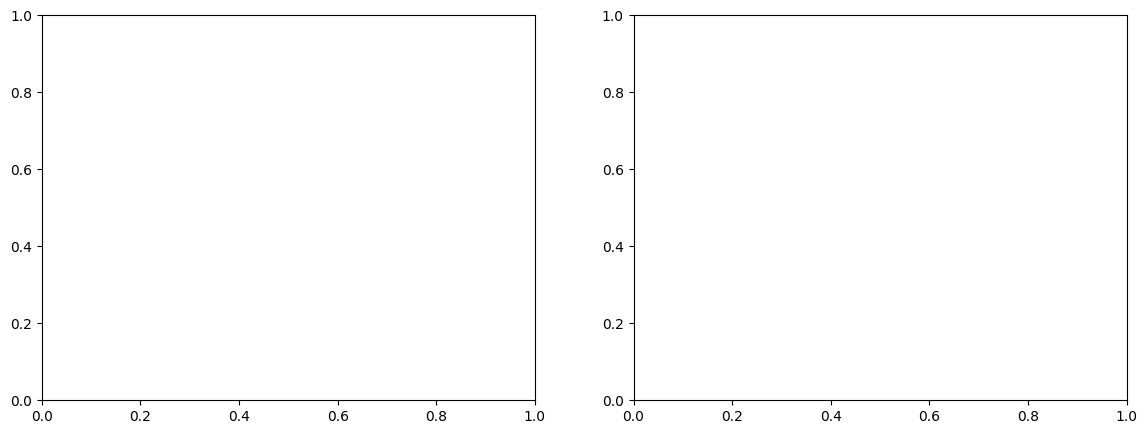

In [ ]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    auc
)

# ============================================
# 1. PRÉPARATION & PARAMÈTRES
# ============================================
SAVE_DIR = "/content/drive/MyDrive/projet-remote/resulta_final"
os.makedirs(SAVE_DIR, exist_ok=True)

input_dim = X_train_39.shape[1]
num_classes = int(np.max(y_train)) + 1

# Fonction de construction du MLP
def construire_mlp_focal(input_dim, num_classes):
    model = Sequential([
        Dense(512, activation="swish", input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(256, activation="swish"),
        BatchNormalization(),
        Dropout(0.3),

        Dense(128, activation="swish"),
        BatchNormalization(),
        Dropout(0.2),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=1e-3,
            weight_decay=1e-4
        ),
        loss=focal_loss_multiclass(gamma=2.0, alpha=0.25),
        metrics=["accuracy"]
    )
    return model

# ============================================
# 2. ENTRAÎNEMENT K-FOLD DU MLP DENSE
# ============================================
y_true_all_mlp, y_proba_all_mlp = [], []
histories_mlp = []

print(f"\n=================== MODÈLE 3 : MLP DENSE ({input_dim} variables, {num_classes} classes) ===================")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_39, y_train)):
    print(f"\n--- [MLP Dense (39 VIF)] Fold {fold + 1}/5 ---")

    # Découpage Pandas / NumPy conservé à l'identique
    if isinstance(X_train_39, pd.DataFrame):
        X_tr, X_va = X_train_39.iloc[train_idx], X_train_39.iloc[val_idx]
    else:
        X_tr, X_va = X_train_39[train_idx], X_train_39[val_idx]

    if isinstance(y_train, (pd.Series, pd.DataFrame)):
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]
    else:
        y_tr, y_va = y_train[train_idx], y_train[val_idx]

    y_tr_cat = to_categorical(y_tr, num_classes=num_classes).astype("float32")
    y_va_cat = to_categorical(y_va, num_classes=num_classes).astype("float32")

    gc.collect()
    tf.keras.backend.clear_session()

    model_mlp = construire_mlp_focal(input_dim=input_dim, num_classes=num_classes)

    history = model_mlp.fit(
        X_tr,
        y_tr_cat,
        validation_data=(X_va, y_va_cat),
        epochs=50,
        batch_size=512,
        callbacks=obtenir_callbacks_dl(),
        verbose=1
    )

    histories_mlp.append(history.history)

    y_proba = model_mlp.predict(X_va, verbose=1)
    y_pred = np.argmax(y_proba, axis=1)

    y_true_all_mlp.append(y_va.values if hasattr(y_va, 'values') else y_va)
    y_proba_all_mlp.append(y_proba)

    macro_f1 = f1_score(y_va, y_pred, average="macro", zero_division=0)
    print(f"🎯 Fold {fold + 1} terminé | Macro F1 : {macro_f1:.4f}")

    del model_mlp
    gc.collect()

# Reconstruction globale Out-Of-Fold
y_true_concat_mlp = np.concatenate(y_true_all_mlp)
y_proba_concat_mlp = np.vstack(y_proba_all_mlp)
y_pred_concat_mlp = np.argmax(y_proba_concat_mlp, axis=1)

# ============================================
# 3. GÉNÉRATION ET SAUVEGARDE DES 4 LIVRABLES
# ============================================

# --- LIVRABLE 1 : COURBES D'APPRENTISSAGE (LOSS & ACCURACY) ---
print("\n📊 Enregistrement des Courbes d'Apprentissage (MLP)...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calcul de la moyenne des pertes et précisions sur le dernier fold (ou moyenne des folds)
last_hist = histories_mlp[-1]
epochs = range(1, len(last_hist['loss']) + 1)

axes[0].plot(epochs, last_hist['loss'], label='Loss Entraînement', color='blue', fontweight='bold')
axes[0].plot(epochs, last_hist['val_loss'], label='Loss Validation', color='orange', fontweight='bold')
axes[0].set_title('Courbe Loss / Val_Loss - MLP Dense (39 VIF)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Époques')
axes[0].set_ylabel('Perte (Loss)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, last_hist['accuracy'], label='Accuracy Entraînement', color='blue', fontweight='bold')
axes[1].plot(epochs, last_hist['val_accuracy'], label='Accuracy Validation', color='orange', fontweight='bold')
axes[1].set_title('Courbe Accuracy / Val_Accuracy - MLP Dense (39 VIF)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Époques')
axes[1].set_ylabel('Précision (Accuracy)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
learning_curve_path = os.path.join(SAVE_DIR, "mlp_39vif_learning_curves.png")
plt.savefig(learning_curve_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"✅ Courbes d'apprentissage enregistrées : {learning_curve_path}")

# --- LIVRABLE 2 : TABLEAU DE MÉTRIQUES (CSV) ---
print("\n📊 Enregistrement du Tableau de Métriques (MLP)...")
report_dict = classification_report(y_true_concat_mlp, y_pred_concat_mlp, output_dict=True, digits=4)
df_metrics_mlp = pd.DataFrame(report_dict).transpose()
csv_path = os.path.join(SAVE_DIR, "mlp_39vif_metrics.csv")
df_metrics_mlp.to_csv(csv_path)
print(f"✅ Tableau enregistré : {csv_path}")

# --- LIVRABLE 3 : MATRICE DE CONFUSION COULEURS PURES ---
print("\n📊 Enregistrement de la Matrice de Confusion (MLP)...")
cm = confusion_matrix(y_true_concat_mlp, y_pred_concat_mlp)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    linewidths=1.5,
    linecolor='white',
    annot_kws={"size": 11, "weight": "bold"}
)
plt.title('Matrice de Confusion Global - MLP Dense (39 VIF)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Classe Prédite', fontsize=12, fontweight='bold')
plt.ylabel('Classe Réelle', fontsize=12, fontweight='bold')
plt.tight_layout()

cm_path = os.path.join(SAVE_DIR, "mlp_39vif_confusion_matrix.png")
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"✅ Matrice de confusion enregistrée : {cm_path}")

# --- LIVRABLE 4 : COURBE PRECISION-RECALL PAR CLASSE ---
print("\n📊 Enregistrement de la Courbe Precision-Recall (MLP)...")
plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, num_classes))

for class_idx in range(num_classes):
    y_true_binary = (y_true_concat_mlp == class_idx).astype(int)
    y_score = y_proba_concat_mlp[:, class_idx]

    if np.sum(y_true_binary) == 0:
        continue

    precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, color=colors[class_idx % len(colors)],
             linewidth=2.5, label=f'Classe {class_idx} (AUC = {pr_auc:.4f})')

plt.xlabel('Rappel (Recall)', fontsize=12, fontweight='bold')
plt.ylabel('Précision (Precision)', fontsize=12, fontweight='bold')
plt.title('Courbes Precision-Recall par Classe - MLP Dense (39 VIF)', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

pr_path = os.path.join(SAVE_DIR, "mlp_39vif_precision_recall_curve.png")
plt.savefig(pr_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"✅ Courbe Precision-Recall enregistrée : {pr_path}")

print("\n🎉 Modèle 3 (MLP Dense 39 VIF) entraîné et tous les résultats sauvegardés !")

📊 [1/4] Enregistrement des Courbes d'Apprentissage...


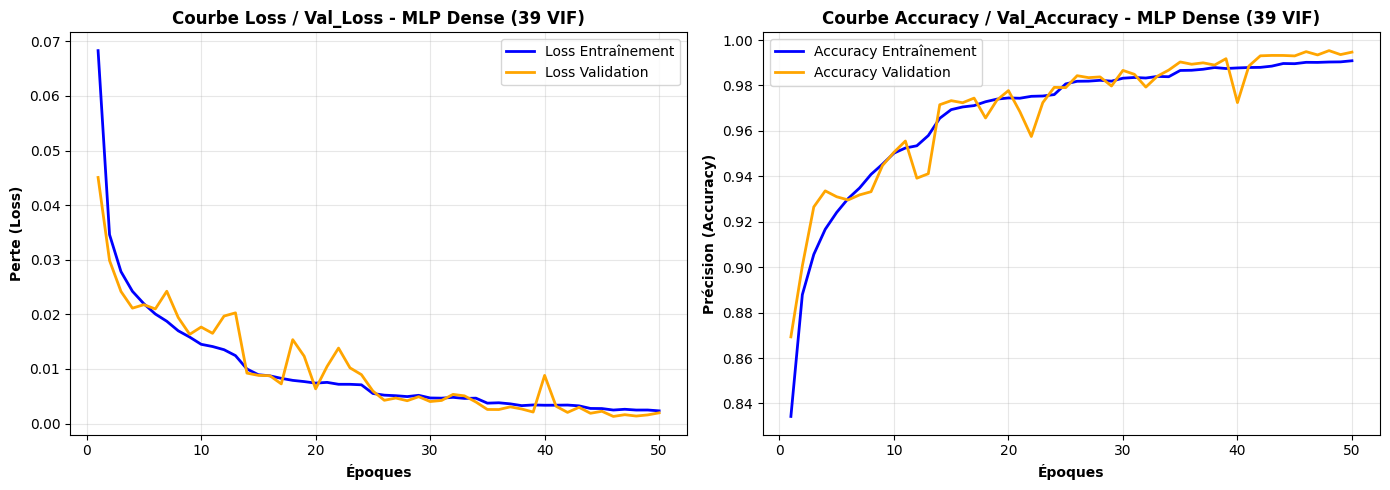

📊 [2/4] Enregistrement du Tableau de Métriques...
📊 [3/4] Enregistrement de la Matrice de Confusion...


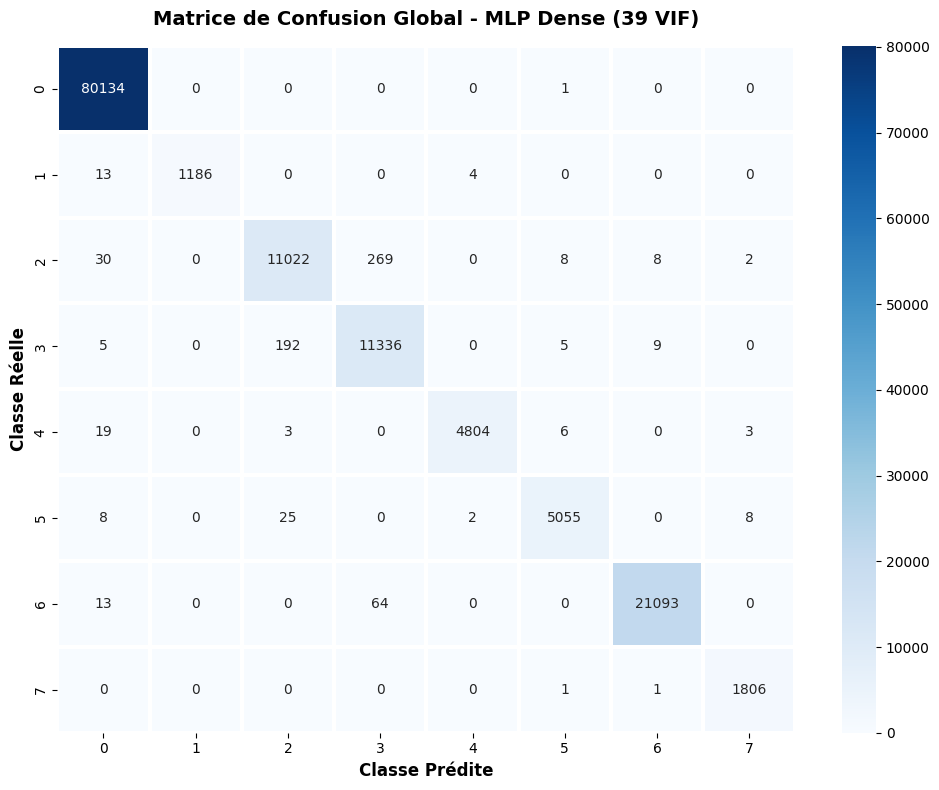

📊 [4/4] Enregistrement de la Courbe Precision-Recall...


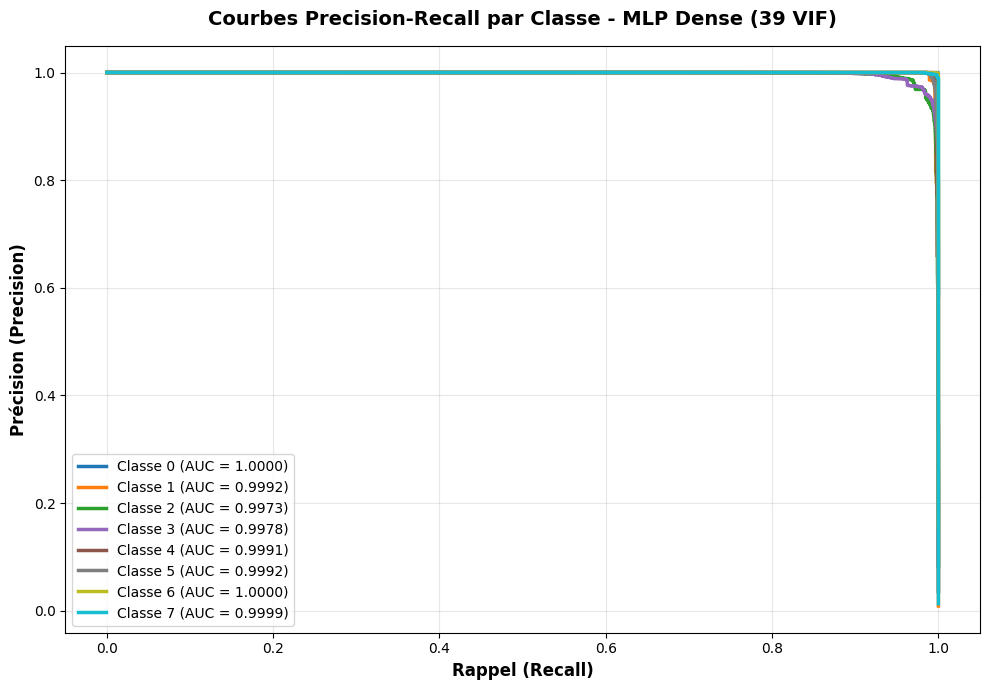


🎉 Sauvegarde terminée avec succès !


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    auc
)

# ============================================
# 1. VÉRIFICATION ET DOSSIER
# ============================================
SAVE_DIR = "/content/drive/MyDrive/projet-remote/resulta_final"
os.makedirs(SAVE_DIR, exist_ok=True)

y_true_concat_mlp = np.concatenate(y_true_all_mlp)
y_proba_concat_mlp = np.vstack(y_proba_all_mlp)
y_pred_concat_mlp = np.argmax(y_proba_concat_mlp, axis=1)
num_classes = y_proba_concat_mlp.shape[1]

# ============================================
# 2. COURBES D'APPRENTISSAGE (CORRIGÉ)
# ============================================
if 'histories_mlp' in locals() and len(histories_mlp) > 0:
    print("📊 [1/4] Enregistrement des Courbes d'Apprentissage...")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    last_hist = histories_mlp[-1]
    epochs = range(1, len(last_hist['loss']) + 1)

    # Suppression de fontweight='bold' dans .plot()
    axes[0].plot(epochs, last_hist['loss'], label='Loss Entraînement', color='blue', linewidth=2)
    axes[0].plot(epochs, last_hist['val_loss'], label='Loss Validation', color='orange', linewidth=2)
    axes[0].set_title('Courbe Loss / Val_Loss - MLP Dense (39 VIF)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Époques', fontweight='bold')
    axes[0].set_ylabel('Perte (Loss)', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, last_hist['accuracy'], label='Accuracy Entraînement', color='blue', linewidth=2)
    axes[1].plot(epochs, last_hist['val_accuracy'], label='Accuracy Validation', color='orange', linewidth=2)
    axes[1].set_title('Courbe Accuracy / Val_Accuracy - MLP Dense (39 VIF)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Époques', fontweight='bold')
    axes[1].set_ylabel('Précision (Accuracy)', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "mlp_39vif_learning_curves.png"), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# ============================================
# 3. TABLEAU DE MÉTRIQUES (CSV)
# ============================================
print("📊 [2/4] Enregistrement du Tableau de Métriques...")
report_dict = classification_report(y_true_concat_mlp, y_pred_concat_mlp, output_dict=True, digits=4)
df_metrics_mlp = pd.DataFrame(report_dict).transpose()
df_metrics_mlp.to_csv(os.path.join(SAVE_DIR, "mlp_39vif_metrics.csv"))

# ============================================
# 4. MATRICE DE CONFUSION
# ============================================
print("📊 [3/4] Enregistrement de la Matrice de Confusion...")
cm = confusion_matrix(y_true_concat_mlp, y_pred_concat_mlp)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, linewidths=1.5, linecolor='white')
plt.title('Matrice de Confusion Global - MLP Dense (39 VIF)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Classe Prédite', fontsize=12, fontweight='bold')
plt.ylabel('Classe Réelle', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "mlp_39vif_confusion_matrix.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ============================================
# 5. COURBE PRECISION-RECALL
# ============================================
print("📊 [4/4] Enregistrement de la Courbe Precision-Recall...")
plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, num_classes))

for class_idx in range(num_classes):
    y_true_binary = (y_true_concat_mlp == class_idx).astype(int)
    y_score = y_proba_concat_mlp[:, class_idx]

    if np.sum(y_true_binary) == 0:
        continue

    precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, color=colors[class_idx % len(colors)],
             linewidth=2.5, label=f'Classe {class_idx} (AUC = {pr_auc:.4f})')

plt.xlabel('Rappel (Recall)', fontsize=12, fontweight='bold')
plt.ylabel('Précision (Precision)', fontsize=12, fontweight='bold')
plt.title('Courbes Precision-Recall par Classe - MLP Dense (39 VIF)', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "mlp_39vif_precision_recall_curve.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\n🎉 Sauvegarde terminée avec succès !")

📊 [1/4] Enregistrement des Courbes d'Apprentissage...


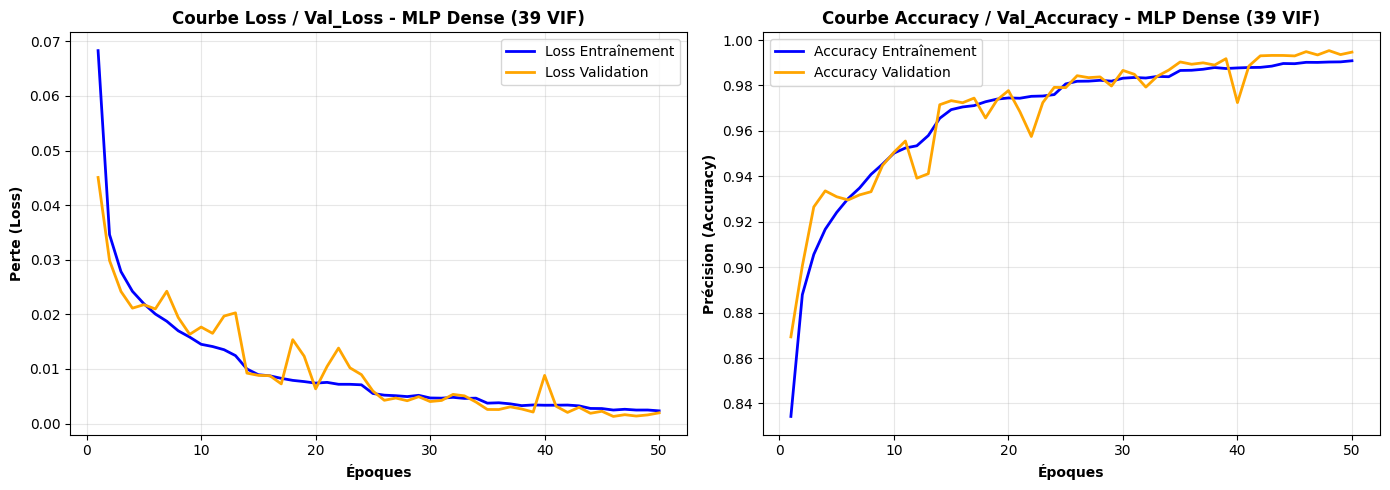

📊 [2/4] Enregistrement du Tableau de Métriques...
📊 [3/4] Enregistrement de la Matrice de Confusion...


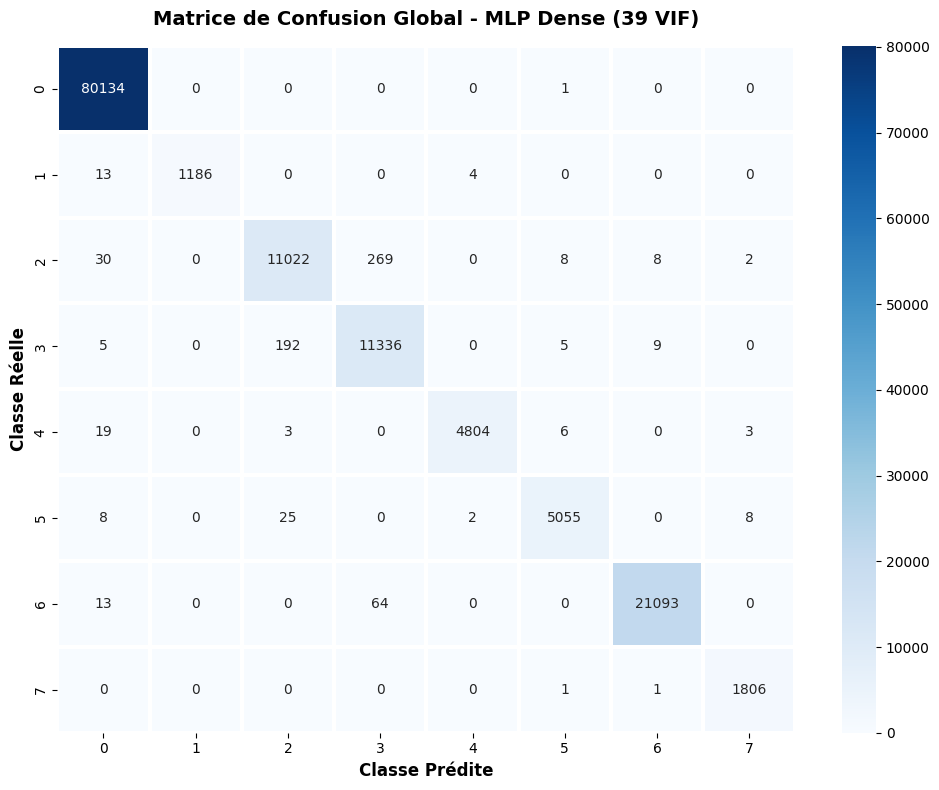

📊 [4/4] Enregistrement de la Courbe Precision-Recall...


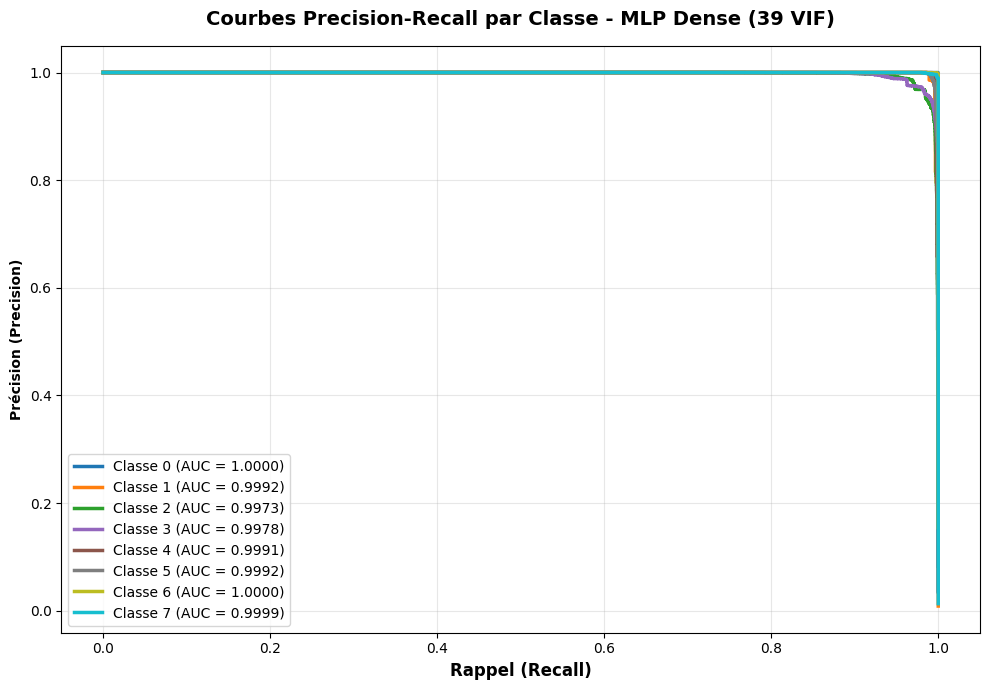


🎉 Sauvegarde du Modèle 3 (MLP) terminée avec succès !


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    auc
)

# ============================================
# EXPORT IMMÉDIAT DES RÉSULTATS DU MLP
# ============================================
SAVE_DIR = "/content/drive/MyDrive/projet-remote/resulta_final"
os.makedirs(SAVE_DIR, exist_ok=True)

y_true_concat_mlp = np.concatenate(y_true_all_mlp)
y_proba_concat_mlp = np.vstack(y_proba_all_mlp)
y_pred_concat_mlp = np.argmax(y_proba_concat_mlp, axis=1)
num_classes = y_proba_concat_mlp.shape[1]

# 1. COURBES D'APPRENTISSAGE (SANS FONTWEIGHT SUR LES LIGNES)
if 'histories_mlp' in locals() and len(histories_mlp) > 0:
    print("📊 [1/4] Enregistrement des Courbes d'Apprentissage...")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    last_hist = histories_mlp[-1]
    epochs = range(1, len(last_hist['loss']) + 1)

    axes[0].plot(epochs, last_hist['loss'], label='Loss Entraînement', color='blue', linewidth=2)
    axes[0].plot(epochs, last_hist['val_loss'], label='Loss Validation', color='orange', linewidth=2)
    axes[0].set_title('Courbe Loss / Val_Loss - MLP Dense (39 VIF)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Époques', fontweight='bold')
    axes[0].set_ylabel('Perte (Loss)', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, last_hist['accuracy'], label='Accuracy Entraînement', color='blue', linewidth=2)
    axes[1].plot(epochs, last_hist['val_accuracy'], label='Accuracy Validation', color='orange', linewidth=2)
    axes[1].set_title('Courbe Accuracy / Val_Accuracy - MLP Dense (39 VIF)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Époques', fontweight='bold')
    axes[1].set_ylabel('Précision (Accuracy)', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "mlp_39vif_learning_curves.png"), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# 2. TABLEAU DE MÉTRIQUES (CSV)
print("📊 [2/4] Enregistrement du Tableau de Métriques...")
report_dict = classification_report(y_true_concat_mlp, y_pred_concat_mlp, output_dict=True, digits=4)
df_metrics_mlp = pd.DataFrame(report_dict).transpose()
df_metrics_mlp.to_csv(os.path.join(SAVE_DIR, "mlp_39vif_metrics.csv"))

# 3. MATRICE DE CONFUSION
print("📊 [3/4] Enregistrement de la Matrice de Confusion...")
cm = confusion_matrix(y_true_concat_mlp, y_pred_concat_mlp)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, linewidths=1.5, linecolor='white')
plt.title('Matrice de Confusion Global - MLP Dense (39 VIF)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Classe Prédite', fontsize=12, fontweight='bold')
plt.ylabel('Classe Réelle', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "mlp_39vif_confusion_matrix.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# 4. COURBE PRECISION-RECALL
print("📊 [4/4] Enregistrement de la Courbe Precision-Recall...")
plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, num_classes))

for class_idx in range(num_classes):
    y_true_binary = (y_true_concat_mlp == class_idx).astype(int)
    y_score = y_proba_concat_mlp[:, class_idx]

    if np.sum(y_true_binary) == 0:
        continue

    precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, color=colors[class_idx % len(colors)],
             linewidth=2.5, label=f'Classe {class_idx} (AUC = {pr_auc:.4f})')

plt.xlabel('Rappel (Recall)', fontsize=12, fontweight='bold')
plt.ylabel('Précision (Precision)', fontweight='bold')
plt.title('Courbes Precision-Recall par Classe - MLP Dense (39 VIF)', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "mlp_39vif_precision_recall_curve.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\n🎉 Sauvegarde du Modèle 3 (MLP) terminée avec succès !")

Modèle 4 : Convolutional Neural Network 1D (39 Variables VIF)


=================== MODÈLE 4 : CNN-1D (90 variables, 8 classes) ===================

--- [CNN-1D (39 VIF)] En cours : Fold 1/5 ... ---

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 2.
🎯 Fold 1 terminé avec succès | Macro F1 : 0.6529

--- [CNN-1D (39 VIF)] En cours : Fold 2/5 ... ---

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 21: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 23: early stopping
Restoring model weights from the end of the best epoch: 15.
🎯 Fold 2 terminé avec succès | Macro F1 : 0.9594

--- [CNN-1D (39 VIF)] En cours : Fold 3/5 ... ---

Epoch 6: ReduceLROnPlateau re

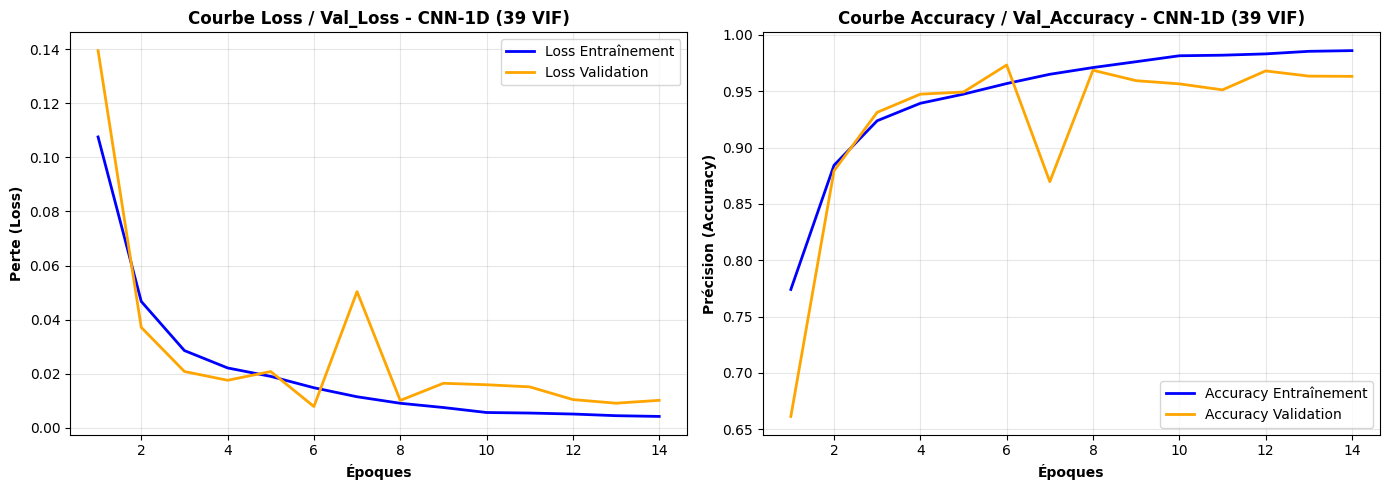

📊 Enregistrement du Tableau de Métriques (CNN-1D)...
📊 Enregistrement de la Matrice de Confusion (CNN-1D)...


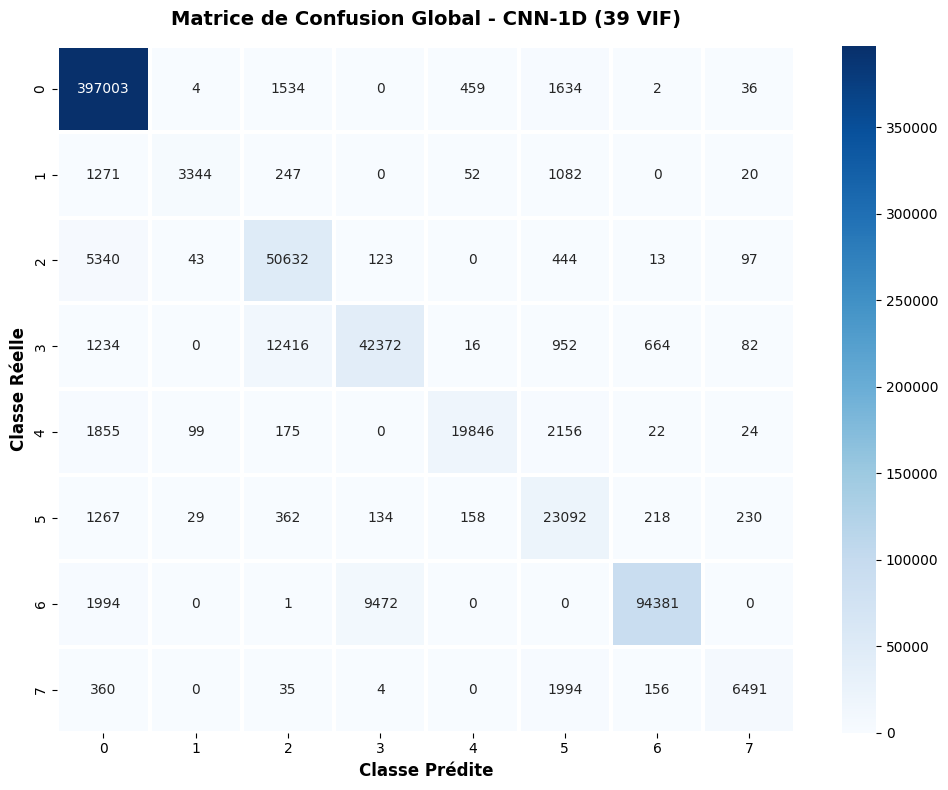

📊 Enregistrement de la Courbe Precision-Recall (CNN-1D)...


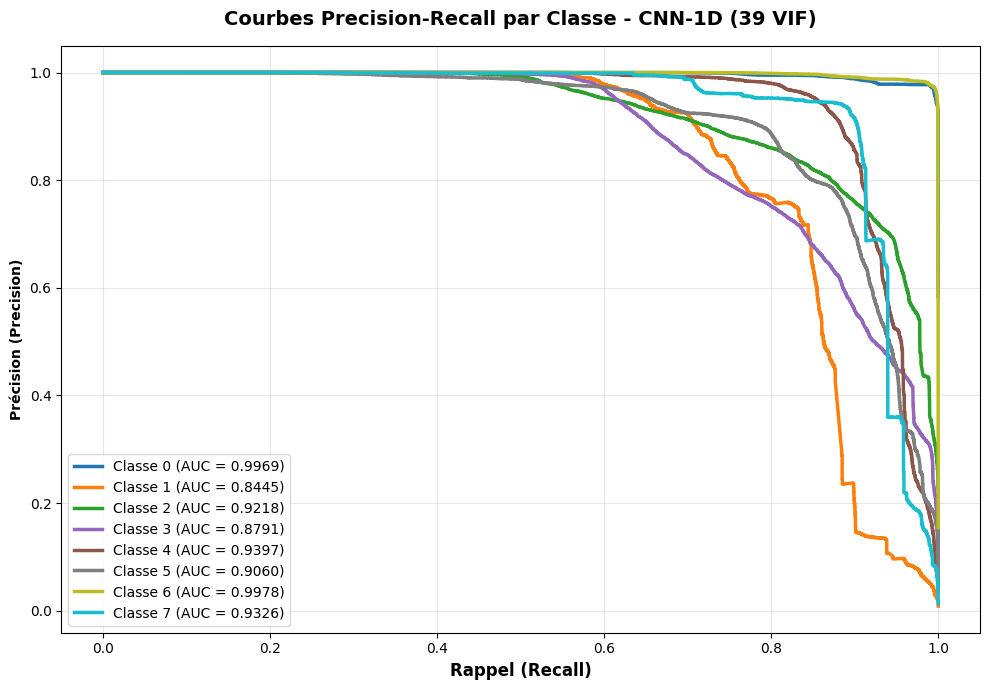


🎉 Modèle 4 (CNN-1D 39 VIF) entraîné et tous les résultats sauvegardés avec succès !


In [ ]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow.keras.backend as K

from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    auc
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Reshape, Conv1D, BatchNormalization,
    Dropout, GlobalMaxPooling1D, Dense
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ============================================
# 1. PRÉPARATION & DOSSIER DE SAUVEGARDE
# ============================================
SAVE_DIR = "/content/drive/MyDrive/projet-remote/resulta_final"
os.makedirs(SAVE_DIR, exist_ok=True)

def focal_loss_multiclass(gamma=2.0, alpha=0.25):
    def focal_loss(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1.0 - y_pred, gamma)
        return K.sum(weight * cross_entropy, axis=-1)
    return focal_loss

def obtenir_callbacks_dl():
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        )
    ]

# Configuration dynamique conservant vos variables exactes
input_dim = X_train_39.shape[1]
num_classes = int(np.max(y_train)) + 1

print(f"\n=================== MODÈLE 4 : CNN-1D ({input_dim} variables, {num_classes} classes) ===================")

def construire_cnn1d_focal(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),
        Reshape((input_dim, 1)),

        Conv1D(64, kernel_size=5, activation="relu", padding="same"),
        BatchNormalization(),
        Dropout(0.2),

        Conv1D(128, kernel_size=3, activation="relu", padding="same"),
        BatchNormalization(),
        Dropout(0.3),

        GlobalMaxPooling1D(),
        Dense(256, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=focal_loss_multiclass(),
        metrics=["accuracy"]
    )
    return model

# ============================================
# 2. ENTRAÎNEMENT K-FOLD
# ============================================
y_true_all_cnn = []
y_proba_all_cnn = []
histories_cnn = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_39, y_train), start=1):
    print(f"\n--- [CNN-1D (39 VIF)] En cours : Fold {fold}/5 ... ---")

    if isinstance(X_train_39, pd.DataFrame):
        X_tr, X_va = X_train_39.iloc[train_idx], X_train_39.iloc[val_idx]
    else:
        X_tr, X_va = X_train_39[train_idx], X_train_39[val_idx]

    if isinstance(y_train, (pd.Series, pd.DataFrame)):
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]
    else:
        y_tr, y_va = y_train[train_idx], y_train[val_idx]

    y_tr_cat = to_categorical(y_tr, num_classes=num_classes).astype("float32")
    y_va_cat = to_categorical(y_va, num_classes=num_classes).astype("float32")

    gc.collect()
    tf.keras.backend.clear_session()

    model_cnn = construire_cnn1d_focal(input_dim, num_classes)

    history = model_cnn.fit(
        X_tr,
        y_tr_cat,
        validation_data=(X_va, y_va_cat),
        epochs=50,
        batch_size=512,
        callbacks=obtenir_callbacks_dl(),
        verbose=0
    )

    histories_cnn.append(history.history)

    y_proba = model_cnn.predict(X_va, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)

    y_true_all_cnn.append(y_va.values if hasattr(y_va, 'values') else y_va)
    y_proba_all_cnn.append(y_proba)

    macro_f1 = f1_score(y_va, y_pred, average="macro", zero_division=0)
    print(f"🎯 Fold {fold} terminé avec succès | Macro F1 : {macro_f1:.4f}")

    del model_cnn
    gc.collect()

# Reconstruction globale Out-Of-Fold
y_true_concat_cnn = np.concatenate(y_true_all_cnn)
y_proba_concat_cnn = np.vstack(y_proba_all_cnn)
y_pred_concat_cnn = np.argmax(y_proba_concat_cnn, axis=1)

# ============================================
# 3. GÉNÉRATION ET SAUVEGARDE DES 4 LIVRABLES
# ============================================

# --- LIVRABLE 1 : COURBES D'APPRENTISSAGE ---
print("\n📊 Enregistrement des Courbes d'Apprentissage (CNN-1D)...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
last_hist = histories_cnn[-1]
epochs = range(1, len(last_hist['loss']) + 1)

axes[0].plot(epochs, last_hist['loss'], label='Loss Entraînement', color='blue', linewidth=2)
axes[0].plot(epochs, last_hist['val_loss'], label='Loss Validation', color='orange', linewidth=2)
axes[0].set_title('Courbe Loss / Val_Loss - CNN-1D (39 VIF)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Époques', fontweight='bold')
axes[0].set_ylabel('Perte (Loss)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, last_hist['accuracy'], label='Accuracy Entraînement', color='blue', linewidth=2)
axes[1].plot(epochs, last_hist['val_accuracy'], label='Accuracy Validation', color='orange', linewidth=2)
axes[1].set_title('Courbe Accuracy / Val_Accuracy - CNN-1D (39 VIF)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Époques', fontweight='bold')
axes[1].set_ylabel('Précision (Accuracy)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "cnn1d_39vif_learning_curves.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# --- LIVRABLE 2 : TABLEAU DE MÉTRIQUES (CSV) ---
print("📊 Enregistrement du Tableau de Métriques (CNN-1D)...")
report_dict = classification_report(y_true_concat_cnn, y_pred_concat_cnn, output_dict=True, digits=4)
df_metrics_cnn = pd.DataFrame(report_dict).transpose()
df_metrics_cnn.to_csv(os.path.join(SAVE_DIR, "cnn1d_39vif_metrics.csv"))

# --- LIVRABLE 3 : MATRICE DE CONFUSION ---
print("📊 Enregistrement de la Matrice de Confusion (CNN-1D)...")
cm = confusion_matrix(y_true_concat_cnn, y_pred_concat_cnn)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, linewidths=1.5, linecolor='white')
plt.title('Matrice de Confusion Global - CNN-1D (39 VIF)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Classe Prédite', fontsize=12, fontweight='bold')
plt.ylabel('Classe Réelle', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "cnn1d_39vif_confusion_matrix.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# --- LIVRABLE 4 : COURBE PRECISION-RECALL ---
print("📊 Enregistrement de la Courbe Precision-Recall (CNN-1D)...")
plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, num_classes))

for class_idx in range(num_classes):
    y_true_binary = (y_true_concat_cnn == class_idx).astype(int)
    y_score = y_proba_concat_cnn[:, class_idx]

    if np.sum(y_true_binary) == 0:
        continue

    precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, color=colors[class_idx % len(colors)],
             linewidth=2.5, label=f'Classe {class_idx} (AUC = {pr_auc:.4f})')

plt.xlabel('Rappel (Recall)', fontsize=12, fontweight='bold')
plt.ylabel('Précision (Precision)', fontweight='bold')
plt.title('Courbes Precision-Recall par Classe - CNN-1D (39 VIF)', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "cnn1d_39vif_precision_recall_curve.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\n🎉 Modèle 4 (CNN-1D 39 VIF) entraîné et tous les résultats sauvegardés avec succès !")

In [ ]:
Modèle 5 : Bidirectional LSTM (39 Variables VIF)


=================== MODÈLE 5 : BiLSTM (90 variables, 8 classes) ===================

--- [BiLSTM (39 VIF)] En cours : Fold 1/5 ... ---

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 2.
🎯 Fold 1 terminé avec succès | Macro F1 : 0.4925

--- [BiLSTM (39 VIF)] En cours : Fold 2/5 ... ---

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 2.
🎯 Fold 2 terminé avec succès | Macro F1 : 0.4833

--- [BiLSTM (39 VIF)] En cours : Fold 3/5 ... ---

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 10: early stopping
Restoring

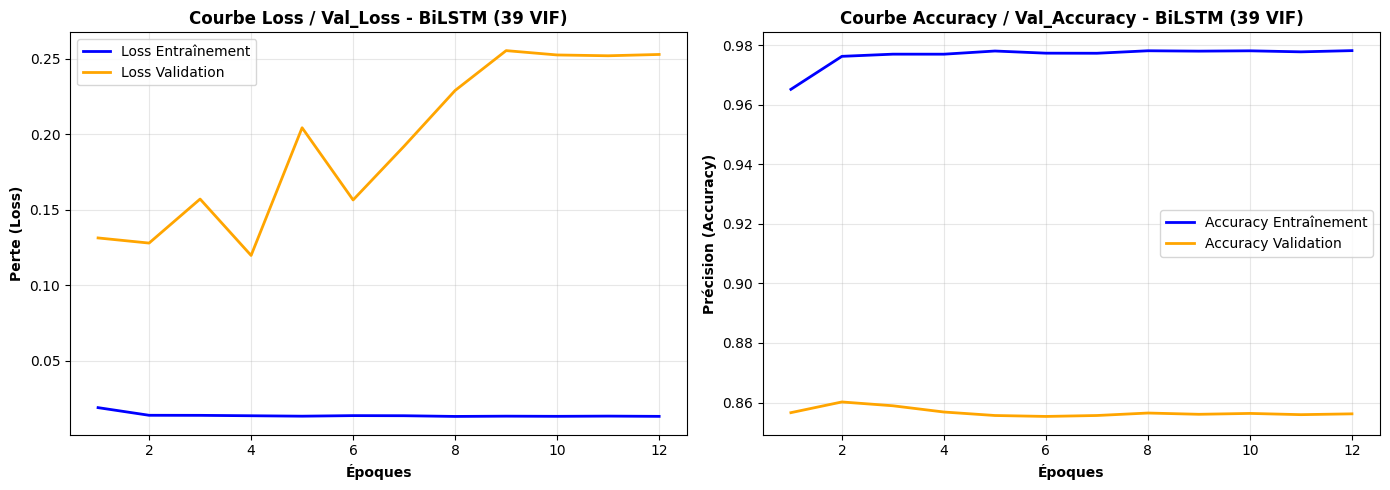

📊 Enregistrement du Tableau de Métriques (BiLSTM)...
📊 Enregistrement de la Matrice de Confusion (BiLSTM)...


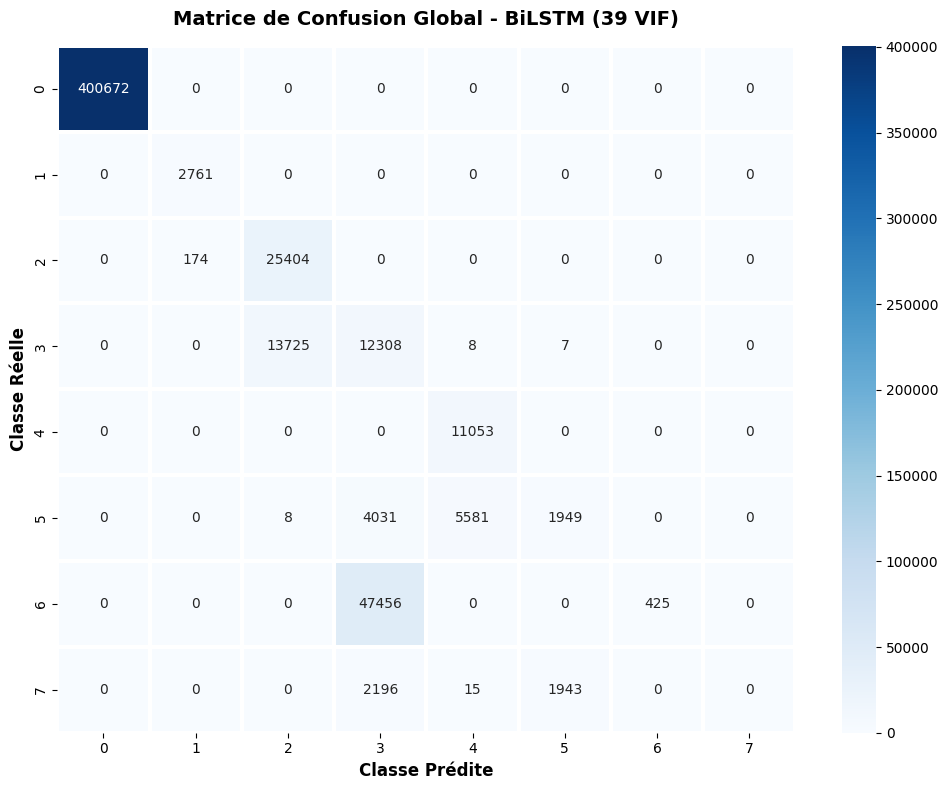

📊 Enregistrement de la Courbe Precision-Recall (BiLSTM)...


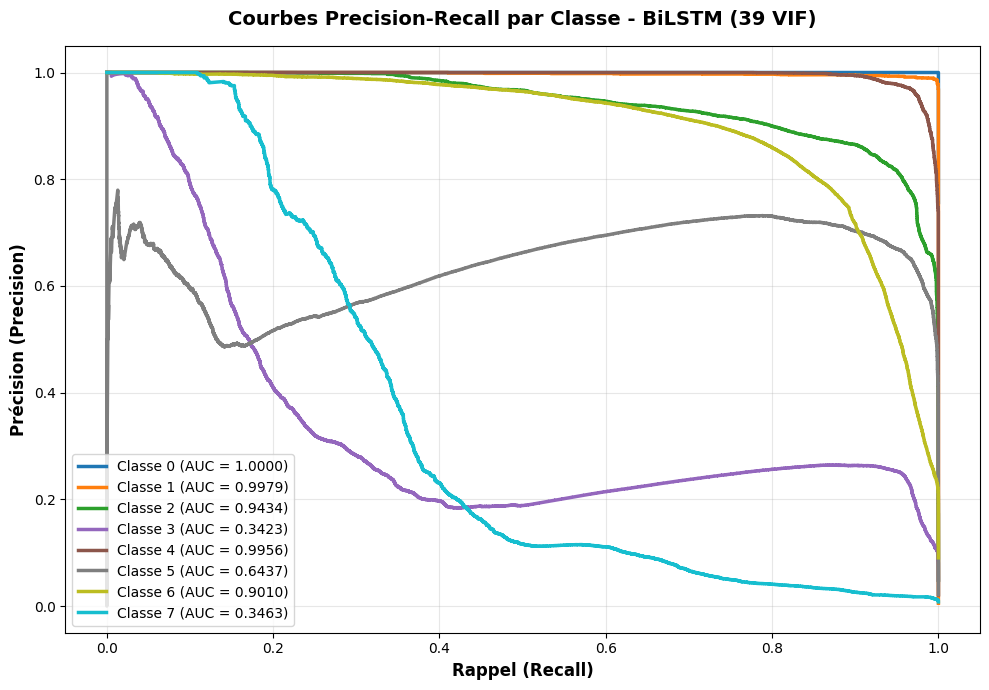


🎉 Modèle 5 (BiLSTM) entraîné et tous les résultats sauvegardés avec succès sur Google Drive !


In [16]:
# ============================================================
# MODÈLE 5 — BiLSTM : Entraînement K-Fold + Export Drive
# ============================================================

import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow.keras.backend as K

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    auc
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Reshape, Bidirectional, LSTM,
    BatchNormalization, Dropout, Dense
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 0. INITIALISATION DU K-FOLD STRATIFIÉ
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1. PRÉPARATION DES DOSSIERS ET CONFIGURATION
SAVE_DIR = "/content/drive/MyDrive/projet-remote/resulta_final"
os.makedirs(SAVE_DIR, exist_ok=True)

input_dim = X_train_39.shape[1]
num_classes = int(np.max(y_train)) + 1

print(f"\n=================== MODÈLE 5 : BiLSTM ({input_dim} variables, {num_classes} classes) ===================")

def focal_loss_multiclass(gamma=2.0, alpha=0.25):
    def focal_loss(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1.0 - y_pred, gamma)
        return K.sum(weight * cross_entropy, axis=-1)
    return focal_loss

def obtenir_callbacks_dl():
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        )
    ]

# 2. ARCHITECTURE BILSTM (Optimisée cuDNN / GPU)
def construire_bilstm_focal(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),
        Reshape((input_dim, 1)),
        # Suppression de recurrent_dropout pour activer la vitesse cuDNN
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.3)),
        BatchNormalization(),
        Bidirectional(LSTM(64, return_sequences=False, dropout=0.3)),
        BatchNormalization(),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
        loss=focal_loss_multiclass(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )
    return model

# 3. BOUCLE D'ENTRAÎNEMENT K-FOLD
y_true_all_bilstm = []
y_proba_all_bilstm = []
histories_bilstm = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_39, y_train), start=1):
    print(f"\n--- [BiLSTM (39 VIF)] En cours : Fold {fold}/5 ... ---")

    if isinstance(X_train_39, pd.DataFrame):
        X_tr, X_va = X_train_39.iloc[train_idx], X_train_39.iloc[val_idx]
    else:
        X_tr, X_va = X_train_39[train_idx], X_train_39[val_idx]

    if isinstance(y_train, (pd.Series, pd.DataFrame)):
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]
    else:
        y_tr, y_va = y_train[train_idx], y_train[val_idx]

    y_tr_cat = to_categorical(y_tr, num_classes=num_classes).astype("float32")
    y_va_cat = to_categorical(y_va, num_classes=num_classes).astype("float32")

    gc.collect()
    tf.keras.backend.clear_session()

    model_bilstm = construire_bilstm_focal(input_dim, num_classes)

    history = model_bilstm.fit(
        X_tr, y_tr_cat,
        validation_data=(X_va, y_va_cat),
        epochs=50,
        batch_size=512,
        callbacks=obtenir_callbacks_dl(),
        verbose=0
    )

    histories_bilstm.append(history.history)

    y_proba = model_bilstm.predict(X_va, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)

    y_true_all_bilstm.append(y_va.values if hasattr(y_va, 'values') else y_va)
    y_proba_all_bilstm.append(y_proba)

    macro_f1 = f1_score(y_va, y_pred, average='macro', zero_division=0)
    print(f"🎯 Fold {fold} terminé avec succès | Macro F1 : {macro_f1:.4f}")

    del model_bilstm
    gc.collect()

# 4. RECONSTRUCTION OOF & EXPORT AUTOMATIQUE
y_true_concat_bilstm = np.concatenate(y_true_all_bilstm)
y_proba_concat_bilstm = np.vstack(y_proba_all_bilstm)
y_pred_concat_bilstm = np.argmax(y_proba_concat_bilstm, axis=1)

# Livrable 1 : Courbes d'apprentissage
print("\n📊 Enregistrement des Courbes d'Apprentissage (BiLSTM)...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
last_hist = histories_bilstm[-1]
epochs = range(1, len(last_hist['loss']) + 1)

axes[0].plot(epochs, last_hist['loss'], label='Loss Entraînement', color='blue', linewidth=2)
axes[0].plot(epochs, last_hist['val_loss'], label='Loss Validation', color='orange', linewidth=2)
axes[0].set_title('Courbe Loss / Val_Loss - BiLSTM (39 VIF)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Époques', fontweight='bold')
axes[0].set_ylabel('Perte (Loss)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, last_hist['accuracy'], label='Accuracy Entraînement', color='blue', linewidth=2)
axes[1].plot(epochs, last_hist['val_accuracy'], label='Accuracy Validation', color='orange', linewidth=2)
axes[1].set_title('Courbe Accuracy / Val_Accuracy - BiLSTM (39 VIF)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Époques', fontweight='bold')
axes[1].set_ylabel('Précision (Accuracy)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "bilstm_39vif_learning_curves.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Livrable 2 : Tableau de métriques CSV
print("📊 Enregistrement du Tableau de Métriques (BiLSTM)...")
report_dict = classification_report(y_true_concat_bilstm, y_pred_concat_bilstm, output_dict=True, digits=4)
df_metrics_bilstm = pd.DataFrame(report_dict).transpose()
df_metrics_bilstm.to_csv(os.path.join(SAVE_DIR, "bilstm_39vif_metrics.csv"))

# Livrable 3 : Matrice de Confusion
print("📊 Enregistrement de la Matrice de Confusion (BiLSTM)...")
cm = confusion_matrix(y_true_concat_bilstm, y_pred_concat_bilstm)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, linewidths=1.5, linecolor='white')
plt.title('Matrice de Confusion Global - BiLSTM (39 VIF)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Classe Prédite', fontsize=12, fontweight='bold')
plt.ylabel('Classe Réelle', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "bilstm_39vif_confusion_matrix.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Livrable 4 : Courbe Precision-Recall
print("📊 Enregistrement de la Courbe Precision-Recall (BiLSTM)...")
plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, num_classes))

for class_idx in range(num_classes):
    y_true_binary = (y_true_concat_bilstm == class_idx).astype(int)
    y_score = y_proba_concat_bilstm[:, class_idx]

    if np.sum(y_true_binary) == 0:
        continue

    precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, color=colors[class_idx % len(colors)],
             linewidth=2.5, label=f'Classe {class_idx} (AUC = {pr_auc:.4f})')

plt.xlabel('Rappel (Recall)', fontsize=12, fontweight='bold')
plt.ylabel('Précision (Precision)', fontsize=12, fontweight='bold')
plt.title('Courbes Precision-Recall par Classe - BiLSTM (39 VIF)', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "bilstm_39vif_precision_recall_curve.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\n🎉 Modèle 5 (BiLSTM) entraîné et tous les résultats sauvegardés avec succès sur Google Drive !")